# Clinical Correlation Analysis - EDA

In [13]:
import os
import sys
from pathlib import Path

# Add src to path
project_root = Path(os.path.abspath('')).parent.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress

%matplotlib inline

## Configuration

In [14]:
# Configuration
RESULTS_DIR = Path("/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/RESULTS/QVTPlus/")
CLINICAL_SUMMARY = Path("/data_local/LabVF/PESA-Brain/Auxiliary/PESABrain_DB_Batch1.xlsx")
# OUTPUT_DIR = RESULTS_DIR / "Summary" / "clinical_correlations_pearson"
OUTPUT_DIR = Path('/data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/')
DATABASE_PATH = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/PESABrain_AnalysisDB_Batch1.csv')  # Consolidated database file
# SIGMA_THRESHOLD = 6.0
SIGMA_THRESHOLD = None

print(f"Results directory: {RESULTS_DIR}")
print(f"Clinical summary: {CLINICAL_SUMMARY}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Database path: {DATABASE_PATH}")

Results directory: /home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/RESULTS/QVTPlus
Clinical summary: /data_local/LabVF/PESA-Brain/Auxiliary/PESABrain_DB_Batch1.xlsx
Output directory: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical
Database path: /home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/PESABrain_AnalysisDB_Batch1.csv


In [15]:
# Import analysis functions
from neuroimaging.pesa_brain.cli.analysis_plotting import (
    load_all_patients,
    load_clinical_summary
)
from neuroimaging.pesa_brain.analysis.correlater import (
    build_analysis_database,
    load_analysis_database,
    save_correlation_heatmaps,
    save_standard_scatter_plots,
    save_hued_scatter_plots,
    save_vessel_spatial_correlation_outputs,
    save_polar_clinical_correlations,
    save_flow_pi_cross_correlation,
    _save_mixed_effects_by_vessel_plots,
    _coerce_clinical_numeric,
    _select_numeric_clinical_columns
)

print("Functions imported successfully")

Functions imported successfully


# Step 1: Build and save consolidated database


In [4]:
# Skip this cell if database already exists

patients2exclude = ['PESA15808576']

remake = False
if not DATABASE_PATH.exists() or remake:
    print("Building analysis database (this may take a while)...")
    print("Loading patient data...")
    patient_data, _ = load_all_patients(RESULTS_DIR)
    print(f"Found {len(patient_data)} patients")
    
    print("Loading clinical summary...")
    clinical_df = load_clinical_summary(CLINICAL_SUMMARY)
    print(f"Clinical data shape: {clinical_df.shape}")
    
    print("Building consolidated database...")
    database_df = build_analysis_database(
        patient_metadata=patient_data,
        clinical_df=clinical_df,
        output_path=DATABASE_PATH,
        patients2exclude=patients2exclude
    )
    print("✓ Database created successfully!")
else:
    print(f"✓ Database already exists at: {DATABASE_PATH}")
    print("Skipping database creation. To rebuild, delete the file and rerun this cell.")

✓ Database already exists at: /home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/PESABrain_AnalysisDB_Batch1.csv
Skipping database creation. To rebuild, delete the file and rerun this cell.


In [5]:
database_df

,patient_id,mri_id,med_recon_id,seq_num,visit,sex,age_at_mri,weight,height,bpxsym,...,Left PCA_PI,Right PCA_PI,Left ACA_PI,Right ACA_PI,Straight Sinus_PI,Right Transverse_PI,Sagital Sinus_PI,Left Transverse_PI,Left Communicating_PI,Right Communicating_PI
0,PESA1006009,BMRI923674,RE964546,1002.0,4.0,1.0,62.87,78.0,167.0,124.0,...,0.830223,0.726965,0.633569,0.811477,0.426850,1.393974,0.490176,0.439316,NaN,NaN
1,PESA10061584,BMRI287356,RE561042,3171.0,4.0,1.0,64.27,94.0,176.0,138.0,...,1.181798,0.834230,0.561590,1.113951,0.495994,NaN,0.559973,0.754594,NaN,0.655992
2,PESA10067929,BMRI965424,RE190986,3172.0,4.0,1.0,64.54,82.9,163.0,148.0,...,0.964834,0.875718,0.716919,0.732283,0.282347,0.459700,0.464831,NaN,0.596312,NaN
3,PESA10086976,BMRI859483,RE929770,3175.0,4.0,0.0,53.19,71.0,162.0,111.0,...,0.781172,0.583615,0.459284,0.757007,NaN,1.180239,0.204669,NaN,NaN,NaN
4,PESA10112400,BMRI465140,RE726629,3179.0,4.0,1.0,53.74,81.5,175.0,147.0,...,0.689922,0.677822,0.655302,0.572235,0.365851,0.361016,0.378775,0.400198,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,PESA9897316,BMRI994162,RE248777,3145.0,4.0,1.0,55.35,85.0,185.0,107.0,...,0.685955,0.703408,0.813115,0.684214,0.341684,0.355783,0.227636,0.188713,NaN,NaN
395,PESA9928801,BMRI487416,RE926771,3150.0,4.0,0.0,62.13,80.0,172.0,104.0,...,0.705471,0.923205,0.697635,0.759326,NaN,NaN,NaN,1.066115,NaN,0.704546
396,PESA9935104,BMRI881199,RE836025,3151.0,4.0,0.0,60.59,57.5,170.0,122.0,...,0.693083,0.715577,0.685488,0.733048,0.299098,0.330387,0.434908,0.512343,NaN,NaN
397,PESA9947716,BMRI447102,RE405990,3153.0,4.0,1.0,59.13,86.0,170.0,114.0,...,0.770617,0.835087,0.644240,0.784936,0.503226,0.427223,0.406084,0.293725,NaN,NaN


In [6]:
if remake:
    patients2filter = []

    # Check if we have flows for the main vessels
    # Check if we have Clinical data for these patients
    _VESSELS2CHECK = ['Left ICA', 'Right ICA', 'Basilar', 'Left MCA']
    _CLINICAL2CHECK = ['age_at_mri', 'sex']

    for patient_idx in database_df.patient_id:
        patient_data = database_df[database_df.patient_id == patient_idx]
        
        if not any(patient_data[_VESSELS2CHECK].notna().any()):
            patients2filter.append(patient_idx)

        if not all(patient_data[_CLINICAL2CHECK].notna().all()):
            patients2filter.append(patient_idx)

    print(f'Found {len(patients2filter)} patients to exclude')
    database_df = database_df[~database_df.patient_id.isin(patients2filter)]
    database_df.to_csv(DATABASE_PATH, index=False)

Found 41 patients to exclude


In [7]:
database_df

,patient_id,mri_id,med_recon_id,seq_num,visit,sex,age_at_mri,weight,height,bpxsym,...,Left PCA_PI,Right PCA_PI,Left ACA_PI,Right ACA_PI,Straight Sinus_PI,Right Transverse_PI,Sagital Sinus_PI,Left Transverse_PI,Left Communicating_PI,Right Communicating_PI
0,PESA1006009,BMRI923674,RE964546,1002.0,4.0,1.0,62.87,78.0,167.0,124.0,...,0.830223,0.726965,0.633569,0.811477,0.426850,1.393974,0.490176,0.439316,NaN,NaN
1,PESA10061584,BMRI287356,RE561042,3171.0,4.0,1.0,64.27,94.0,176.0,138.0,...,1.181798,0.834230,0.561590,1.113951,0.495994,NaN,0.559973,0.754594,NaN,0.655992
2,PESA10067929,BMRI965424,RE190986,3172.0,4.0,1.0,64.54,82.9,163.0,148.0,...,0.964834,0.875718,0.716919,0.732283,0.282347,0.459700,0.464831,NaN,0.596312,NaN
3,PESA10086976,BMRI859483,RE929770,3175.0,4.0,0.0,53.19,71.0,162.0,111.0,...,0.781172,0.583615,0.459284,0.757007,NaN,1.180239,0.204669,NaN,NaN,NaN
4,PESA10112400,BMRI465140,RE726629,3179.0,4.0,1.0,53.74,81.5,175.0,147.0,...,0.689922,0.677822,0.655302,0.572235,0.365851,0.361016,0.378775,0.400198,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,PESA9897316,BMRI994162,RE248777,3145.0,4.0,1.0,55.35,85.0,185.0,107.0,...,0.685955,0.703408,0.813115,0.684214,0.341684,0.355783,0.227636,0.188713,NaN,NaN
395,PESA9928801,BMRI487416,RE926771,3150.0,4.0,0.0,62.13,80.0,172.0,104.0,...,0.705471,0.923205,0.697635,0.759326,NaN,NaN,NaN,1.066115,NaN,0.704546
396,PESA9935104,BMRI881199,RE836025,3151.0,4.0,0.0,60.59,57.5,170.0,122.0,...,0.693083,0.715577,0.685488,0.733048,0.299098,0.330387,0.434908,0.512343,NaN,NaN
397,PESA9947716,BMRI447102,RE405990,3153.0,4.0,1.0,59.13,86.0,170.0,114.0,...,0.770617,0.835087,0.644240,0.784936,0.503226,0.427223,0.406084,0.293725,NaN,NaN


## Step 2: Load Analysis Database

Load the consolidated database and split into clinical, flow, and PI tables.

In [16]:
# Load the database
clinical_df, flow_table, pi_table = load_analysis_database(DATABASE_PATH)

# Remove TCBF for PI if present
if "TCBF" in pi_table.columns:
    pi_table = pi_table.drop(columns=["TCBF"])

print(f"\nLoaded data:")
print(f"  Clinical: {clinical_df.shape}")
print(f"  Flow: {flow_table.shape}")
print(f"  PI: {pi_table.shape}")

# Display first few rows
print(f"\nClinical columns: {list(clinical_df.columns[:10])}...")
print(f"\nFlow vessels: {list(flow_table.columns[:5])}...")
print(f"\nPI vessels: {list(pi_table.columns[:5])}...")

Loaded database: 357 patients
Clinical variables: 17
Flow vessels: 16
PI vessels: 15

Loaded data:
  Clinical: (357, 18)
  Flow: (357, 17)
  PI: (357, 16)

Clinical columns: ['patient_id', 'sex', 'age_at_mri', 'weight', 'height', 'bpxsym', 'bpxdim', 'bpxpls', 'hematocrit', 'tas']...

Flow vessels: ['patient_id', 'Left ICA', 'Right ICA', 'Basilar', 'Left MCA']...

PI vessels: ['patient_id', 'Left ICA', 'Right ICA', 'Basilar', 'Left MCA']...


## FILTER BY HAND

In [27]:
# # Exclude individual vessel measurements out of 6 z-score units within vessel variation
# for vessel in flow_table.columns:
#     if vessel not in ['patient_id']:
#         vessel_data = flow_table[vessel].dropna()
#         z_scores = np.abs(vessel_data - vessel_data.mean()) / vessel_data.std()
#         outliers = z_scores > 10
#         print(f"{vessel}: {len(outliers)} outliers")
#         # outliers_idx = vessel_data[z_scores > 6].index
#         # flow_table.loc[outliers_idx, vessel] = np.nan
#         # pi_table.loc[outliers_idx, vessel] = np.nan




Left ICA: 259 outliers
Right ICA: 259 outliers
Basilar: 259 outliers
Left MCA: 261 outliers
Right MCA: 259 outliers
Left PCA: 262 outliers
Right PCA: 262 outliers
Left ACA: 258 outliers
Right ACA: 250 outliers
Straight Sinus: 204 outliers
Right Transverse: 216 outliers
TCBF: 259 outliers
Sagital Sinus: 235 outliers
Left Transverse: 200 outliers
Left Communicating: 65 outliers
Right Communicating: 88 outliers


In [19]:

# patients2exclude = [
#     "PESA9511056",
#     "PESA929296",
#     "PESA9229444",
#     "PESA896809",
#     "PESA8797156",
#     "PESA853776",
#     "PESA8514724",
#     "PESA846400",
#     "PESA8145316",
#     "PESA7997584",
#     "PESA7778521",
#     "PESA7728400",
#     "PESA7628644",
#     "PESA7409284",
#     "PESA7344100",
#     "PESA7300804",
#     "PESA7139584",
#     "PESA7112889",
#     "PESA7059649",
#     "PESA7001316",
#     "PESA6943225",
#     "PESA6916900",
#     "PESA6869641",
#     "PESA6744409",
#     "PESA6708100",
#     "PESA6651241",
#     "PESA6568969",
#     "PESA6553600",
#     "PESA6538249",
#     "PESA6416089",
#     "PESA6160324",
#     "PESA5934096",
#     "PESA5760000",
#     "PESA5456896",
#     "PESA5290000",
#     "PESA5193841",
#     "PESA5013121",
#     "PESA4613904",
#     "PESA447561",
#     "PESA4247721",
#     "PESA3640464",
#     "PESA3330625",
#     "PESA3286969",
#     "PESA3268864",
#     "PESA3034564",
#     "PESA3003289",
#     "PESA242064",
#     "PESA2304324",
#     "PESA219024",
#     "PESA2099601",
#     "PESA2076481",
#     "PESA20164",
#     "PESA1985281",
#     "PESA1819801",
#     "PESA17867529",
#     "PESA17405584",
#     "PESA17363889",
#     "PESA17280649",
#     "PESA16999129",
#     "PESA16769025",
#     "PESA16394401",
#     "PESA163216",
#     "PESA16248961",
#     "PESA16240900",
#     "PESA16064064",
#     "PESA16016004",
#     "PESA16008001",
#     "PESA1577536",
#     "PESA14945956",
#     "PESA14814801",
#     "PESA14753281",
#     "PESA14577124",
#     "PESA14546596",
#     "PESA1440000",
#     "PESA13816089",
#     "PESA1359556",
#     "PESA1274641",
#     "PESA12439729",
#     "PESA12145225",
#     "PESA120409",
#     "PESA11923209",
#     "PESA11600836",
#     "PESA11573604",
#     "PESA11175649",
#     "PESA11048976",
#     "PESA10989225",
#     "PESA10936249",
#     "PESA10523536",
#     "PESA10465225",
#     "PESA10407076",
#     "PESA10240000",
#     "PESA10233601",
#     "PESA10086976",
#     "PESA1006009",
# ]


# _EXCLUDE = False

# if _EXCLUDE:
#     print(f"Excluding {len(patients2exclude)} patients")
#     clinical_df = clinical_df[~clinical_df.patient_id.isin(patients2exclude)]
#     flow_table = flow_table[~flow_table.patient_id.isin(patients2exclude)]
#     pi_table = pi_table[~pi_table.patient_id.isin(patients2exclude)]
#     print(f"Remaining patients: {len(clinical_df)}")


Excluding 94 patients
Remaining patients: 262


In [26]:
clinical_df

,patient_id,sex,age_at_mri,weight,height,bpxsym,bpxdim,bpxpls,hematocrit,tas,tad,bmi,sys_dias_delta,ctx_whole_brain,ctx_left_hemisphere,ctx_right_hemisphere,plaque_left_carotid,plaque_right_carotid
0,PESA1006009,1.0,62.87,78.0,167.0,124.0,75.0,62.0,47.0,122.0,73.0,27.968016,49.0,64.850706,63.393821,66.288385,0.000000,0.000000
1,PESA10061584,1.0,64.27,94.0,176.0,138.0,85.0,88.0,48.0,135.0,80.0,30.346074,53.0,43.683496,44.220321,43.141605,0.000000,0.000000
2,PESA10067929,1.0,64.54,82.9,163.0,148.0,86.0,76.0,42.0,153.0,91.0,31.201777,62.0,71.819444,69.764533,73.896158,10.015992,0.000000
3,PESA10086976,0.0,53.19,71.0,162.0,111.0,79.0,81.0,45.0,124.0,81.0,27.053803,32.0,65.740547,63.598031,67.886590,0.000000,0.000000
4,PESA10112400,1.0,53.74,81.5,175.0,147.0,89.0,80.0,48.0,140.0,90.0,26.612245,58.0,57.550002,56.656838,58.416831,0.000000,12.492144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,PESA9897316,1.0,55.35,85.0,185.0,107.0,68.0,82.0,52.0,130.0,82.0,24.835646,39.0,61.322542,61.321816,61.323249,32.961096,0.000000
353,PESA9928801,0.0,62.13,80.0,172.0,104.0,73.0,75.0,45.0,122.0,75.0,27.041644,31.0,64.188529,62.430920,65.940574,0.000000,0.000000
354,PESA9935104,0.0,60.59,57.5,170.0,122.0,76.0,60.0,45.0,136.0,82.0,19.896194,46.0,56.903359,57.807313,55.979328,0.000000,0.000000
355,PESA9947716,1.0,59.13,86.0,170.0,114.0,71.0,68.0,42.0,140.0,80.0,29.757785,43.0,72.428656,69.965742,74.834474,0.000000,0.000000


In [27]:
flow_table

,patient_id,Left ICA,Right ICA,Basilar,Left MCA,Right MCA,Left PCA,Right PCA,Left ACA,Right ACA,Straight Sinus,Right Transverse,TCBF,Sagital Sinus,Left Transverse,Left Communicating,Right Communicating
0,PESA1006009,267.035802,281.351906,184.510389,184.078000,164.954801,85.506044,87.287925,123.890140,169.345030,91.780072,19.454464,732.898097,324.326244,520.735027,NaN,NaN
1,PESA10061584,94.844843,207.560577,182.850943,98.020385,125.765787,28.154514,65.765648,57.051822,59.883987,61.624851,NaN,485.256363,312.151543,82.878716,NaN,78.691079
2,PESA10067929,323.586469,355.117301,228.640571,270.285622,239.059132,122.964848,114.071772,114.857424,111.551782,102.287930,580.894268,907.344340,422.249027,NaN,119.439828,NaN
3,PESA10086976,303.364359,0.814246,251.966084,233.156754,239.970671,73.641519,137.637481,87.405910,39.218030,NaN,19.022995,556.144689,180.244190,NaN,NaN,NaN
4,PESA10112400,325.856177,330.478438,151.450536,204.398455,193.725946,58.706137,66.667051,87.470201,178.279675,83.714123,565.937433,807.785152,357.676310,96.298434,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,PESA9897316,283.497145,262.646432,178.221377,157.694022,174.874614,81.645816,80.873901,80.672484,154.428945,58.207388,144.922742,724.364954,403.755209,345.180321,NaN,NaN
353,PESA9928801,314.992869,370.991649,87.832792,145.102919,145.299666,62.834793,96.432440,94.685434,108.661552,NaN,NaN,773.817309,NaN,30.023411,NaN,82.117245
354,PESA9935104,352.592480,199.660541,245.827435,171.888570,187.729023,95.659605,87.211407,171.542602,121.473962,307.457462,332.273682,798.080455,44.223617,57.329407,NaN,NaN
355,PESA9947716,350.185589,358.434131,309.712580,227.214842,251.342628,86.541550,122.017814,88.710539,99.947704,129.490267,520.660198,1018.332299,401.265249,159.015987,NaN,NaN


In [28]:
pi_table

,patient_id,Left ICA,Right ICA,Basilar,Left MCA,Right MCA,Left PCA,Right PCA,Left ACA,Right ACA,Straight Sinus,Right Transverse,Sagital Sinus,Left Transverse,Left Communicating,Right Communicating
0,PESA1006009,0.701133,0.727263,0.791092,0.716086,0.821272,0.830223,0.726965,0.633569,0.811477,0.426850,1.393974,0.490176,0.439316,NaN,NaN
1,PESA10061584,0.639911,0.698219,0.819871,0.918364,0.922679,1.181798,0.834230,0.561590,1.113951,0.495994,NaN,0.559973,0.754594,NaN,0.655992
2,PESA10067929,0.773645,0.796976,0.810012,0.716315,0.504411,0.964834,0.875718,0.716919,0.732283,0.282347,0.459700,0.464831,NaN,0.596312,NaN
3,PESA10086976,0.540127,0.847596,0.657827,0.713979,0.655864,0.781172,0.583615,0.459284,0.757007,NaN,1.180239,0.204669,NaN,NaN,NaN
4,PESA10112400,0.707761,0.791426,0.657464,0.698609,0.692242,0.689922,0.677822,0.655302,0.572235,0.365851,0.361016,0.378775,0.400198,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,PESA9897316,0.709040,0.782386,0.674136,0.816209,0.821824,0.685955,0.703408,0.813115,0.684214,0.341684,0.355783,0.227636,0.188713,NaN,NaN
353,PESA9928801,0.850857,0.870882,0.567656,0.820841,0.487943,0.705471,0.923205,0.697635,0.759326,NaN,NaN,NaN,1.066115,NaN,0.704546
354,PESA9935104,0.753206,0.735158,0.719752,0.720566,0.689648,0.693083,0.715577,0.685488,0.733048,0.299098,0.330387,0.434908,0.512343,NaN,NaN
355,PESA9947716,0.807655,0.811330,0.857074,0.575352,0.733437,0.770617,0.835087,0.644240,0.784936,0.503226,0.427223,0.406084,0.293725,NaN,NaN


## Step 3: Correlation Heatmaps - Flow

Generate all 4 correlation heatmaps for Flow:
1. Clinical vars vs vessels
2. Clinical vars and vessels vs vessels (full matrix)
3. Clinical vars vs clinical vars
4. Vessels vs vessels

In [7]:
# Generate correlation heatmaps for Flow
feature_label = "Flow (mL/min)"
feature_dir = OUTPUT_DIR / "flow"
feature_dir.mkdir(parents=True, exist_ok=True)

print(f"Generating correlation heatmaps for: {feature_label}")

flow_result = save_correlation_heatmaps(
    clinical_df=clinical_df,
    feature_table=flow_table,
    feature_label=feature_label,
    output_dir=feature_dir,
    clinical_columns=None,
)

print(f"✓ Heatmaps saved to: {feature_dir / 'corr_heatmaps'}")
print(f"✓ Vessel correlations saved to: {feature_dir / 'vessel_correlations'}")
print(f"Total correlations computed: {len(flow_result.correlations)}")

Generating correlation heatmaps for: Flow (mL/min)
✓ Heatmaps saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/corr_heatmaps
✓ Vessel correlations saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/vessel_correlations
Total correlations computed: 528


Example heatmap: clinical_and_vessels_vs_vessels_flow_ml_min.png


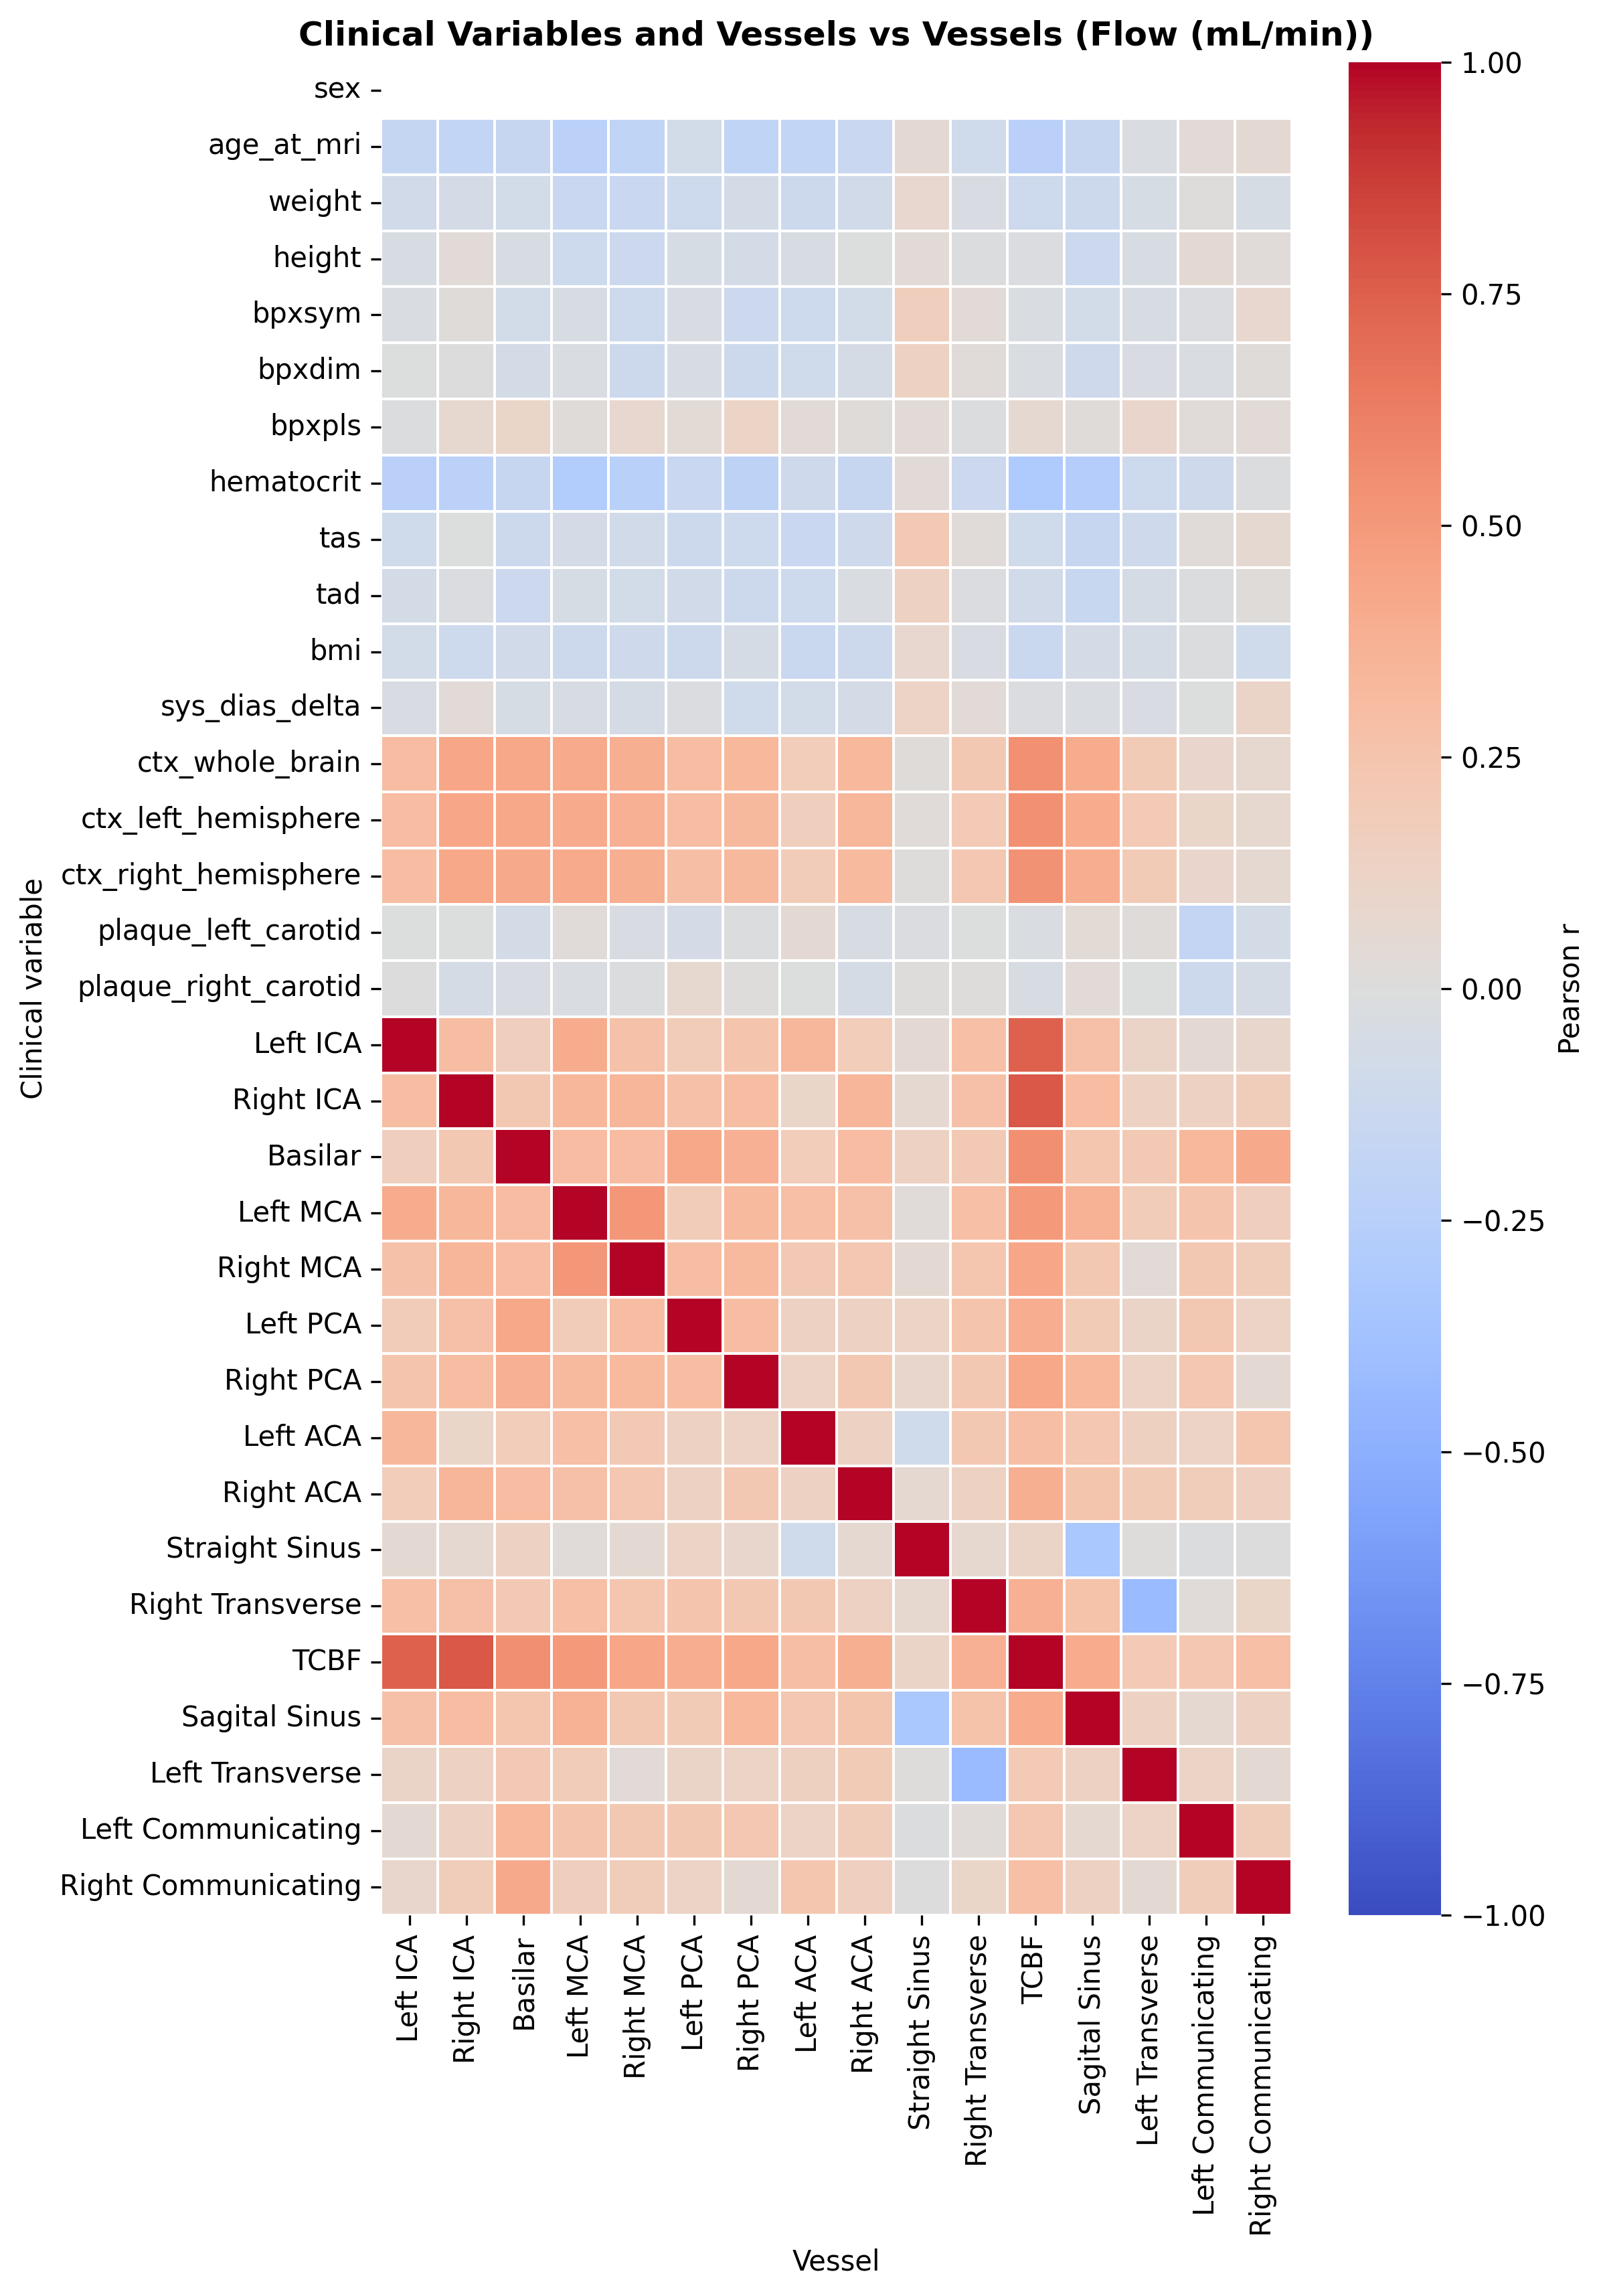

In [8]:
# Display example heatmap
from IPython.display import Image, display

_feature_label = 'flow_ml_min'
heatmap_path = feature_dir / "corr_heatmaps" / f"clinical_and_vessels_vs_vessels_{_feature_label.lower().replace(' ', '_')}.png"
if heatmap_path.exists():
    print(f"Example heatmap: {heatmap_path.name}")
    display(Image(str(heatmap_path)))
else:
    print("Heatmap not found. Run the previous cell first.")

## Step 4: Correlation Heatmaps - PI

Generate all 4 correlation heatmaps for PI (same as Step 3, but for PI).

In [9]:
# Generate correlation heatmaps for PI
feature_label = "PI"
feature_dir = OUTPUT_DIR / "pi"
feature_dir.mkdir(parents=True, exist_ok=True)

print(f"Generating correlation heatmaps for: {feature_label}")

pi_result = save_correlation_heatmaps(
    clinical_df=clinical_df,
    feature_table=pi_table,
    feature_label=feature_label,
    output_dir=feature_dir,
    clinical_columns=None,
)

print(f"✓ Heatmaps saved to: {feature_dir / 'corr_heatmaps'}")
print(f"✓ Vessel correlations saved to: {feature_dir / 'vessel_correlations'}")
print(f"Total correlations computed: {len(pi_result.correlations)}")

Generating correlation heatmaps for: PI
✓ Heatmaps saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/pi/corr_heatmaps
✓ Vessel correlations saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/pi/vessel_correlations
Total correlations computed: 480


Example heatmap: clinical_and_vessels_vs_vessels_pi.png


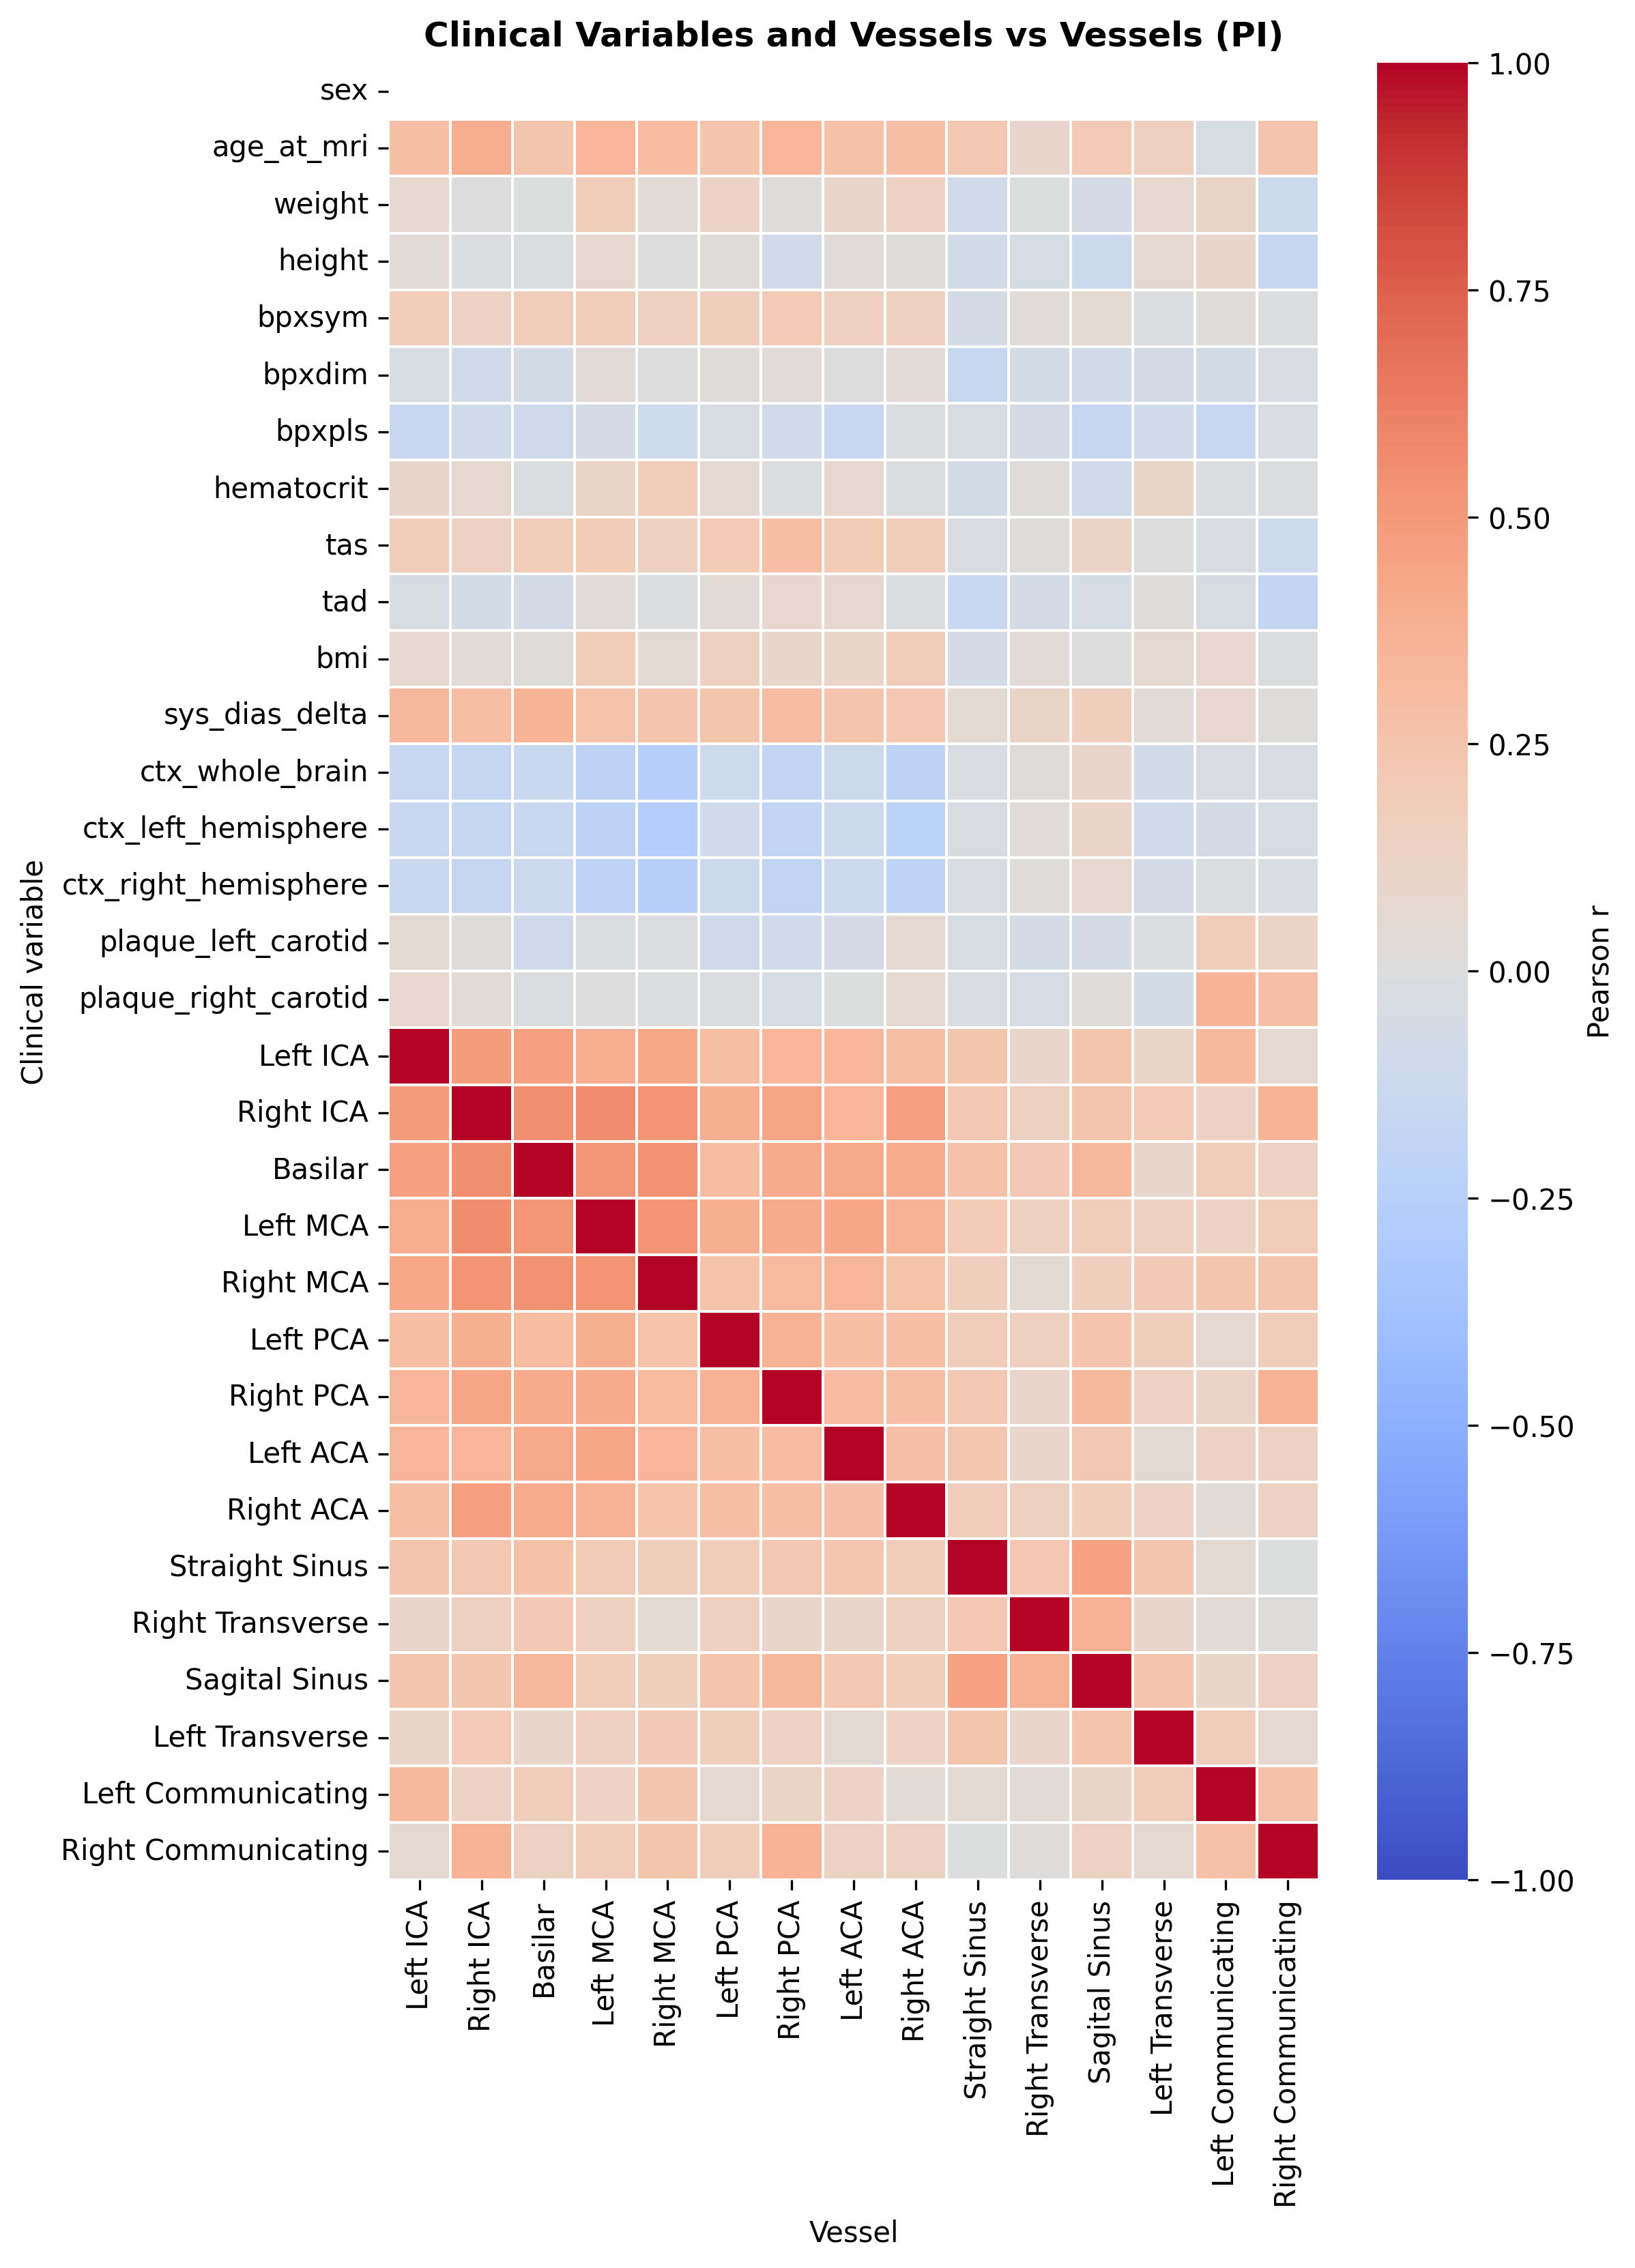

In [10]:
# Display example heatmap
heatmap_path = feature_dir / "corr_heatmaps" / f"clinical_and_vessels_vs_vessels_{feature_label.lower()}.png"
if heatmap_path.exists():
    print(f"Example heatmap: {heatmap_path.name}")
    display(Image(str(heatmap_path)))
else:
    print("Heatmap not found. Run the previous cell first.")

## Step 5: Standard Scatter Plots & Spatial Corrs - Flow

Generate standard scatter plots (one per clinical variable-vessel pair) for Flow.

In [11]:
# Generate standard scatter plots for Flow
feature_label = "Flow (mL/min)"
feature_dir = OUTPUT_DIR / "flow"

print(f"Generating standard scatter plots for: {feature_label}")

save_standard_scatter_plots(
    clinical_df=clinical_df,
    feature_table=flow_table,
    feature_label=feature_label,
    output_dir=feature_dir,
    correlation_result=flow_result,
    sigma_threshold=SIGMA_THRESHOLD,
)

print(f"✓ Scatter plots saved to: {feature_dir / 'scatter'}")

Generating standard scatter plots for: Flow (mL/min)
✓ Scatter plots saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/scatter


In [12]:
# Flow polar plots
try:
    print("Generating polar clinical correlations for Flow...")
    save_polar_clinical_correlations(
        clinical_df=clinical_df,
        feature_table=flow_table,
        feature_label="Flow (mL/min)",
        output_dir=OUTPUT_DIR / "flow" / "polar_clinical",
        clinical_columns=None,
    )
    print("Flow polar plots saved")
except Exception as e:
    print(f"Warning: Could not generate polar plots for Flow: {e}")

Generating polar clinical correlations for Flow...


Flow polar plots saved


## Step 6: Standard Scatter Plots & Spatial Corrs - PI

In [13]:
# Generate standard scatter plots for PI
feature_label = "PI"
feature_dir = OUTPUT_DIR / "pi"

print(f"Generating standard scatter plots for: {feature_label}")

save_standard_scatter_plots(
    clinical_df=clinical_df,
    feature_table=pi_table,
    feature_label=feature_label,
    output_dir=feature_dir,
    correlation_result=pi_result,
    sigma_threshold=SIGMA_THRESHOLD,
)

print(f"✓ Scatter plots saved to: {feature_dir / 'scatter'}")

Generating standard scatter plots for: PI
✓ Scatter plots saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/pi/scatter


In [14]:
# PI polar plots
try:
    print("Generating polar clinical correlations for PI...")
    save_polar_clinical_correlations(
        clinical_df=clinical_df,
        feature_table=pi_table,
        feature_label="PI",
        output_dir=OUTPUT_DIR / "pi" / "polar_clinical",
        clinical_columns=None,
    )
    print("PI polar plots saved")
except Exception as e:
    print(f"Warning: Could not generate polar plots for PI: {e}")

Generating polar clinical correlations for PI...
PI polar plots saved


## 7. Flow vs PI cross-correlation

In [15]:
# Flow vs PI correlations
print("Computing Flow vs PI cross-correlations...")
save_flow_pi_cross_correlation(
    flow_table=flow_table,
    pi_table=pi_table,
    output_dir=OUTPUT_DIR / "flow_pi_cross",
)
print("Flow vs PI correlations saved")

Computing Flow vs PI cross-correlations...
Flow vs PI correlations saved


## Step 8: Hued Scatter Plots - Flow

Generate hued scatter plots stratified by:
- Sex
- ICA plaque groups (if available)
- Vessel groups (combined plot per clinical variable)

In [16]:
# Generate hued scatter plots for Flow
feature_label = "Flow (mL/min)"
feature_dir = OUTPUT_DIR / "flow"

print(f"Generating hued scatter plots for: {feature_label}")

save_hued_scatter_plots(
    clinical_df=clinical_df,
    feature_table=flow_table,
    feature_label=feature_label,
    output_dir=feature_dir,
    correlation_result=flow_result,
    sigma_threshold=SIGMA_THRESHOLD,
)

print(f"✓ Hued scatter plots saved to: {feature_dir / 'scatter_hue'}")

Generating hued scatter plots for: Flow (mL/min)


✓ Hued scatter plots saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/scatter_hue


## Step 9: Hued Scatter Plots - PI


In [17]:
# Generate hued scatter plots for PI
feature_label = "PI"
feature_dir = OUTPUT_DIR / "pi"

print(f"Generating hued scatter plots for: {feature_label}")

save_hued_scatter_plots(
    clinical_df=clinical_df,
    feature_table=pi_table,
    feature_label=feature_label,
    output_dir=feature_dir,
    correlation_result=pi_result,
    sigma_threshold=SIGMA_THRESHOLD,
)

print(f"✓ Hued scatter plots saved to: {feature_dir / 'scatter_hue'}")

Generating hued scatter plots for: PI
✓ Hued scatter plots saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/pi/scatter_hue


## Step 10: Random Effects Plots - Flow and PI

Generate mixed-effects plots showing random effects (intercepts and slopes) by vessel.
One plot per clinical variable, with stratification by sex and carotid plaque groups.

In [18]:
# Generate random effects plots for Flow
feature_label = "Flow (mL/min)"
feature_dir = OUTPUT_DIR / "flow"

print(f"Generating random effects plots for: {feature_label}")

_save_mixed_effects_by_vessel_plots(
    clinical_df=clinical_df,
    feature_table=flow_table,
    feature_label=feature_label,
    output_dir=feature_dir,
    clinical_columns=None,
    sigma_threshold=SIGMA_THRESHOLD,
)

print(f"✓ Random effects plots saved to: {feature_dir / 'random_effects'}")

Generating random effects plots for: Flow (mL/min)
✓ Random effects plots saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/random_effects


In [19]:
# Generate random effects plots for PI
feature_label = "PI"
feature_dir = OUTPUT_DIR / "pi"

print(f"\nGenerating random effects plots for: {feature_label}")

_save_mixed_effects_by_vessel_plots(
    clinical_df=clinical_df,
    feature_table=pi_table,
    feature_label=feature_label,
    output_dir=feature_dir,
    clinical_columns=None,
    sigma_threshold=SIGMA_THRESHOLD,
)

print(f"✓ Random effects plots saved to: {feature_dir / 'random_effects'}")


Generating random effects plots for: PI
✓ Random effects plots saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/pi/random_effects


## Step 11: Carotid Plaque Analysis

Additional analysis and visualization for carotid plaque data.

In [20]:
# Detect plaque variables
# NOTE: No automatic outlier removal is performed (SIGMA_THRESHOLD=None by default).
from neuroimaging.pesa_brain.analysis.correlater import (
    _detect_carotid_plaque_variables,
    _add_carotid_plaque_stratification,
)

clinical_numeric = _coerce_clinical_numeric(clinical_df.copy()).set_index("patient_id")
merged_plaque = clinical_numeric.join(flow_table.set_index("patient_id"), how="inner")

plaque_vars = _detect_carotid_plaque_variables(merged_plaque)
print(f"Detected plaque variables: {plaque_vars}")

if plaque_vars:
    merged_plaque = _add_carotid_plaque_stratification(merged_plaque, plaque_vars)
    print(f"\nPlaque groups created: {merged_plaque['carotid_plaque_group'].value_counts()}")

Detected plaque variables: ['plaque_left_carotid', 'plaque_right_carotid']

Plaque groups created: carotid_plaque_group
No Plaques            231
Right Carotid Only     46
Bilateral Plaques      42
Left Carotid Only      40
Name: count, dtype: int64


/tmp/ipykernel_2153298/2636580160.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_flows, labels=group_labels, patch_artist=True)
/tmp/ipykernel_2153298/2636580160.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_flows, labels=group_labels, patch_artist=True)
/tmp/ipykernel_2153298/2636580160.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_flows, labels=group_labels, patch_artist=True)
/tmp/ipykernel_2153298/2636580160.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.

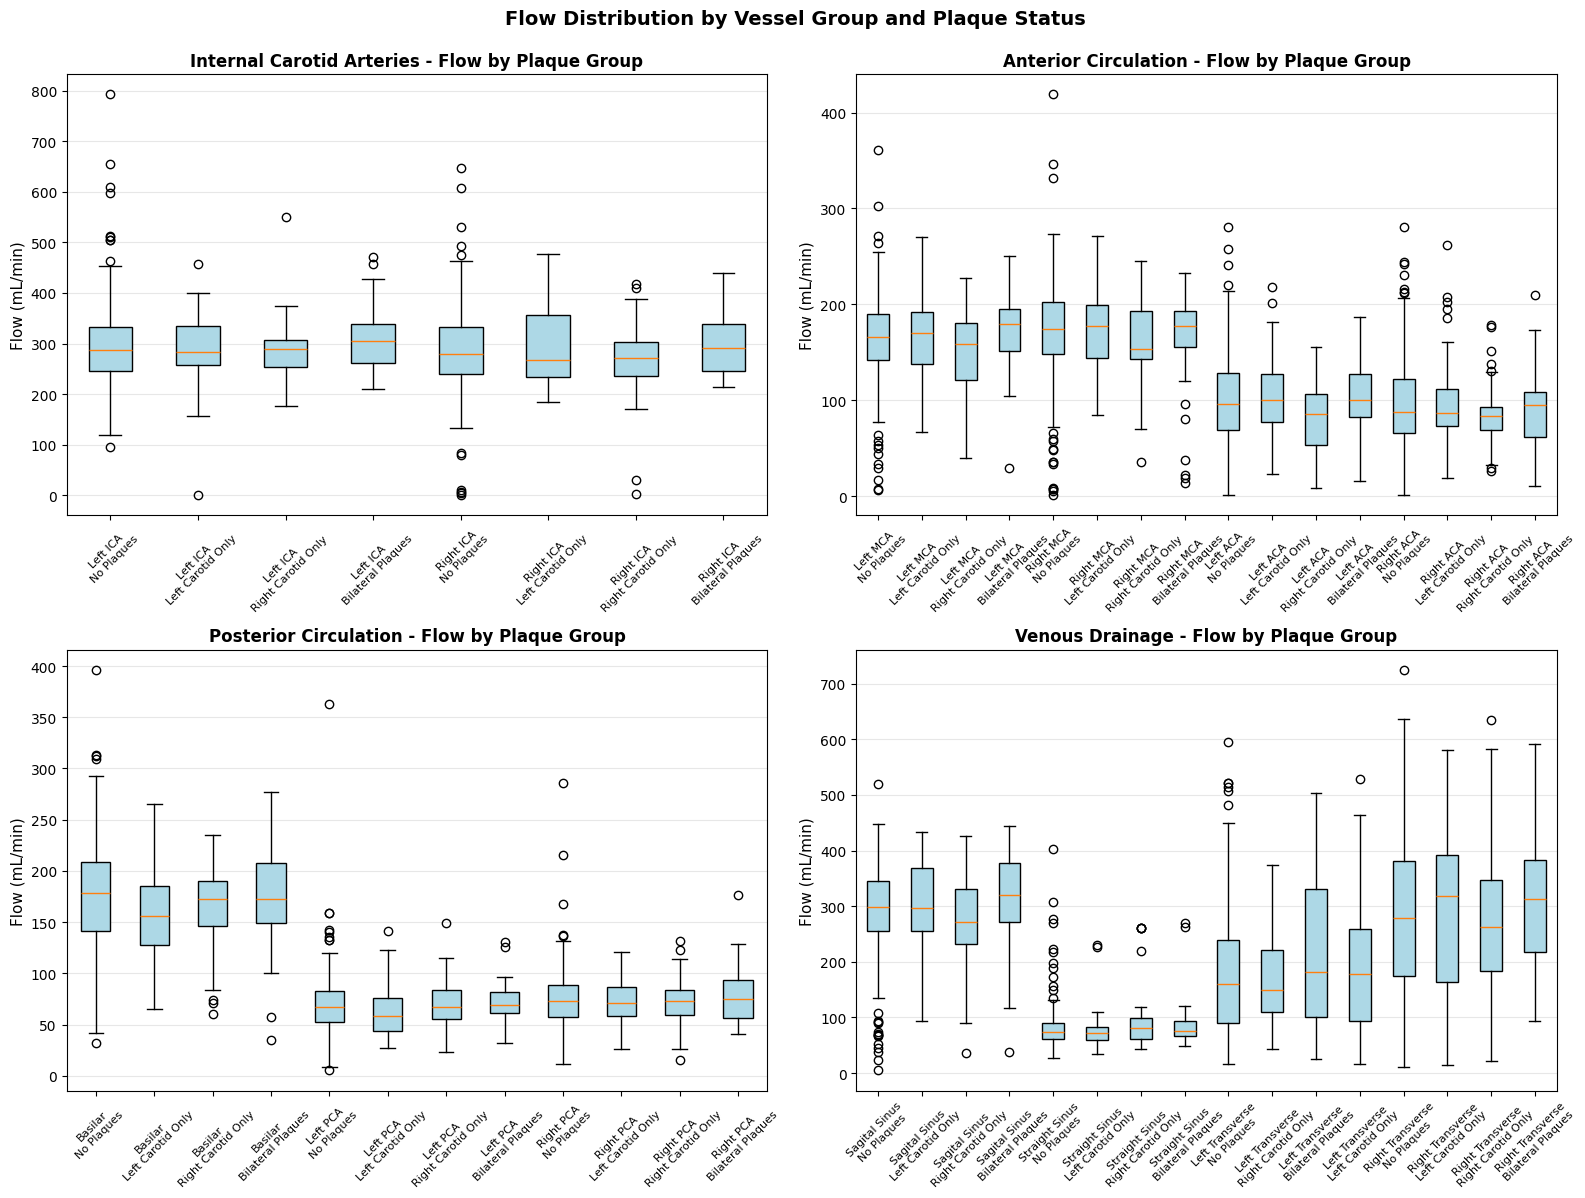

In [21]:
# Visualization 1: Plaque presence vs flow by vessel group
if plaque_vars and 'carotid_plaque_group' in merged_plaque.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    vessel_groups = {
        'Internal Carotid Arteries': ['Left ICA', 'Right ICA'],
        'Anterior Circulation': ['Left MCA', 'Right MCA', 'Left ACA', 'Right ACA'],
        'Posterior Circulation': ['Basilar', 'Left PCA', 'Right PCA'],
        'Venous Drainage': ['Sagital Sinus', 'Straight Sinus', 'Left Transverse', 'Right Transverse'],
    }
    
    for idx, (group_name, vessels) in enumerate(vessel_groups.items()):
        ax = axes[idx]
        
        # Aggregate flow for this group
        group_flows = []
        group_labels = []
        
        for vessel in vessels:
            if vessel in merged_plaque.columns:
                vessel_data = merged_plaque[[vessel, 'carotid_plaque_group']].dropna()
                for plaque_group in vessel_data['carotid_plaque_group'].unique():
                    mask = vessel_data['carotid_plaque_group'] == plaque_group
                    flows = vessel_data.loc[mask, vessel].values
                    if len(flows) > 0:
                        group_flows.append(flows)
                        group_labels.append(f"{vessel}\n{plaque_group}")
        
        if group_flows:
            bp = ax.boxplot(group_flows, labels=group_labels, patch_artist=True)
            for patch in bp['boxes']:
                patch.set_facecolor('lightblue')
            ax.set_ylabel('Flow (mL/min)', fontsize=11)
            ax.set_title(f'{group_name} - Flow by Plaque Group', fontsize=12, fontweight='bold')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.grid(True, alpha=0.3, axis='y')
        else:
            ax.axis('off')
    
    plt.suptitle('Flow Distribution by Vessel Group and Plaque Status', 
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

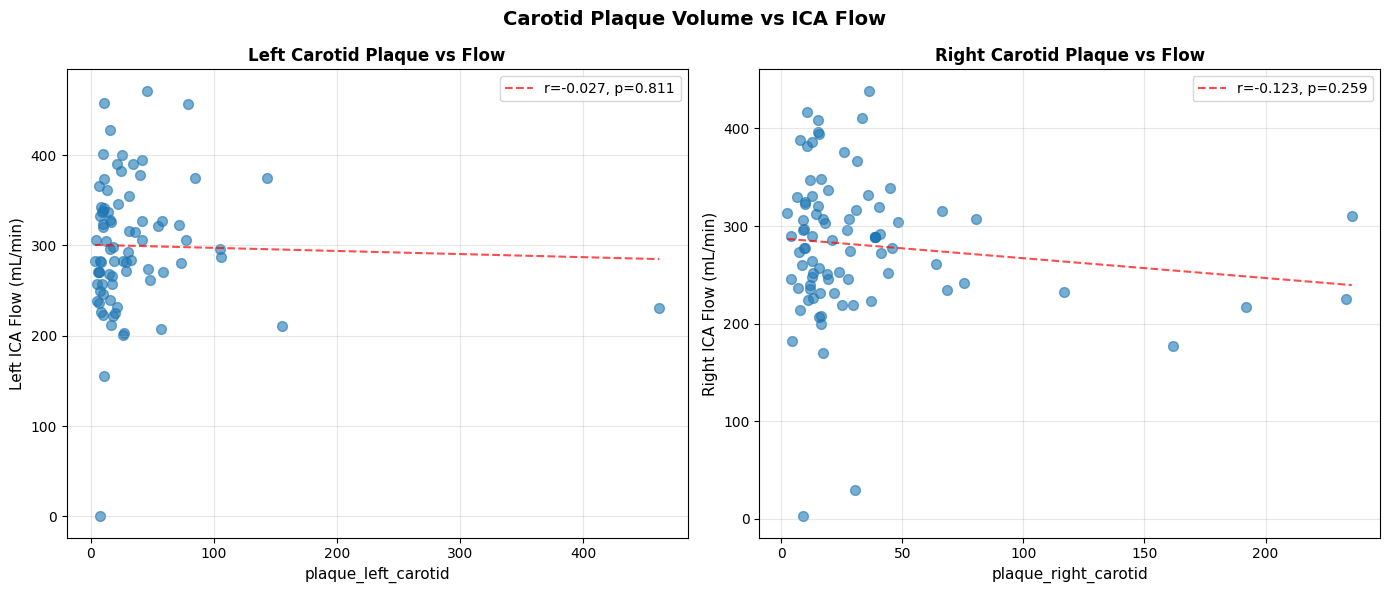

In [22]:
# Visualization 2: Plaque volume (if available) vs flow scatter
if plaque_vars:
    left_var = None
    right_var = None
    
    for var in plaque_vars:
        var_lower = var.lower()
        if "left" in var_lower:
            left_var = var
        elif "right" in var_lower:
            right_var = var
    
    if left_var or right_var:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Left carotid
        if left_var and left_var in merged_plaque.columns:
            ax = axes[0]
            # Not NaN and not 0
            data = merged_plaque[[left_var, 'Left ICA']].dropna()
            data = data[data[left_var] != 0]
            if len(data) > 0:
                ax.scatter(data[left_var], data['Left ICA'], alpha=0.6, s=50)
                if len(data) >= 2 and data[left_var].std() > 0 and data['Left ICA'].std() > 0:
                    r, p = stats.pearsonr(data[left_var], data['Left ICA'])
                    slope, intercept, _, _, _ = linregress(data[left_var], data['Left ICA'])
                    x_line = np.linspace(data[left_var].min(), data[left_var].max(), 100)
                    y_line = slope * x_line + intercept
                    ax.plot(x_line, y_line, 'r--', alpha=0.7, 
                           label=f'r={r:.3f}, p={p:.3g}')
                    ax.legend()
                ax.set_xlabel(f'{left_var}', fontsize=11)
                ax.set_ylabel('Left ICA Flow (mL/min)', fontsize=11)
                ax.set_title('Left Carotid Plaque vs Flow', fontsize=12, fontweight='bold')
                ax.grid(True, alpha=0.3)
        
        # Right carotid
        if right_var and right_var in merged_plaque.columns:
            ax = axes[1]
            data = merged_plaque[[right_var, 'Right ICA']].dropna()
            data = data[data[right_var] != 0]
            if len(data) > 0:
                ax.scatter(data[right_var], data['Right ICA'], alpha=0.6, s=50)
                if len(data) >= 2 and data[right_var].std() > 0 and data['Right ICA'].std() > 0:
                    r, p = stats.pearsonr(data[right_var], data['Right ICA'])
                    slope, intercept, _, _, _ = linregress(data[right_var], data['Right ICA'])
                    x_line = np.linspace(data[right_var].min(), data[right_var].max(), 100)
                    y_line = slope * x_line + intercept
                    ax.plot(x_line, y_line, 'r--', alpha=0.7, 
                           label=f'r={r:.3f}, p={p:.3g}')
                    ax.legend()
                ax.set_xlabel(f'{right_var}', fontsize=11)
                ax.set_ylabel('Right ICA Flow (mL/min)', fontsize=11)
                ax.set_title('Right Carotid Plaque vs Flow', fontsize=12, fontweight='bold')
                ax.grid(True, alpha=0.3)
        
        plt.suptitle('Carotid Plaque Volume vs ICA Flow', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

## Step 12: Mixed-Effects Models (Paper-faithful)

### In-Depth Explanation of Mixed Linear Models

This section implements and explains the mixed linear model (also called mixed-effects model or hierarchical linear model) from Roberts et al. (Radiology 2023) for analyzing cerebral hemodynamics.

#### **What is a Mixed Linear Model?**

A mixed linear model extends standard linear regression by incorporating both **fixed effects** (population-level parameters that are the same for all observations) and **random effects** (group-specific parameters that vary across groups). This is essential when data has a hierarchical or clustered structure, such as:
- Multiple measurements per participant (repeated measures)
- Multiple vessels per participant (nested structure)
- Both vessels and participants creating a crossed structure

#### **Our Model Formula**

The model we implement is:
```
flow ~ 1 + age + sex + (1 + age | vessel) + (1 | participant)
```

**Breaking down the formula:**

1. **`flow`** - The dependent variable (outcome)
   - For Flow: measured in mL/min
   - For PI: log-transformed pulsatility index

2. **`1`** - The intercept term (baseline flow when all predictors are zero/at reference)

3. **`age`** - Fixed effect for age
   - Represents the average change in flow per unit increase in age across all vessels and participants
   - In our implementation, we center age (`age_c = age - mean(age)`) for numerical stability

4. **`sex`** - Fixed effect for sex
   - Coded as 0 (Female) or 1 (Male)
   - Represents the average difference between males and females

5. **`(1 + age | vessel)`** - Random effects for vessels
   - **`1 | vessel`**: Random intercept per vessel
     - Each vessel (Left ICA, Right ICA, Basilar, etc.) has its own baseline flow level
     - Accounts for vessel-specific anatomical and physiological differences
   - **`age | vessel`**: Random slope for age per vessel
     - Each vessel can have a different relationship with age
     - Some vessels may decline faster with age than others
   - Together, this allows each vessel to have both a vessel-specific intercept and a vessel-specific age slope

6. **`(1 | participant)`** - Random intercept per participant
   - Each participant has their own baseline flow level
   - Accounts for individual differences in overall cerebral blood flow
   - This is a **crossed random effect** with vessels (each participant has measurements across multiple vessels)

#### **Mathematical Formulation**

The model can be written as:

**flow_ij = β₀ + β₁·age_ij + β₂·sex_i + u_i + v_j + w_j·age_ij + ε_ij**

Where:
- **β₀, β₁, β₂**: Fixed effects (intercept, age slope, sex effect)
- **u_i ~ N(0, σ²_u)**: Random intercept for participant i
- **v_j ~ N(0, σ²_v)**: Random intercept for vessel j
- **w_j ~ N(0, σ²_w)**: Random slope for age in vessel j
- **ε_ij ~ N(0, σ²_ε)**: Residual error

The random effects are assumed to be normally distributed with mean 0 and their own variance components.

#### **Implementation in statsmodels**

In `statsmodels.MixedLM`, the model is specified as:

```python
model = MixedLM.from_formula(
    formula="y ~ 1 + age_c + sex",
    groups=df["vessel"],                    # Grouping variable for random effects
    re_formula="1 + age_c",                 # Random effects formula: (1 + age | vessel)
    vc_formula={"participant": "0 + C(patient_id)"},  # Variance components: (1 | participant)
    data=df
)
```

**Key parameters:**
- **`groups`**: Defines the primary grouping structure (vessels in our case)
- **`re_formula`**: Specifies random effects that vary by the grouping variable
- **`vc_formula`**: Specifies variance components (crossed random effects like participant)

#### **Interpretation of Results**

**Fixed Effects:**
- **Intercept (β₀)**: Average flow at mean age for females (when age is centered and sex=0)
- **age_c (β₁)**: Average change in flow per year of age across all vessels
- **sex (β₂)**: Average difference in flow between males and females

**Random Effects (Variance Components):**
- **Vessel Intercept Variance (σ²_v)**: How much vessels differ in their baseline flow
- **Vessel Age Slope Variance (σ²_w)**: How much vessels differ in their age-related decline
- **Participant Intercept Variance (σ²_u)**: How much participants differ in their overall flow
- **Residual Variance (σ²_ε)**: Unexplained variation after accounting for all effects

**BLUPs (Best Linear Unbiased Predictors):**
- For each vessel, we can extract the predicted random intercept and slope
- These represent vessel-specific deviations from the population average
- Used to plot vessel-specific conditional fits

#### **Why This Model?**

1. **Accounts for clustering**: Multiple vessels per participant and multiple participants per vessel
2. **Vessel-specific effects**: Recognizes that different vessels may age differently
3. **Participant-level variation**: Accounts for individual differences in overall cerebral hemodynamics
4. **Efficient use of data**: Uses all available information while properly accounting for dependencies

#### **Model Assumptions**

1. **Linearity**: The relationship between predictors and outcome is linear
2. **Normality**: Random effects and residuals are normally distributed
3. **Homoscedasticity**: Residual variance is constant across groups
4. **Independence**: Observations are independent conditional on the random effects
5. **No multicollinearity**: Predictors are not perfectly correlated

#### **Model Fitting**

We use **REML (Restricted Maximum Likelihood)** estimation, which:
- Provides unbiased variance component estimates
- Is preferred for comparing models with different random effect structures
- Uses iterative optimization (L-BFGS method) to find parameter estimates

---

**Plots:**
- One 2×2 figure per outcome with the 4 vessel groups
- Per-vessel **model-implied conditional fits** (colored lines)
- One overall **fixed-effect** line (black dashed line)

In [17]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _safe_col(name: str) -> str:
    """Make column names formula-safe for patsy/statsmodels."""
    return re.sub(r"[^0-9a-zA-Z_]+", "_", name)


def _map_sex_to_numeric(s: pd.Series) -> pd.Series:
    # Accept already-numeric 0/1
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    ss = s.astype(str).str.strip().str.lower()
    mapping = {
        "male": 1,
        "m": 1,
        "1": 1,
        "female": 0,
        "f": 0,
        "0": 0,
        1: 1,
        0: 0,
        1.0: 1,
        0.0: 0,
    }
    out = ss.map(mapping)
    return pd.to_numeric(out, errors="coerce")


def build_long_vessel_df(
    clinical_df_in: pd.DataFrame,
    feature_table_in: pd.DataFrame,
    *,
    outcome_label: str,
    exclude_vessels: set[str] | None = None,
) -> pd.DataFrame:
    """Return long df with columns: patient_id, vessel, value, age, sex."""
    exclude_vessels = exclude_vessels or set()

    # Safe column names for modeling
    clinical_df = clinical_df_in.copy()
    clinical_df.columns = [_safe_col(c) for c in clinical_df.columns]

    feature_table = feature_table_in.copy()
    feature_table.columns = [_safe_col(c) for c in feature_table.columns]

    if "patient_id" not in clinical_df.columns:
        raise ValueError("clinical_df must include patient_id")
    if "patient_id" not in feature_table.columns:
        raise ValueError("feature_table must include patient_id")

    # Melt vessels
    vessel_cols = [c for c in feature_table.columns if c != "patient_id" and c not in {_safe_col(v) for v in exclude_vessels}]
    long = feature_table.melt(id_vars=["patient_id"], value_vars=vessel_cols, var_name="vessel", value_name="value")

    # Join clinical
    keep_cols = [c for c in ["patient_id", "age_at_mri", "sex"] if c in clinical_df.columns]
    if "age_at_mri" not in keep_cols:
        raise ValueError("clinical_df must include age_at_mri")
    if "sex" not in keep_cols:
        raise ValueError("clinical_df must include sex")

    merged = long.merge(clinical_df[keep_cols], on="patient_id", how="inner")

    merged = merged.rename(columns={"age_at_mri": "age"})
    merged["sex"] = _map_sex_to_numeric(merged["sex"])

    # Clean
    merged["value"] = pd.to_numeric(merged["value"], errors="coerce")
    merged["age"] = pd.to_numeric(merged["age"], errors="coerce")

    merged = merged.dropna(subset=["patient_id", "vessel", "value", "age", "sex"]).copy()

    # Center age for numerical stability (does not change slopes, only intercept meaning)
    merged["age_c"] = merged["age"] - float(merged["age"].mean())

    merged["outcome"] = outcome_label

    return merged


VESSEL_GROUPS_ORDER = {
    "Internal Carotid Arteries": ["Left_ICA", "Right_ICA"],
    "Venous Drainage": ["Sagital_Sinus", "Straight_Sinus", "Left_Transverse", "Right_Transverse"],
    "Anterior Circulation": [
        "Left_MCA",
        "Right_MCA",
        "Left_ACA",
        "Right_ACA",
        "Left_Communicating",
        "Right_Communicating",
    ],
    "Posterior Circulation": ["Basilar", "Left_PCA", "Right_PCA"],
}

VESSEL_GROUPS_ORDER_BY_CODE = {
    "Internal Carotid Arteries": ["LICA", "RICA"],
    "Venous Drainage": ["SSSV", "STRV", "LTSV", "RTSV"],
    "Anterior Circulation": [
        "LMCA",
        "RMCA",
        "LACA",
        "RACA",
        "LCOM",
        "RCOM",
    ],
    "Posterior Circulation": ["BASI", "LPCA", "RPCA"],
}



def _load_paper_mixedlm(model_path: Path, *, outcome: str, long_df: pd.DataFrame=None):
    from statsmodels.regression.mixed_linear_model import MixedLM
    
    if df:
        df = long_df.copy().reset_index(drop=True)
        df = df.dropna(subset=["patient_id", "vessel", "age", "age_c", "sex", "value"]).reset_index(drop=True)

        # Outcome
        if outcome.lower() == "flow":
            df["y"] = pd.to_numeric(df["value"], errors="coerce")
        elif outcome.lower() in {"pi_log", "log_pi", "pi"}:
            df["value"] = pd.to_numeric(df["value"], errors="coerce")
            df = df.dropna(subset=["value"]).copy()
            df = df[df["value"] > 0].copy()
            df["y"] = np.log(df["value"].astype(float))
        else:
            raise ValueError("outcome must be 'flow' or 'pi_log'")

        # Stable vessel categories
        vessels = sorted(df["vessel"].unique())
        df["vessel"] = pd.Categorical(df["vessel"], categories=vessels)

        # Fixed effects
        formula = "y ~ 1 + age_c + sex"

        # Random effects: (1 + age_c | vessel) + (1 | participant)
        vc = {"participant": "0 + C(patient_id)"}

        model = MixedLM.from_formula(
            formula,
            groups=df["vessel"],
            re_formula="1 + age_c",
            vc_formula=vc,
            data=df,
        ).load(model_path)
        return model, df

    model = MixedLM.load(model_path)
    return model

def _fit_paper_mixedlm(long_df: pd.DataFrame, *, outcome: str, model_path: Path = None):
    """Paper models (crossed random effects) implemented in statsmodels.

    Paper equations:
    - Flow: flow ~ 1 + age + sex + (1 + age | vessel) + (1 | participant)
    - PI:   log(PI) ~ 1 + age + sex + (1 + age | vessel) + (1 | participant)

    Implementation in statsmodels (approx. crossed RE):
    - groups = vessel, re_formula = "1 + age_c"        -> (1 + age | vessel)
    - vc_formula for participant intercepts             -> (1 | participant)

    Returns:
    - res: MixedLMResults
    - df_fit: the exact dataframe used for fitting (includes y)
    """
    import warnings

    from statsmodels.regression.mixed_linear_model import MixedLM
    from statsmodels.tools.sm_exceptions import ConvergenceWarning

    df = long_df.copy().reset_index(drop=True)
    df = df.dropna(subset=["patient_id", "vessel", "age", "age_c", "sex", "value"]).reset_index(drop=True)

    # Outcome
    if outcome.lower() == "flow":
        df["y"] = pd.to_numeric(df["value"], errors="coerce")
        y_label = "Flow (mL/min)"
    elif outcome.lower() in {"pi_log", "log_pi", "pi"}:
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna(subset=["value"]).copy()
        df = df[df["value"] > 0].copy()
        df["y"] = np.log(df["value"].astype(float))
        y_label = "log(PI)"
    else:
        raise ValueError("outcome must be 'flow' or 'pi_log'")

    # Stable vessel categories
    vessels = sorted(df["vessel"].unique())
    df["vessel"] = pd.Categorical(df["vessel"], categories=vessels)

    # Fixed effects
    formula = "y ~ 1 + age_c + sex"

    # Random effects: (1 + age_c | vessel) + (1 | participant)
    vc = {"participant": "0 + C(patient_id)"}

    model = MixedLM.from_formula(
        formula,
        groups=df["vessel"],
        re_formula="1 + age_c",
        vc_formula=vc,
        data=df,
    )

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
        warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")
        warnings.filterwarnings("ignore", category=ConvergenceWarning, module="statsmodels")
        res = model.fit(reml=True, method="lbfgs", maxiter=1200)

    try:
        y_hat = res.predict(df)
        print(f"Sanity [{y_label}]: obs_mean={float(np.nanmean(df['y'])):.3g} pred_mean={float(np.nanmean(y_hat)):.3g}")
    except Exception:
        pass

    if model_path is not None:
        print(f"Saving model to {model_path}")
        res.save(model_path)

    return res, df


def _predict_fixed_from_formula(res, rhs_formula: str, df_pred: pd.DataFrame) -> np.ndarray:
    """Fixed-effect prediction for a fitted MixedLM.

    Strategy:
    - Try `res.predict(df_pred)` first (statsmodels handles patsy coding internally).
    - Fallback to building the design matrix from `res.model.data.design_info`.

    We keep this helper because categorical coding for `vessel` is easy to get wrong.
    """

    # 1) Fast path: let statsmodels/patsy handle it
    try:
        y = res.predict(df_pred)
        y = np.asarray(y, dtype=float)
        if np.isfinite(y).all():
            return y
    except Exception:
        pass

    # 2) Fallback: explicit design-matrix multiply
    import patsy

    design_info = res.model.data.design_info
    X = patsy.build_design_matrices([design_info], df_pred, return_type="dataframe")[0]

    fe = res.fe_params
    X = X.reindex(columns=fe.index, fill_value=0.0)

    y = X.to_numpy() @ fe.to_numpy()
    return np.asarray(y, dtype=float)


def plot_paper_conditional_fits_by_group(
    df_fit: pd.DataFrame,
    res,
    *,
    output_path: Path,
    title: str,
    y_label: str,
    sex_ref: str = "mean",
):
    """Replicate paper Fig5/Fig6 style using crossed random effects.

    Model-implied lines:
    - Colored: conditional vessel fits = fixed effects + vessel random effects (BLUPs)
    - Black: fixed effect only (population average)

    Participant random intercepts are *not* drawn (paper shows vessel lines + fixed line).
    """

    output_path.parent.mkdir(parents=True, exist_ok=True)

    if sex_ref == "mean":
        sex_val = float(pd.to_numeric(df_fit["sex"], errors="coerce").mean())
    elif sex_ref == "female":
        sex_val = 0.0
    elif sex_ref == "male":
        sex_val = 1.0
    else:
        raise ValueError("sex_ref must be one of: mean, female, male")

    ages = pd.to_numeric(df_fit["age"], errors="coerce").to_numpy()
    ages = ages[np.isfinite(ages)]
    x_line = np.linspace(float(np.nanmin(ages)), float(np.nanmax(ages)), 200)

    # Use the fit's centering constant for age_c
    try:
        age_mean_fit = float(np.nanmean(pd.to_numeric(res.model.data.frame["age"], errors="coerce")))
    except Exception:
        age_mean_fit = float(np.nanmean(pd.to_numeric(df_fit["age"], errors="coerce")))

    x_line_c = x_line - age_mean_fit

    fe = res.fe_params
    b0 = float(fe.get("Intercept", fe.get("const", 0.0)))
    b_age = float(fe.get("age_c", 0.0))
    b_sex = float(fe.get("sex", 0.0))

    # Fixed-effect line
    y_fixed = b0 + b_age * x_line_c + b_sex * sex_val

    try:
        p_age = float(res.pvalues.get("age_c", np.nan))
        p_sex = float(res.pvalues.get("sex", np.nan))
    except Exception:
        p_age = np.nan
        p_sex = np.nan

    vessels_all = sorted(df_fit["vessel"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=False)
    axes = axes.flatten()

    for ax, (group_name, vessels) in zip(axes, VESSEL_GROUPS_ORDER.items()):
        vessels_present = [v for v in vessels if v in set(vessels_all)]
        if not vessels_present:
            ax.axis("off")
            continue

        palette = sns.color_palette("husl", n_colors=len(vessels_present))

        for i, v in enumerate(vessels_present):
            sub = df_fit[df_fit["vessel"] == v]
            ax.scatter(sub["age"], sub["y"], s=12, alpha=0.7, color=palette[i])

            # Vessel BLUPs (random intercept + random age slope)
            re = res.random_effects.get(v, None)
            if re is None and isinstance(v, str):
                re = res.random_effects.get(str(v), None)

            re_int = 0.0
            re_age = 0.0
            if re is not None:
                try:
                    # statsmodels typically uses 'Group' for intercept
                    re_int = float(re.get("Group", re.iloc[0]))
                except Exception:
                    try:
                        re_int = float(re.iloc[0])
                    except Exception:
                        re_int = 0.0
                try:
                    re_age = float(re.get("age_c", re.iloc[1] if len(re) > 1 else 0.0))
                except Exception:
                    re_age = 0.0

            y_v = (b0 + re_int) + (b_age + re_age) * x_line_c + b_sex * sex_val
            ax.plot(x_line, y_v, color=palette[i], linewidth=3, alpha=1, label=v)

        ax.plot(
            x_line,
            y_fixed,
            color="black",
            linewidth=3.7,
            linestyle="--",
            label=f"Fixed effect (age_c p={p_age:.2g}, sex p={p_sex:.2g})",
        )

        ax.set_title(group_name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Age")
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=11)

    fig.suptitle(f"{title} (sex_ref={sex_ref})", fontsize=15, fontweight="bold")
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_paper_random_effects_by_vessel(
    df_fit: pd.DataFrame,
    res,
    *,
    output_path: Path,
    title: str,
    y_label: str,
    group_name: str = "vessel",
    age_var: str = "age",
    age_c_var: str = "age_c",
    sex_ref: str = "mean",
):
    """
    Create paper-style random effects plot showing vessel intercepts and age slopes.
    
    This creates a two-panel plot:
    1. Top panel: Vessel random intercepts (absolute values: fixed + random)
    2. Bottom panel: Vessel random age slopes (absolute values: fixed + random)
    
    Parameters:
    -----------
    df_fit : pd.DataFrame
        Dataframe used for fitting
    res : MixedLMResults
        Fitted mixed linear model results
    output_path : Path
        Path to save the figure
    title : str
        Title for the plot
    y_label : str
        Label for y-axis units (e.g., "mL/min", "au")
    group_name : str
        Name of the grouping variable (e.g., "vessel")
    age_var : str
        Name of age variable (uncentered)
    age_c_var : str
        Name of centered age variable
    sex_ref : str
        Reference sex value: "mean", "female", or "male"
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Get fixed effects
    fe = res.fe_params
    b0 = float(fe.get("Intercept", fe.get("const", 0.0)))
    b_age = float(fe.get(age_c_var, fe.get("age_c", 0.0)))
    b_sex = float(fe.get("sex", 0.0))
    
    # Get sex reference value
    if sex_ref == "mean":
        sex_val = float(pd.to_numeric(df_fit["sex"], errors="coerce").mean())
    elif sex_ref == "female":
        sex_val = 0.0
    elif sex_ref == "male":
        sex_val = 1.0
    else:
        sex_val = float(pd.to_numeric(df_fit["sex"], errors="coerce").mean())
    
    # Get age mean for fixed effect calculation
    try:
        age_mean_fit = float(np.nanmean(pd.to_numeric(res.model.data.frame[age_var], errors="coerce")))
    except Exception:
        age_mean_fit = float(np.nanmean(pd.to_numeric(df_fit[age_var], errors="coerce")))
    
    # Extract random effects (BLUPs) for vessels
    re_dict = res.random_effects if hasattr(res, 'random_effects') else {}
    vessel_names = sorted(df_fit[group_name].unique())
    
    # Extract vessel-specific random intercepts and slopes (these are DEVIATIONS from fixed effects)
    vessel_re_intercepts = {}  # Random effects (deviations)
    vessel_re_slopes = {}      # Random effects (deviations)
    
    for vessel in vessel_names:
        re = re_dict.get(vessel, None)
        if re is None and isinstance(vessel, str):
            re = re_dict.get(str(vessel), None)
        
        re_int = 0.0
        re_age = 0.0
        
        if re is not None:
            try:
                if isinstance(re, pd.Series):
                    if len(re) >= 1:
                        re_int = float(re.iloc[0])
                    if len(re) >= 2:
                        re_age = float(re.iloc[1])
                elif isinstance(re, pd.DataFrame):
                    if 'Group' in re.columns or 'Intercept' in re.columns:
                        re_int = float(re.iloc[0, 0])
                    if age_c_var in re.columns or 'age_c' in re.columns:
                        re_age = float(re.iloc[0, 1] if re.shape[1] > 1 else 0.0)
                    elif re.shape[1] >= 2:
                        re_int = float(re.iloc[0, 0])
                        re_age = float(re.iloc[0, 1])
                else:
                    re_array = np.array(re).flatten()
                    if len(re_array) >= 1:
                        re_int = float(re_array[0])
                    if len(re_array) >= 2:
                        re_age = float(re_array[1])
            except Exception:
                pass
        
        vessel_re_intercepts[vessel] = re_int  # This is the deviation
        vessel_re_slopes[vessel] = re_age      # This is the deviation
    
    # Calculate ABSOLUTE intercepts and slopes (fixed + random)
    # For intercepts: absolute intercept = fixed intercept + random intercept deviation
    # At reference age (mean age, where age_c = 0) and reference sex
    fixed_intercept_at_ref = b0 + b_age * 0.0 + b_sex * sex_val  # Fixed intercept at mean age
    
    vessel_absolute_intercepts = {}
    vessel_absolute_slopes = {}
    
    for vessel in vessel_names:
        # Absolute intercept = fixed intercept + random intercept deviation
        vessel_absolute_intercepts[vessel] = fixed_intercept_at_ref + vessel_re_intercepts.get(vessel, 0.0)
        # Absolute slope = fixed slope + random slope deviation
        vessel_absolute_slopes[vessel] = b_age + vessel_re_slopes.get(vessel, 0.0)
    
    # Organize vessels - try to match paper's order
    vessel_order = []
    
    # Paper order
    paper_vessel_order = [
        "LICA", "RICA", 
        "LMCA", "RMCA", "LACA", "RACA",
        "BA", "LPCA", "RPCA",
        "STR", "SSS", "LTS", "RTS"
    ]
    
    # Map your vessel names to paper names (adjust as needed)
    vessel_name_mapping = {
        "Left_ICA": "LICA",
        "Right_ICA": "RICA",
        "Left_MCA": "LMCA",
        "Right_MCA": "RMCA",
        "Left_ACA": "LACA",
        "Right_ACA": "RACA",
        "Basilar": "BA",
        "Left_PCA": "LPCA",
        "Right_PCA": "RPCA",
        "Sagital_Sinus": "SSS",
        "Straight_Sinus": "STR",
        "Left_Transverse": "LTS",
        "Right_Transverse": "RTS",
    }
    
    # Build ordered list
    for paper_name in paper_vessel_order:
        for our_vessel in vessel_names:
            if our_vessel == paper_name or vessel_name_mapping.get(our_vessel) == paper_name:
                if our_vessel not in vessel_order:
                    vessel_order.append(our_vessel)
                    break
    
    # Add any remaining vessels
    for vessel in vessel_names:
        if vessel not in vessel_order:
            vessel_order.append(vessel)

    vessel_order = vessel_order[::-1]
    
    # Extract absolute values in order
    intercepts_ordered = [vessel_absolute_intercepts.get(v, fixed_intercept_at_ref) for v in vessel_order]
    slopes_ordered = [vessel_absolute_slopes.get(v, b_age) for v in vessel_order]
    
    # Create figure with two panels
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, max(10, len(vessel_order) * 0.5)), sharey=True)
    
    y_pos = np.arange(len(vessel_order))
    
    # ========== TOP PANEL: Intercepts ==========
    # Plot absolute intercepts
    ax1.scatter(intercepts_ordered, y_pos, s=100, alpha=0.7, color='steelblue', 
                edgecolors='black', linewidth=0.8, zorder=3)
    
    # Fixed effect line at the fixed intercept value
    ax1.axvline(x=fixed_intercept_at_ref, color='black', linewidth=2.5, 
                linestyle='-', zorder=2, label=f'Fixed Effect (at age={age_mean_fit:.0f})')
    
    # Add arrow pointing to fixed effect line
    ax1.annotate('', xy=(fixed_intercept_at_ref, len(vessel_order) - 0.5), 
                xytext=(fixed_intercept_at_ref, len(vessel_order) + 0.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(vessel_order, fontsize=10)
    ax1.set_xlabel(f'Intercept ({y_label})', fontsize=12, fontweight='bold')
    ax1.set_title('Intercept ({})'.format(y_label), fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.legend(loc='best', fontsize=9)
    ax1.invert_yaxis()
    
    # ========== BOTTOM PANEL: Age Slopes ==========
    # Plot absolute slopes
    ax2.scatter(slopes_ordered, y_pos, s=100, alpha=0.7, color='coral', 
                edgecolors='black', linewidth=0.8, zorder=3)
    
    # Fixed effect line at the fixed slope value
    ax2.axvline(x=b_age, color='black', linewidth=2.5, 
                linestyle='-', zorder=2, label=f'Fixed Effect')
    
    # Add arrow pointing to fixed effect line
    ax2.annotate('', xy=(b_age, len(vessel_order) - 0.5), 
                xytext=(b_age, len(vessel_order) + 0.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(vessel_order, fontsize=10)
    ax2.set_xlabel(f'Age ({y_label}/year)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Age ({y_label}/year)', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.legend(loc='best', fontsize=9)
    ax2.invert_yaxis()
    
    # Overall title
    fig.suptitle(f'{title} - Random Effects by {group_name.capitalize()}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Adjust layout
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    print(f"✓ Saved random effects plot: {output_path}")


def extract_participant_intercept_variance(res):
    """
    Extract participant-intercept variance from vc_formula.
    
    In statsmodels, variance components from vc_formula are stored in 
    the model's variance component structure, which may be in:
    - res.cov_params_re (if available)
    - res.model.vcomp (variance components)
    - Or calculated from the model structure
    """
    participant_var = None
    participant_sd = None
    
    # Method 1: Try to get from variance components
    if hasattr(res, 'model') and hasattr(res.model, 'vcomp'):
        vcomp = res.model.vcomp
        if vcomp is not None:
            # vcomp is a dict with variance component names
            for vc_name, vc_value in vcomp.items():
                if 'participant' in vc_name.lower() or 'patient' in vc_name.lower():
                    participant_var = float(vc_value)
                    participant_sd = np.sqrt(participant_var)
                    break
    
    # Method 2: Try to extract from cov_params_re
    if participant_var is None and hasattr(res, 'cov_params_re'):
        try:
            cov_params = res.cov_params_re
            if isinstance(cov_params, pd.DataFrame):
                # Look for participant-related variance components
                for idx in cov_params.index:
                    if 'participant' in str(idx).lower() or 'patient' in str(idx).lower():
                        participant_var = float(cov_params.loc[idx, idx])
                        participant_sd = np.sqrt(participant_var)
                        break
        except:
            pass
    
    # Method 3: Try to get from summary tables
    if participant_var is None:
        try:
            summary_tables = res.summary().tables
            for table in summary_tables:
                if hasattr(table, 'data'):
                    for row in table.data:
                        if isinstance(row, list) and len(row) > 0:
                            row_str = str(row[0]).lower()
                            if 'participant' in row_str or 'patient' in row_str:
                                # Try to extract variance from this row
                                for cell in row[1:]:
                                    try:
                                        val = float(cell)
                                        if val > 0:  # Variance should be positive
                                            participant_var = val
                                            participant_sd = np.sqrt(participant_var)
                                            break
                                    except:
                                        continue
                                if participant_var:
                                    break
        except:
            pass
    
    return participant_var, participant_sd

def print_mixedlm_summary(
    res,
    *,
    outcome_name: str = "Outcome",
    formula: str = None,
    model_type: str = "Mixed Linear Model",
    group_name: str = None,
):
    """
    Print a beautified and comprehensive summary of a MixedLM model fit.
    
    Parameters:
    -----------
    res : MixedLMResults
        Fitted mixed linear model results from statsmodels
    outcome_name : str
        Name of the outcome variable (e.g., "Flow (mL/min)", "log(PI)")
    formula : str, optional
        Model formula string to display
    model_type : str
        Type of model (for header display)
    group_name : str, optional
        Name of the grouping variable (e.g., "vessel", "participant")
        If None, will try to infer from model
    """
    # More flexible type checking - check for required attributes instead of exact type
    required_attrs = ['fe_params', 'summary', 'nobs']
    missing_attrs = [attr for attr in required_attrs if not hasattr(res, attr)]
    
    if missing_attrs:
        raise ValueError(
            f"res must be a MixedLMResults object from statsmodels. "
            f"Missing required attributes: {missing_attrs}"
        )
    
    # Get summary tables
    summary = res.summary()
    
    # Infer group name if not provided
    if group_name is None:
        if hasattr(res, 'model') and hasattr(res.model, 'groups'):
            groups_obj = res.model.groups
            if hasattr(groups_obj, 'name'):
                group_name = groups_obj.name
            else:
                group_name = "Groups"
        else:
            group_name = "Groups"
    
    # Print header
    print("=" * 80)
    print(f"  {model_type} - {outcome_name}")
    print("=" * 80)
    print()
    
    # Print model formula
    if formula:
        print("MODEL FORMULA:")
        print(f"  {formula}")
        print()
    else:
        # Try to extract from model
        try:
            model_formula = str(res.model.formula)
            print("MODEL FORMULA:")
            print(f"  {model_formula}")
            print()
        except:
            pass
    
    # Model information
    print("MODEL INFORMATION:")
    print(f"  Number of observations: {res.nobs:,}")
    print(f"  Number of subjects: {res.model.data.frame['patient_id'].nunique():,}")
    
    # Try to get number of groups
    ngroups = None
    if hasattr(res, 'ngroups'):
        ngroups = res.ngroups
    elif hasattr(res, 'model') and hasattr(res.model, 'n_groups'):
        ngroups = res.model.n_groups
    elif hasattr(res, 'random_effects'):
        ngroups = len(res.random_effects)
    
    if ngroups is not None:
        print(f"  Number of {group_name} groups: {ngroups:,}")
    
    print(f"  Group variable: {group_name}")
    # print(f"  Estimation method: {'REML' if getattr(res, 'reml', False) else 'ML'}")
    print(f"  Optimization method: {getattr(res, 'method', 'N/A')}")
    print()
    
    # Fixed Effects
    print("-" * 80)
    print("FIXED EFFECTS (Population-Level Parameters):")
    print("-" * 80)
    
    fe_params = res.fe_params
    fe_se = getattr(res, 'bse_fe', None)
    if fe_se is None:
        fe_se = getattr(res, 'bse', pd.Series())
    
    fe_pvalues = getattr(res, 'pvalues_fe', None)
    if fe_pvalues is None:
        fe_pvalues = getattr(res, 'pvalues', pd.Series())
    
    # Get degrees of freedom for fixed effects
    # In mixed models, df for fixed effects is typically n_obs - n_groups - n_fixed_params
    # df_resid = getattr(res, 'df_resid', None)
    # if df_resid is None:
    #     # Approximate: n_obs - n_fixed_params (conservative estimate)
    #     df_resid = res.nobs - len(fe_params)
    
    # Create meaningful names mapping
    name_mapping = {
        'Intercept': 'Intercept (Baseline)',
        'const': 'Intercept (Baseline)',
        'age_c': 'Age (centered)',
        'age': 'Age',
        'sex': 'Sex (Ref. Female)',
        'C(vessel)[T.Right_ICA]': 'Vessel: Right ICA (vs reference)',
        'C(vessel)[T.Basilar]': 'Vessel: Basilar (vs reference)',
    }
    
    print(f"{'Parameter':<30} {'Coefficient':>15} {'Std. Error':>15} {'DF':>8} {'P-value':>12} {'Significance':>12}")
    print("-" * 80)
    
    for param in fe_params.index:
        coef = fe_params[param]
        se = fe_se.get(param, np.nan) if isinstance(fe_se, pd.Series) else np.nan
        pval = fe_pvalues.get(param, np.nan) if isinstance(fe_pvalues, pd.Series) else np.nan
        
        # param_df = df_resid
        
        # Get meaningful name
        display_name = name_mapping.get(param, param)
        if 'C(vessel)' in display_name:
            display_name = display_name.replace('C(vessel)[T.', '').replace(']', '')
        
        # Significance stars
        if pd.notna(pval):
            if pval < 0.001:
                sig = "***"
            elif pval < 0.01:
                sig = "**"
            elif pval < 0.05:
                sig = "*"
            elif pval < 0.1:
                sig = "."
            else:
                sig = "NS"
        else:
            sig = ""
        
        # Format values
        coef_str = f"{coef:>15.4f}" if pd.notna(coef) else f"{'N/A':>15}"
        se_str = f"{se:>15.4f}" if pd.notna(se) else f"{'N/A':>15}"
        # df_str = f"{param_df:>8.1f}" if param_df is not None else f"{'N/A':>8}"
        pval_str = f"{pval:>12.4f}" if pd.notna(pval) and pval >= 0.0001 else (f"{pval:>12.2e}" if pd.notna(pval) else f"{'N/A':>12}")
        
        print(f"{display_name:<30} {coef_str} {se_str} {pval_str} {sig:>12}") #  {df_str}
    
    print()
    print("Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 'NS' 1")
    # if df_resid is not None:
    #     print(f"Degrees of Freedom: Residual DF ≈ {df_resid:.1f} (approximate, may vary by estimation method)")
    print()
    
    # Random Effects (Variance Components) - ENHANCED SECTION
    print("-" * 80)
    print("RANDOM EFFECTS (Variance Components):")
    print("-" * 80)
    print()
    
    # Extract standard deviations for each random effect component
    re_std_dict = {}
    
    # 1. Extract from re_formula (Vessel Intercept and Vessel Age Slope)
    if hasattr(res, 'cov_re') and res.cov_re is not None:
        print("VARIANCE-COVARIANCE MATRIX FOR RANDOM EFFECTS (from re_formula):")
        print("=" * 80)
        cov_re = res.cov_re
        
        # Get re_formula to understand structure
        re_formula = None
        if hasattr(res, 'model') and hasattr(res.model, 're_formula'):
            re_formula = res.model.re_formula
        
        # Create meaningful labels
        if isinstance(cov_re, pd.DataFrame):
            print(cov_re.to_string())
            var_names = cov_re.index.tolist()
            diag = np.diag(cov_re.values)
        else:
            cov_re_df = pd.DataFrame(cov_re)
            
            # Infer names from re_formula
            if re_formula:
                if 'age_c' in re_formula or 'age' in re_formula:
                    if '1' in re_formula or 'Intercept' in re_formula:
                        var_names = [f"{group_name.capitalize()} Intercept", f"{group_name.capitalize()} Age Slope"]
                    else:
                        var_names = [f"{group_name.capitalize()} Age Slope"]
                else:
                    var_names = [f"{group_name.capitalize()} Intercept"]
            else:
                if cov_re_df.shape[0] == 2:
                    var_names = [f"{group_name.capitalize()} Intercept", f"{group_name.capitalize()} Age Slope"]
                elif cov_re_df.shape[0] == 1:
                    var_names = [f"{group_name.capitalize()} Intercept"]
                else:
                    var_names = [f"{group_name.capitalize()} RE {i+1}" for i in range(cov_re_df.shape[0])]
            
            if len(var_names) == cov_re_df.shape[0]:
                cov_re_df.index = var_names
                cov_re_df.columns = var_names
            
            print(cov_re_df.to_string())
            diag = np.diag(cov_re.values)
        
        print()
        print("Interpretation:")
        print("  - Diagonal elements: Variances of random effects")
        print("  - Off-diagonal elements: Covariances between random effects")
        print()
        
        # Extract standard deviations
        print("STANDARD DEVIATIONS (from re_formula):")
        print("-" * 80)
        for i, (name, var) in enumerate(zip(var_names, diag)):
            std = np.sqrt(var)
            re_std_dict[name] = std
            print(f"  {name}:")
            print(f"    Variance (σ²): {var:.6f}")
            print(f"    Standard Deviation (σ): {std:.6f}")
        print()
        
        # Correlation matrix if multiple random effects
        if len(diag) > 1:
            print("CORRELATION MATRIX (between random effects):")
            print("-" * 80)
            if isinstance(cov_re, pd.DataFrame):
                corr_matrix = cov_re / np.sqrt(np.outer(diag, diag))
                corr_matrix = pd.DataFrame(corr_matrix, index=cov_re.index, columns=cov_re.columns)
            else:
                corr_matrix = cov_re / np.sqrt(np.outer(diag, diag))
                corr_matrix = pd.DataFrame(corr_matrix, index=var_names, columns=var_names)
            print(corr_matrix.to_string())
            print()
    
    # 2. Extract from vc_formula (Participant Intercept)
    participant_std = None
    if hasattr(res.model, 'vc_formula') and res.model.vc_formula:
        print("VARIANCE COMPONENTS (from vc_formula):")
        print("-" * 80)
        
        vc_formula = res.model.vc_formula
        for vc_name, vc_formula_str in vc_formula.items():
            # Try multiple methods to extract variance
            vc_variance = None
            vc_sd = None
            
            # Method 1: Direct extraction
            participant_var, participant_sd = extract_participant_intercept_variance(res)
            if participant_var is not None:
                vc_variance = participant_var
                vc_sd = participant_sd
            
            # Method 2: Try from model attributes
            if vc_variance is None:
                try:
                    # Check if model has vcomp attribute
                    if hasattr(res.model, 'vcomp') and res.model.vc_formula:
                        # The variance might be in the model's internal structure
                        # This is model-specific
                        pass
                except:
                    pass
            
            # Method 3: Calculate from scale if participant variance is part of residual
            # Note: This is a simplification - actual extraction may be more complex
            if vc_variance is None:
                print(f"  {vc_name.capitalize()} Intercept Variance:")
                print(f"    Note: Variance component extraction for '{vc_name}' requires inspection")
                print(f"    Formula: {vc_formula_str}")
                print(f"    (Try: res.model.vcomp or check res.summary().tables)")
            else:
                print(f"  {vc_name.capitalize()} Intercept Variance:")
                print(f"    Variance (σ²): {vc_variance:.6f}")
                print(f"    Standard Deviation (σ): {vc_sd:.6f}")
            print()
    
    # Summary of all standard deviations
    if re_std_dict:
        print("SUMMARY OF RANDOM EFFECT STANDARD DEVIATIONS:")
        print("-" * 80)
        for name, std in re_std_dict.items():
            print(f"  {name}: σ = {std:.6f}")
        print()
    
    # Residual variance
    if hasattr(res, 'scale'):
        print("RESIDUAL VARIANCE:")
        print("-" * 80)
        residual_var = res.scale
        residual_sd = np.sqrt(residual_var)
        print(f"  Residual Variance (σ²_ε): {residual_var:.6f}")
        print(f"  Residual Standard Deviation (σ_ε): {residual_sd:.6f}")
        
        # Degrees of freedom for residual variance
        # In REML: df_resid = n_obs - n_fixed_params
        # In ML: df_resid = n_obs - n_fixed_params - n_random_params
        # if df_resid is not None:
        #     print(f"  Residual Degrees of Freedom: {df_resid:.1f}")
        
        print()
        print("Interpretation:")
        print("  - Represents unexplained variation after accounting for all fixed and random effects")
        print("  - Lower values indicate better model fit")
        print("  - Standard deviation is in the same units as the outcome variable")
        print("  - Degrees of freedom: number of observations minus parameters estimated")
        print()
    
    # Random effects BLUPs summary - ENHANCED with vc_formula predictors
    if hasattr(res, 'random_effects'):
        re_dict = res.random_effects
        if re_dict:
            print("RANDOM EFFECTS BLUPs (Best Linear Unbiased Predictors):")
            print("-" * 80)
            print(f"  Number of {group_name} groups with random effects: {len(re_dict)}")
            print()
            
            # Get re_formula structure
            re_formula = None
            if hasattr(res, 'model') and hasattr(res.model, 're_formula'):
                re_formula = res.model.re_formula
            
            # Analyze structure of random effects from re_formula
            first_re = next(iter(re_dict.values()))
            if isinstance(first_re, (pd.Series, pd.DataFrame)):
                if isinstance(first_re, pd.Series):
                    n_re_per_group = 1
                    re_names = [f"{group_name.capitalize()} Intercept"]
                else:
                    n_re_per_group = first_re.shape[1] if len(first_re.shape) > 1 else 1
                    if re_formula and 'age_c' in re_formula:
                        re_names = [f"{group_name.capitalize()} Intercept", f"{group_name.capitalize()} Age Slope"]
                    else:
                        re_names = first_re.columns.tolist() if hasattr(first_re, 'columns') else [f'{group_name.capitalize()} RE {i+1}' for i in range(n_re_per_group)]
            else:
                n_re_per_group = 1
                re_names = [f"{group_name.capitalize()} Intercept"]
            
            # Calculate summary statistics for each random effect type (from re_formula)
            print(f"Random Effects from re_formula (by {group_name}):")
            print("-" * 80)
            for re_idx, re_name in enumerate(re_names):
                all_re_values = []
                for group, re_vals in re_dict.items():
                    if isinstance(re_vals, pd.Series):
                        if re_idx == 0:
                            all_re_values.append(re_vals.values.flatten())
                    elif isinstance(re_vals, pd.DataFrame):
                        if re_idx < re_vals.shape[1]:
                            all_re_values.append(re_vals.iloc[:, re_idx].values.flatten())
                    else:
                        if re_idx == 0:
                            all_re_values.append(np.array(re_vals).flatten())
                
                if all_re_values:
                    all_re_flat = np.concatenate(all_re_values)
                    print(f"  {re_name}:")
                    print(f"    Mean: {np.nanmean(all_re_flat):.6f}")
                    print(f"    Std. Dev.: {np.nanstd(all_re_flat):.6f}")
                    print(f"    Min: {np.nanmin(all_re_flat):.6f}")
                    print(f"    Max: {np.nanmax(all_re_flat):.6f}")
                    print(f"    Range: {np.nanmax(all_re_flat) - np.nanmin(all_re_flat):.6f}")
                    print()
            
            # Extract and display vc_formula predictors (Participant-level BLUPs)
            if hasattr(res.model, 'vc_formula') and res.model.vc_formula:
                vc_formula = res.model.vc_formula
                print("Variance Component Predictors (from vc_formula):")
                print("-" * 80)
                
                for vc_name, vc_formula_str in vc_formula.items():
                    print(f"  {vc_name.capitalize()} Intercept (from: {vc_formula_str}):")
                    
                    # Try to extract participant-level random effects
                    # Note: vc_formula effects might not be in random_effects dict directly
                    # They may be embedded in the model structure differently
                    
                    # Check if we can extract from summary or other attributes
                    try:
                        # For participant intercepts, we might need to extract differently
                        # This is a placeholder - actual extraction depends on statsmodels implementation
                        print(f"    Note: {vc_name} random effects are variance components")
                        print(f"    (Individual BLUPs may not be directly available for variance components)")
                        print(f"    (Variance: see 'VARIANCE COMPONENTS (from vc_formula)' section above)")
                    except Exception as e:
                        print(f"    Could not extract {vc_name} BLUPs: {e}")
                    print()
    
    # Model Fit Statistics
    print("-" * 80)
    print("MODEL FIT STATISTICS:")
    print("-" * 80)
    
    fit_stats = {}
    if hasattr(res, 'llf'):
        fit_stats['Log-Likelihood'] = res.llf
    if hasattr(res, 'aic'):
        fit_stats['AIC'] = res.aic
    if hasattr(res, 'bic'):
        fit_stats['BIC'] = res.bic
    
    for stat_name, stat_value in fit_stats.items():
        if pd.notna(stat_value):
            print(f"  {stat_name}: {stat_value:.4f}")
    
    print()
    
    # Convergence information
    if hasattr(res, 'converged'):
        print("-" * 80)
        print("OPTIMIZATION:")
        print("-" * 80)
        print(f"  Converged: {'Yes' if res.converged else 'No'}")
        if hasattr(res, 'iterations'):
            print(f"  Iterations: {res.iterations}")
        print()
    
    print("=" * 80)
    print()



In [18]:
# --- Run paper-faithful models (Flow & PI) ---

EXCLUDE_FOR_MIXEDLM = {"TCBF", 'Left_Communicating', 'Right_Communicating'}

# Flow
flow_long = build_long_vessel_df(clinical_df, flow_table, outcome_label="Flow (mL/min)", exclude_vessels=EXCLUDE_FOR_MIXEDLM)
print("Flow long df:", flow_long.shape, "subjects:", flow_long['patient_id'].nunique(), "vessels:", flow_long['vessel'].nunique())


Flow long df: (4343, 7) subjects: 356 vessels: 13


In [8]:
models_path = Path('/data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/mm_models/')
model_path_flow = models_path / 'flow_mm.pkl'
model_path_pi = models_path / 'pi_mm.pkl'

if model_path_flow.exists():
    flow_res, flow_fit = _load_paper_mixedlm(model_path_flow, outcome="flow", long_df=flow_long)
else:
    flow_res, flow_fit = _fit_paper_mixedlm(flow_long, outcome="flow", model_path=model_path_flow)

Sanity [Flow (mL/min)]: obs_mean=174 pred_mean=175
Saving model to /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/mm_models/flow_mm.pkl


In [ ]:

# flow_res, flow_fit = _fit_paper_mixedlm(flow_long, outcome="flow")


Flow long df: (3184, 7) subjects: 262 vessels: 13
Sanity [Flow (mL/min)]: obs_mean=176 pred_mean=177


In [11]:

print_mixedlm_summary(
    flow_res,
    outcome_name="Flow (mL/min)",
    formula="flow ~ 1 + age + sex + (1 + age | vessel) + (1 | participant)",
    group_name="vessel"
)


  Mixed Linear Model - Flow (mL/min)

MODEL FORMULA:
  flow ~ 1 + age + sex + (1 + age | vessel) + (1 | participant)

MODEL INFORMATION:
  Number of observations: 4,343
  Number of subjects: 356
  Number of vessel groups: 13
  Group variable: vessel
  Optimization method: REML

--------------------------------------------------------------------------------
FIXED EFFECTS (Population-Level Parameters):
--------------------------------------------------------------------------------
Parameter                          Coefficient      Std. Error       DF      P-value Significance
--------------------------------------------------------------------------------
Intercept (Baseline)                  181.2527         14.7163     7.38e-35          ***
Age (centered)                         -1.5641          9.6023       0.8706           NS
Sex (Ref. Female)                     -10.3049          2.3174     8.72e-06          ***

Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 'NS' 1

✓ Saved random effects plot: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/paper_mixedlm/random_effects_by_vessel_flow.png


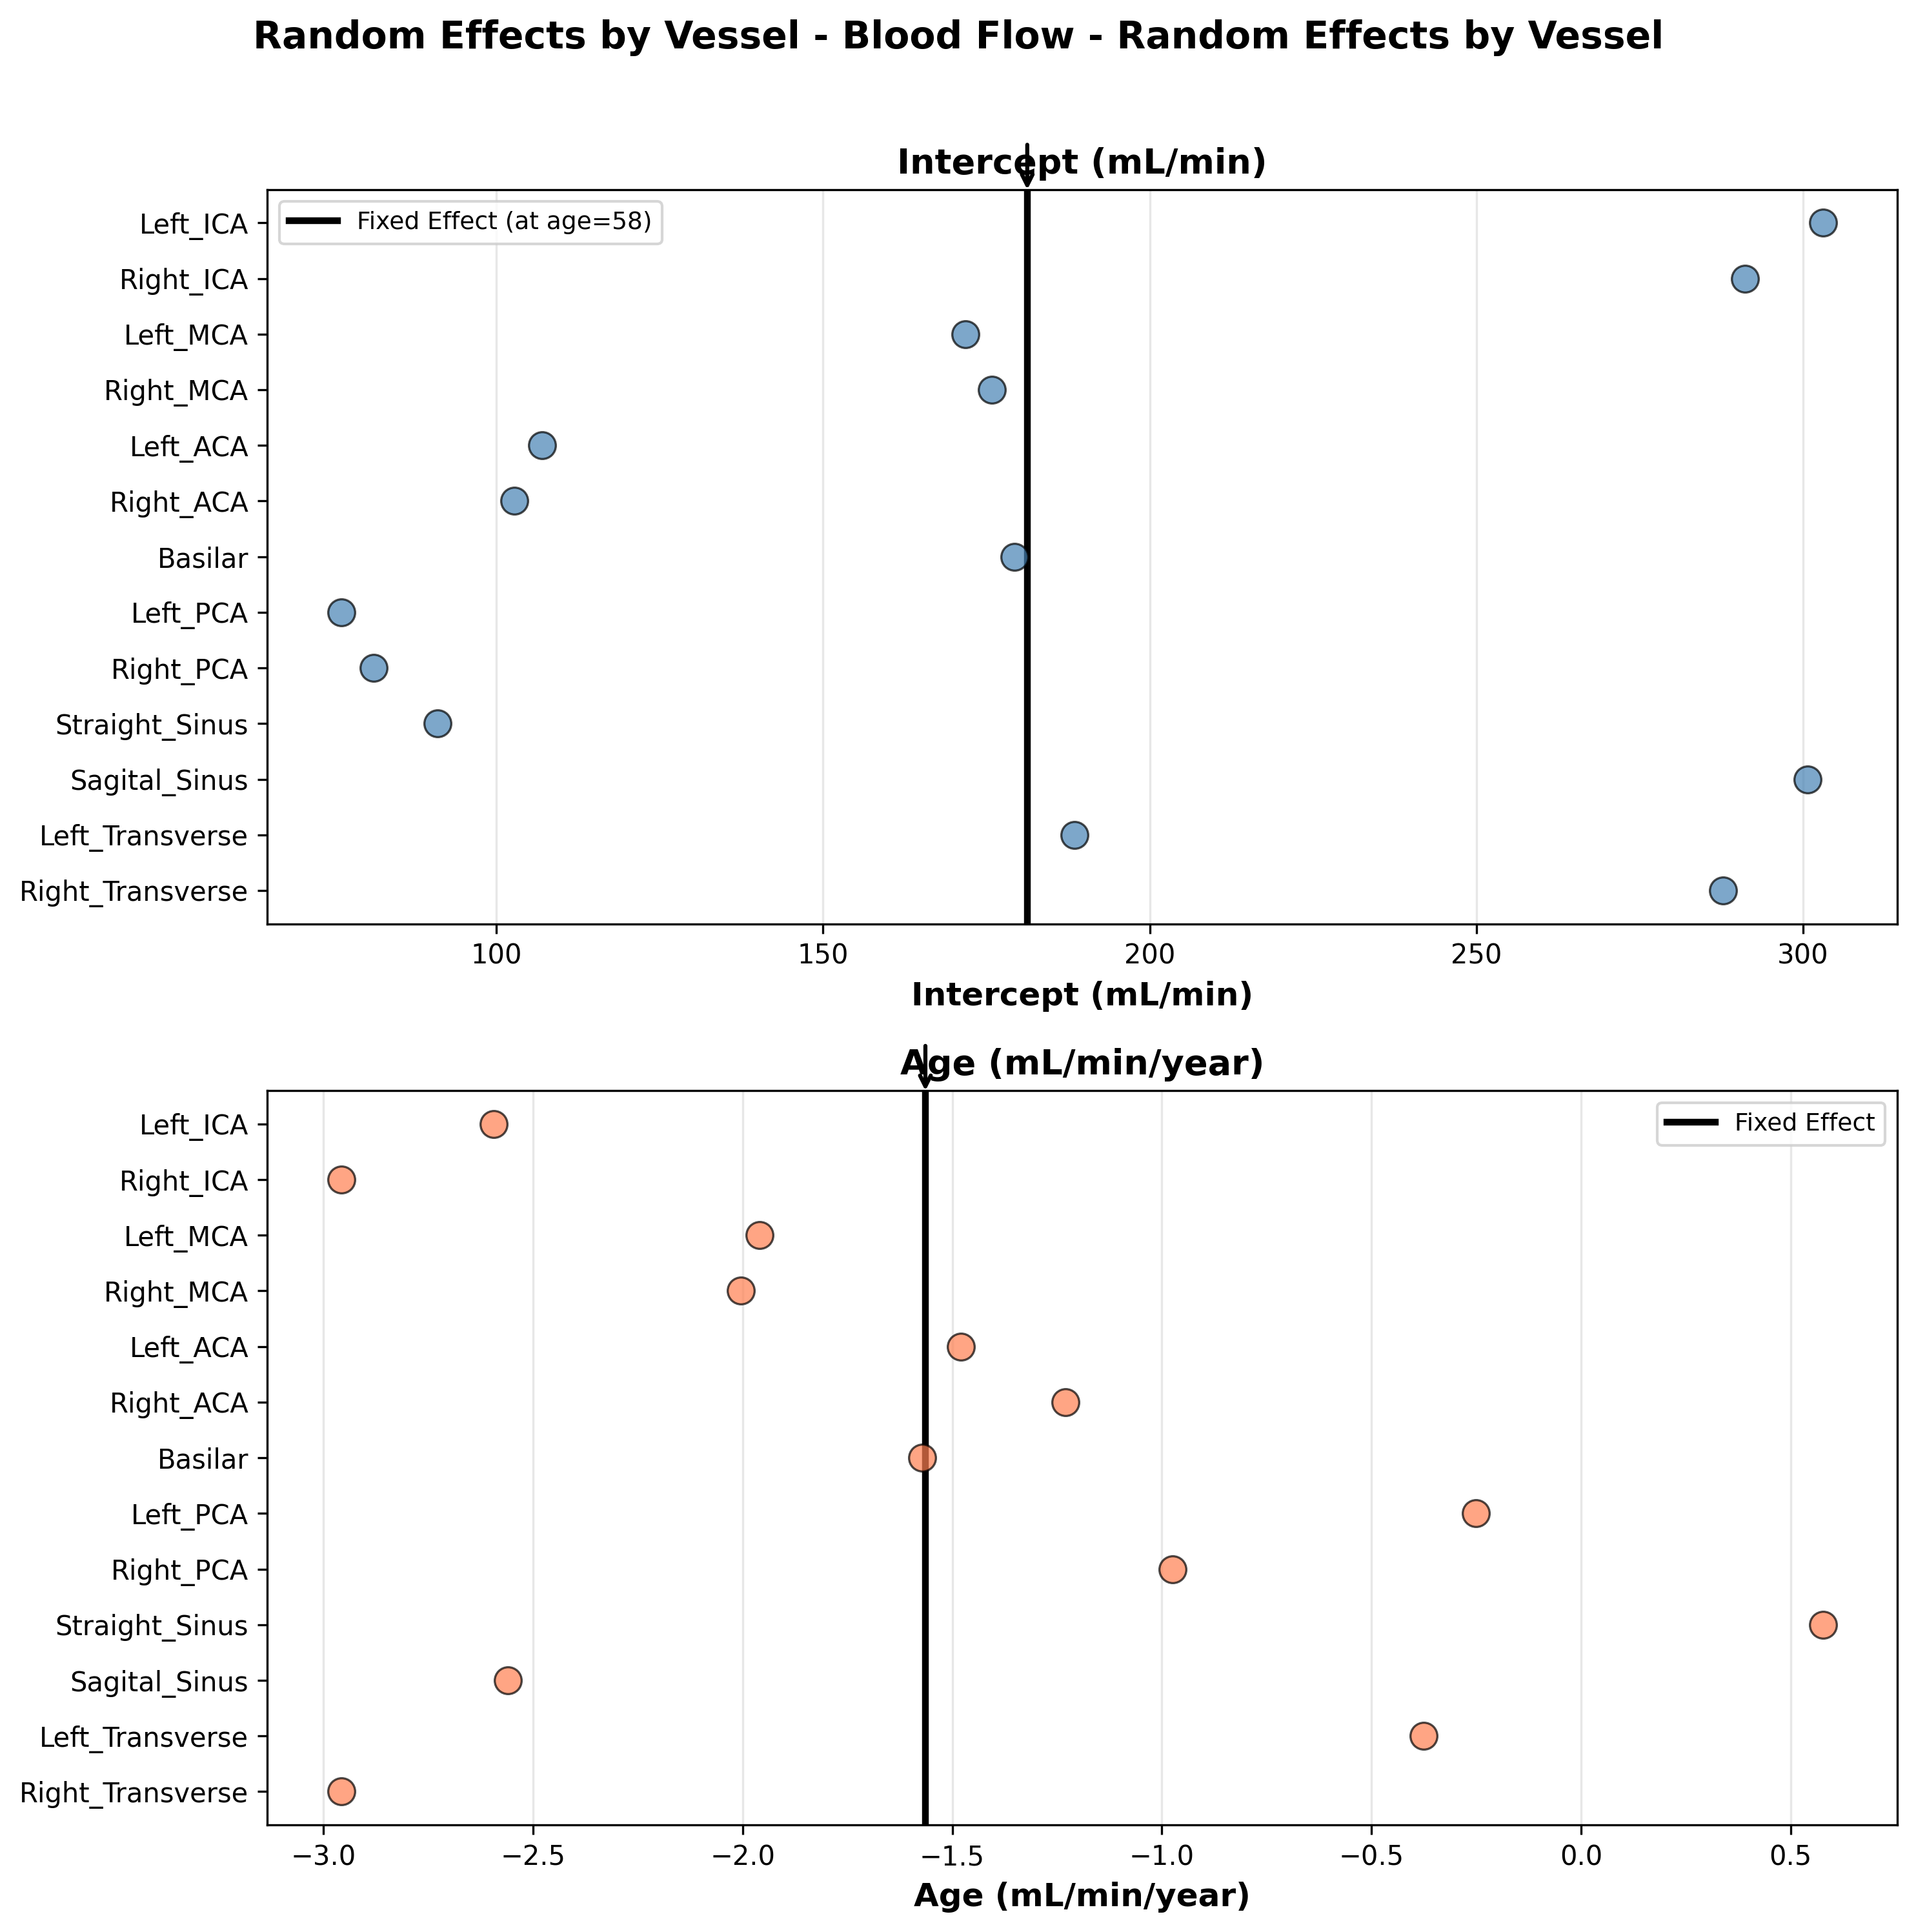

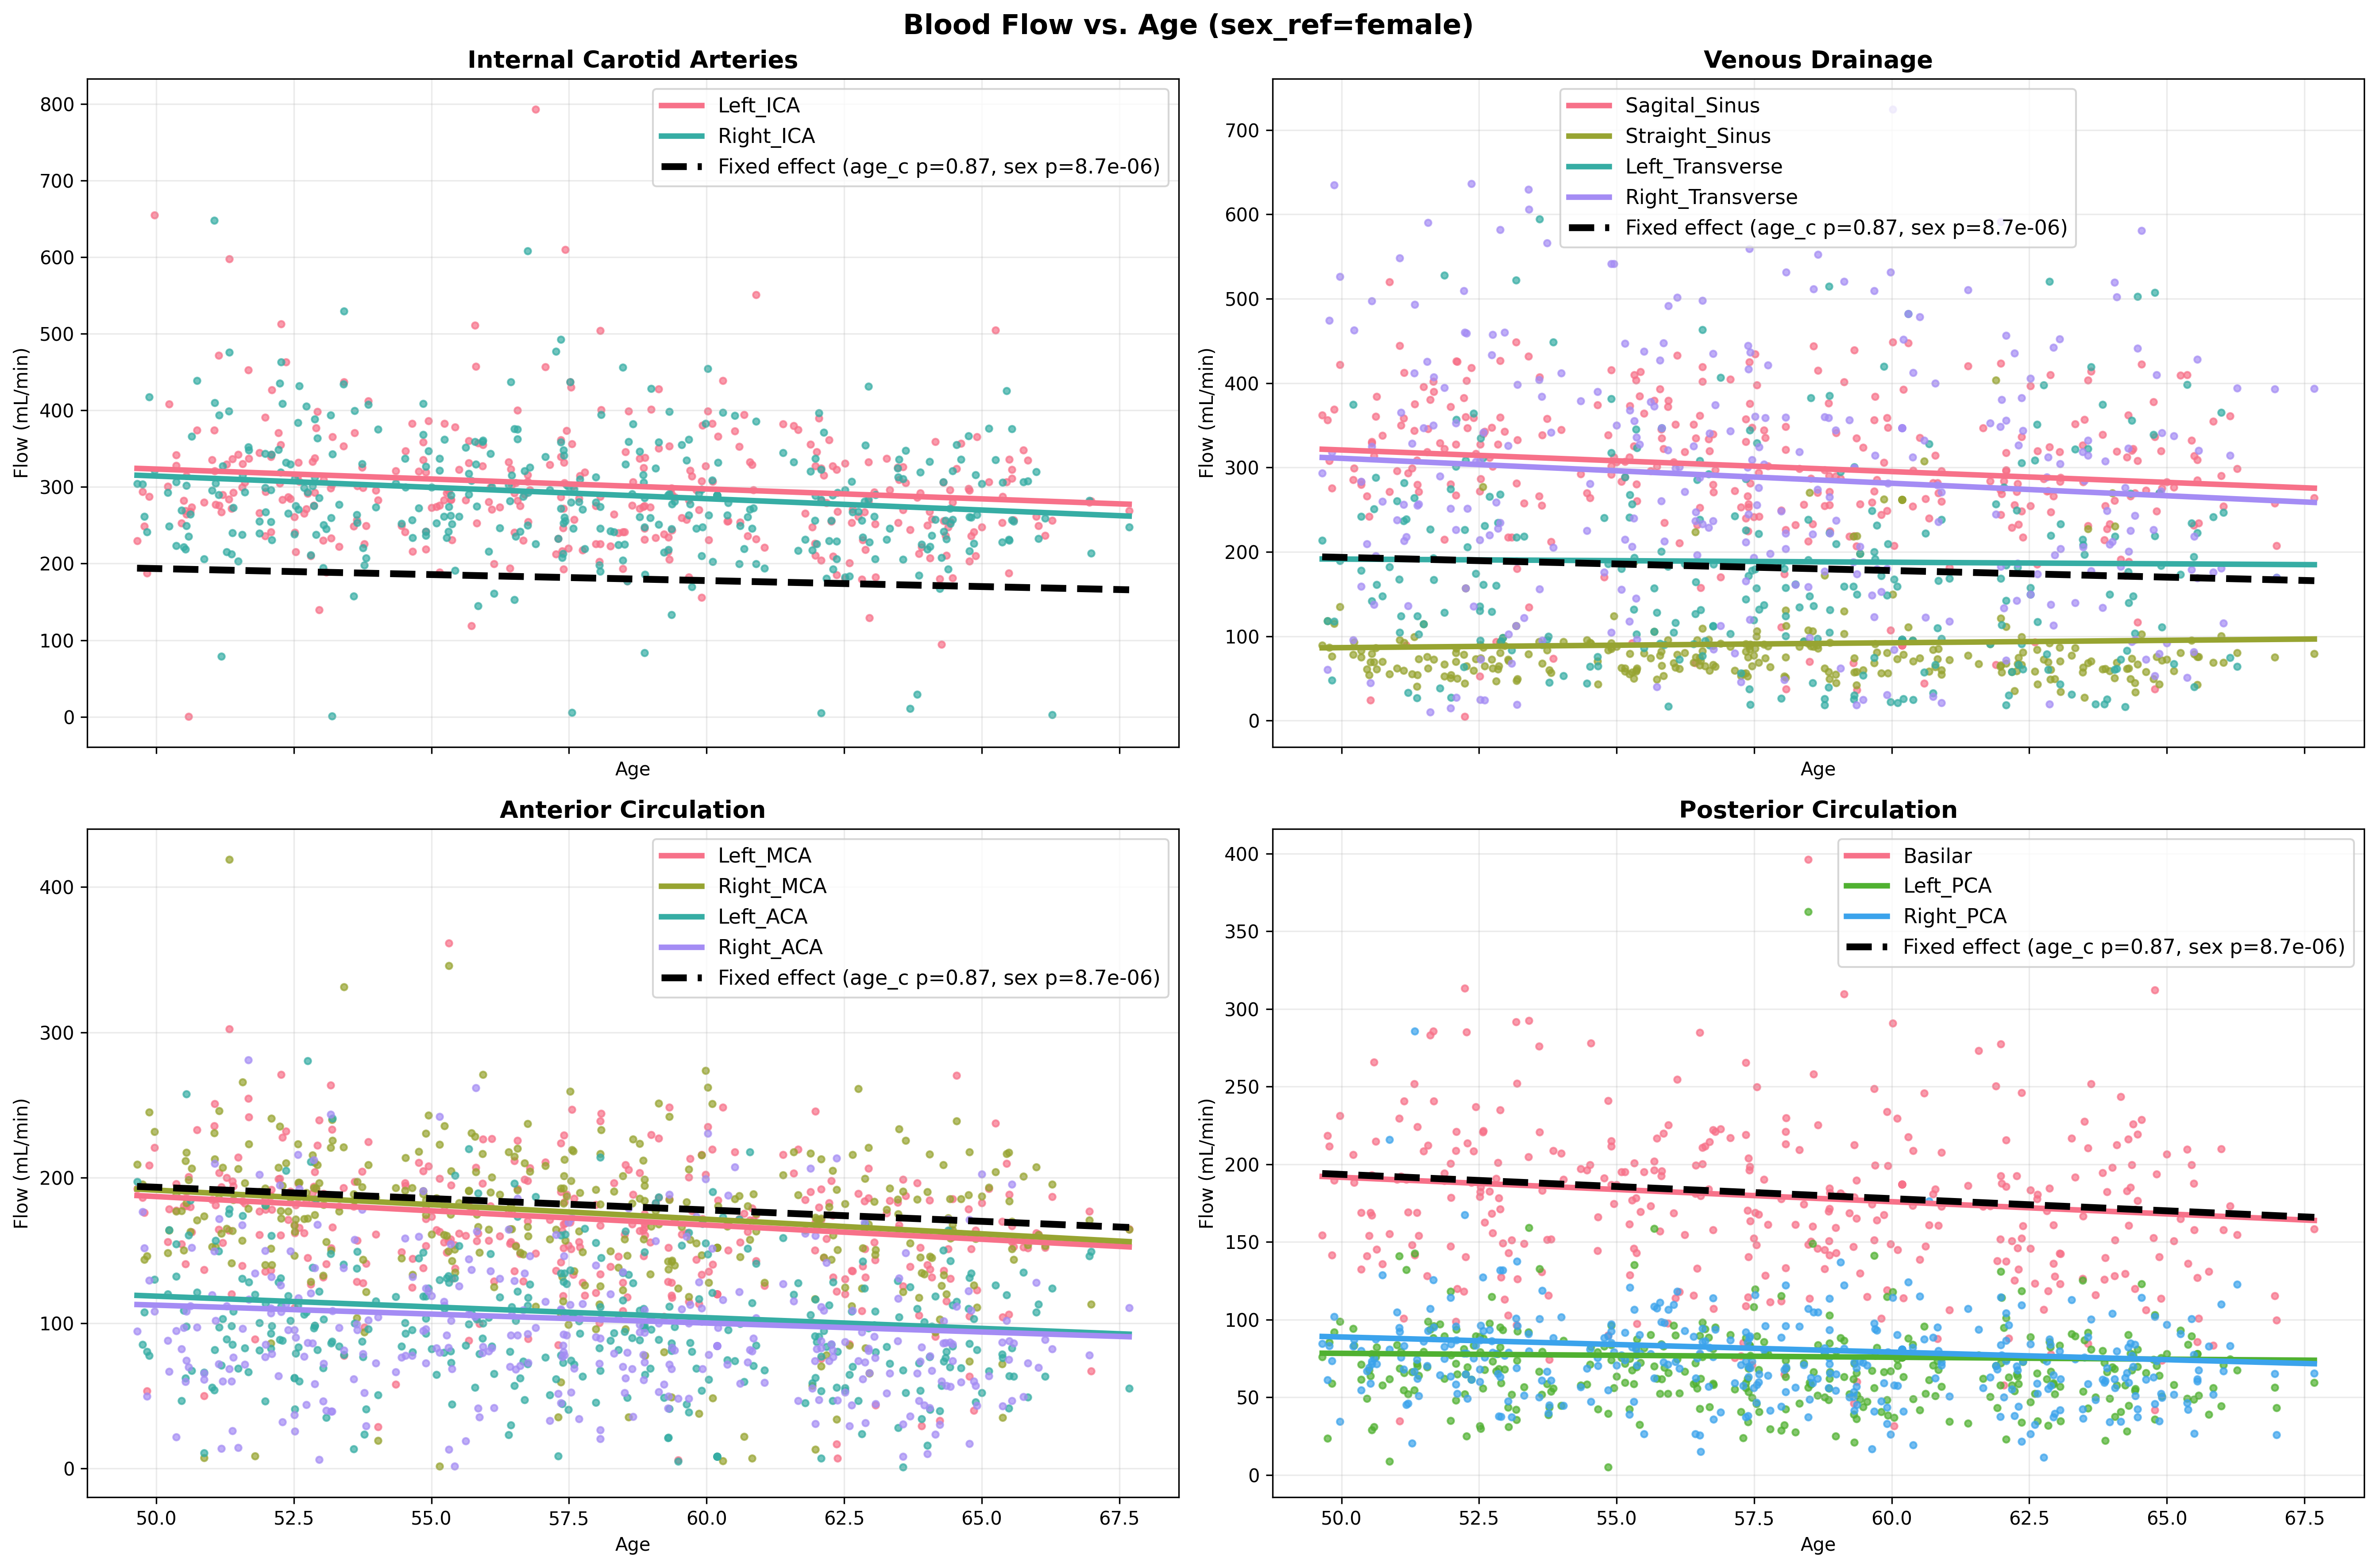

In [12]:

# Create random effects plot (first plot section)
plot_paper_random_effects_by_vessel(
    df_fit=flow_fit,
    res=flow_res,
    output_path=OUTPUT_DIR / "flow" / "paper_mixedlm" / "random_effects_by_vessel_flow.png",
    title="Random Effects by Vessel - Blood Flow",
    y_label="mL/min",
    group_name="vessel",
    sex_ref="female"
)

# Create conditional fits plot (second plot section - you already have this)
plot_paper_conditional_fits_by_group(
    df_fit=flow_fit,
    res=flow_res,
    output_path=OUTPUT_DIR / "flow" / "paper_mixedlm" / "conditional_fits_by_group_flow.png",
    title="Blood Flow vs. Age",
    y_label="Flow (mL/min)",
    sex_ref="female",
)

# Display an example
from IPython.display import Image, display
out_path = OUTPUT_DIR / "flow" / "paper_mixedlm" / "random_effects_by_vessel_flow.png"
if out_path.exists():
    display(Image(str(out_path)))
    
out_path = OUTPUT_DIR / "flow" / "paper_mixedlm" / "conditional_fits_by_group_flow.png"
if out_path.exists():
    display(Image(str(out_path)))

In [20]:
# PI (paper model is log(PI))
pi_long = build_long_vessel_df(clinical_df, pi_table, outcome_label="PI", exclude_vessels=EXCLUDE_FOR_MIXEDLM)
print("PI long df:", pi_long.shape, "subjects:", pi_long['patient_id'].nunique(), "vessels:", pi_long['vessel'].nunique())


PI long df: (4343, 7) subjects: 356 vessels: 13


In [19]:
# pi_res, pi_fit = _fit_paper_mixedlm(pi_long, outcome="pi_log")

pi_model_path = models_path / 'pi_mm.pkl'
if pi_model_path.exists():
    pi_res, pi_fit = _load_paper_mixedlm(pi_model_path, outcome="pi_log", long_df=pi_long)
else:
    pi_res, pi_fit = _fit_paper_mixedlm(pi_long, outcome="pi_log", model_path=pi_model_path)


NameError: name 'models_path' is not defined

In [13]:

print_mixedlm_summary(
    pi_res,
    outcome_name="log(PI)",
    formula="log(PI) ~ 1 + age + sex + (1 + age | vessel) + (1 | participant)"
)

plot_paper_random_effects_by_vessel(
    df_fit=pi_fit,
    res=pi_res,
    output_path=OUTPUT_DIR / "pi" / "paper_mixedlm" / "random_effects_by_vessel_pi.png",
    title="Random Effects by Vessel - Blood log(PI)",
    y_label="log(PI)",
    group_name="vessel",
    sex_ref="female"
)

# Create conditional fits plot (second plot section - you already have this)
plot_paper_conditional_fits_by_group(
    df_fit=pi_fit,
    res=pi_res,
    output_path=OUTPUT_DIR / "pi" / "paper_mixedlm" / "conditional_fits_by_group_pi.png",
    title="log(PI) vs. Age",
    y_label="log(PI)",
    sex_ref="female",
)

# Display an example
from IPython.display import Image, display
out_path = OUTPUT_DIR / "pi" / "paper_mixedlm" / "random_effects_by_vessel_pi.png"
if out_path.exists():
    display(Image(str(out_path)))
    
out_path = OUTPUT_DIR / "pi" / "paper_mixedlm" / "conditional_fits_by_group_pi.png"
if out_path.exists():
    display(Image(str(out_path)))

NameError: name 'pi_res' is not defined

## Step 13: Mixed-Effects Model Extensions (Exploration, v3)

We extend the paper-faithful mixed-effects models by adding participant-level clinical covariates to test **macrovasculature vs microvasculature** coupling and **macrovasculature vs carotid plaque** associations.

We fit 4 models (same random-effects structure as Step 12):

- Flow ~ 1 + age + sex + **ASL perfusion** + (1 + age | vessel) + (1 | participant)
- log(PI) ~ 1 + age + sex + **ASL perfusion** + (1 + age | vessel) + (1 | participant)
- Flow ~ 1 + age + sex + **plaque (presence + volume)** + (1 + age | vessel) + (1 | participant)
- log(PI) ~ 1 + age + sex + **plaque (presence + volume)** + (1 + age | vessel) + (1 | participant)

Notes:
- We use `age_c` (centered age) in the actual statsmodels formula (as in Step 12).
- For side-specific covariates we create `asl_side` and `plaque_side` based on whether the vessel name starts with `Left_` or `Right_` (midline vessels fall back to whole-brain ASL / total plaque).


In [ ]:
# Step 13 (v3): ASL perfusion & carotid plaque mixed models (Flow + PI)
#
# Implements the requested model families.
# For each model we:
# - prepare predictors (ASL/plaque; global and hemisphere/ipsilateral variants)
# - fit MixedLM (vessel random effects + participant intercept via variance components)
# - print a compact summary + brief interpretation
# - save plots:
#   - random effects by vessel (intercepts + slopes)
#   - conditional fits by group (predicted y vs predictor, with scatter)

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.tools.sm_exceptions import ConvergenceWarning


# -------------------------
# Predictor preparation
# -------------------------

CLIN_COVS = [
    "ctx_whole_brain",
    "ctx_left_hemisphere",
    "ctx_right_hemisphere",
    "plaque_left_carotid",
    "plaque_right_carotid",
]


def _vessel_side(v: str) -> str:
    v = str(v)
    if v.startswith("Left_"):
        return "left"
    if v.startswith("Right_"):
        return "right"
    return "midline"


def _add_covariates_from_clinical(long_df: pd.DataFrame, clinical_df_in: pd.DataFrame, covariates: list[str]) -> pd.DataFrame:
    """Merge extra clinical covariates onto an existing long vessel df."""
    c = clinical_df_in.copy()
    c.columns = [_safe_col(x) for x in c.columns]

    covariates_safe = [_safe_col(x) for x in covariates]
    missing = [cv for cv in covariates_safe if cv not in set(c.columns)]
    if missing:
        raise ValueError(f"clinical_df is missing required covariates: {missing}")

    cols = ["patient_id"] + covariates_safe
    return long_df.merge(c[cols].copy(), on="patient_id", how="left")


def _prep_asl_plaque(df: pd.DataFrame) -> pd.DataFrame:
    """Create intuitive predictors for ASL and plaque."""
    out = df.copy()
    out["side"] = out["vessel"].map(_vessel_side)

    # --- ASL
    out["asl_global"] = pd.to_numeric(out["ctx_whole_brain"], errors="coerce")

    ctx_left = pd.to_numeric(out["ctx_left_hemisphere"], errors="coerce")
    ctx_right = pd.to_numeric(out["ctx_right_hemisphere"], errors="coerce")

    # Strict ipsilateral hemisphere perfusion: left/right only (midline excluded)
    out["asl_hemi"] = np.where(out["side"].eq("left"), ctx_left, np.where(out["side"].eq("right"), ctx_right, np.nan))

    # --- Plaque volumes
    plaque_left = pd.to_numeric(out["plaque_left_carotid"], errors="coerce").clip(lower=0)
    plaque_right = pd.to_numeric(out["plaque_right_carotid"], errors="coerce").clip(lower=0)

    # Side-matched with midline fallback to total burden (L+R)
    out["plaque_vol_side"] = np.where(
        out["side"].eq("left"),
        plaque_left,
        np.where(out["side"].eq("right"), plaque_right, plaque_left + plaque_right),
    )

    # Strict ipsilateral plaque (midline excluded)
    out["plaque_vol_hemi"] = np.where(out["side"].eq("left"), plaque_left, np.where(out["side"].eq("right"), plaque_right, np.nan))

    # Two-part encodings: presence + log1p(volume)*presence
    out["plaque_any_side"] = (pd.to_numeric(out["plaque_vol_side"], errors="coerce") > 0).astype(int)
    out["plaque_logx_any_side"] = np.log1p(pd.to_numeric(out["plaque_vol_side"], errors="coerce").astype(float)) * out["plaque_any_side"].astype(float)

    out["plaque_any_hemi"] = (pd.to_numeric(out["plaque_vol_hemi"], errors="coerce") > 0).astype("float")
    out.loc[pd.to_numeric(out["plaque_vol_hemi"], errors="coerce").isna(), "plaque_any_hemi"] = np.nan
    out["plaque_logx_any_hemi"] = np.where(
        pd.to_numeric(out["plaque_vol_hemi"], errors="coerce").isna(),
        np.nan,
        np.log1p(pd.to_numeric(out["plaque_vol_hemi"], errors="coerce").astype(float)) * (pd.to_numeric(out["plaque_vol_hemi"], errors="coerce") > 0).astype(float),
    )

    return out


flow_ext = _prep_asl_plaque(_add_covariates_from_clinical(flow_long, clinical_df, CLIN_COVS))
pi_ext = _prep_asl_plaque(_add_covariates_from_clinical(pi_long, clinical_df, CLIN_COVS))


# -------------------------
# Model fitting + summaries
# -------------------------

def _fit_mixedlm(
    df_long: pd.DataFrame,
    *,
    outcome: str,
    fixed_formula: str,
    re_formula: str,
    vc_formula: dict[str, str],
    required_cols: list[str],
):
    df = df_long.copy().reset_index(drop=True)

    if outcome.lower() == "flow":
        df["y"] = pd.to_numeric(df["value"], errors="coerce")
        y_label = "Flow (mL/min)"
    elif outcome.lower() in {"pi", "pi_log", "log_pi"}:
        v = pd.to_numeric(df["value"], errors="coerce")
        df = df.assign(value=v).dropna(subset=["value"]).copy()
        df = df[df["value"] > 0].copy()
        df["y"] = np.log(df["value"].astype(float))
        y_label = "log(PI)"
    else:
        raise ValueError("outcome must be 'flow' or 'pi_log'")

    base_required = ["patient_id", "vessel", "age", "age_c", "sex", "y"]
    df = df.dropna(subset=base_required + list(required_cols)).reset_index(drop=True)

    # stable vessel categories
    vessels = sorted(df["vessel"].unique())
    df["vessel"] = pd.Categorical(df["vessel"], categories=vessels)

    model = MixedLM.from_formula(
        fixed_formula,
        groups=df["vessel"],
        re_formula=re_formula,
        vc_formula=vc_formula,
        data=df,
    )

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
        warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")
        warnings.filterwarnings("ignore", category=ConvergenceWarning, module="statsmodels")
        res = model.fit(reml=True, method="lbfgs", maxiter=1200, disp=False)

    return res, df, y_label


def print_mixedlm_summary_compact(
    res,
    *,
    title: str,
    pretty_formula: str,
    interpretation: str,
    df_fit: pd.DataFrame,
):
    print("\n" + "=" * 110)
    print(title)
    print(pretty_formula)
    print("-" * 110)
    print("Interpretation:")
    print(f"  {interpretation}")
    print("-" * 110)

    print(
        f"N rows: {len(df_fit):,} | participants: {df_fit['patient_id'].nunique():,} | vessels: {df_fit['vessel'].nunique():,}"
    )

    fe = getattr(res, "fe_params", None)
    bse = getattr(res, "bse_fe", None)
    pvals = getattr(res, "pvalues", None)

    if fe is not None:
        print("\nFixed effects:")
        print(f"{'term':<35} {'coef':>12} {'se':>12} {'p':>12}")
        print("-" * 75)
        for term in fe.index:
            coef = float(fe[term])
            se = float(bse[term]) if isinstance(bse, pd.Series) and term in bse.index else float("nan")
            p = float(pvals[term]) if isinstance(pvals, pd.Series) and term in pvals.index else float("nan")
            p_str = f"{p:.3g}" if np.isfinite(p) else "NA"
            print(f"{term:<35} {coef:>12.5f} {se:>12.5f} {p_str:>12}")

    if hasattr(res, "cov_re") and res.cov_re is not None:
        print("\nRandom effects (vessel) cov_re:")
        try:
            print(pd.DataFrame(res.cov_re))
        except Exception:
            print(res.cov_re)

    if hasattr(res, "vcomp"):
        try:
            print("\nVariance components (vcomp):", np.asarray(res.vcomp))
        except Exception:
            pass

    print("\nFit:")
    print(
        f"  converged: {getattr(res, 'converged', 'NA')} | llf: {getattr(res, 'llf', float('nan')):.3f} | aic: {getattr(res, 'aic', float('nan')):.3f} | bic: {getattr(res, 'bic', float('nan')):.3f}"
    )


# -------------------------
# Plotting
# -------------------------

def _sex_ref_value(df_fit: pd.DataFrame, sex_ref: str) -> float:
    if sex_ref == "mean":
        return float(pd.to_numeric(df_fit["sex"], errors="coerce").mean())
    if sex_ref == "female":
        return 0.0
    if sex_ref == "male":
        return 1.0
    raise ValueError("sex_ref must be one of: mean, female, male")


def _extract_vessel_re(res, vessel: str) -> pd.Series:
    re = res.random_effects.get(vessel, None)
    if re is None and isinstance(vessel, str):
        re = res.random_effects.get(str(vessel), None)
    if re is None:
        return pd.Series(dtype=float)
    if isinstance(re, pd.Series):
        return re
    return pd.Series(np.asarray(re).ravel())


def _get_re(re_s: pd.Series, key: str, default: float = 0.0) -> float:
    if key in re_s.index:
        try:
            return float(re_s[key])
        except Exception:
            return default
    return default


def _find_vc_slope(re_s: pd.Series, vc_prefix: str, vessel: str) -> float:
    for k in re_s.index:
        ks = str(k)
        if ks.startswith(vc_prefix + "[") and f"C(vessel)[{vessel}]" in ks:
            try:
                return float(re_s[k])
            except Exception:
                return 0.0
    return 0.0


def plot_random_effects_by_vessel(
    *,
    df_fit: pd.DataFrame,
    res,
    output_path: Path,
    title: str,
    terms: list[tuple[str, str]],
):
    """terms entries are (label, kind) where kind in {'re:TERM', 'vc:PREFIX'}"""

    output_path.parent.mkdir(parents=True, exist_ok=True)

    vessels = sorted(df_fit["vessel"].unique())
    y_pos = np.arange(len(vessels))

    values: dict[str, list[float]] = {label: [] for label, _ in terms}

    for v in vessels:
        re_s = _extract_vessel_re(res, str(v))
        for label, kind in terms:
            if kind.startswith("re:"):
                key = kind.split(":", 1)[1]
                values[label].append(_get_re(re_s, key, 0.0))
            elif kind.startswith("vc:"):
                prefix = kind.split(":", 1)[1]
                values[label].append(_find_vc_slope(re_s, prefix, str(v)))
            else:
                values[label].append(0.0)

    n_terms = len(terms)
    fig, axes = plt.subplots(1, n_terms, figsize=(6 * n_terms, max(8, 0.35 * len(vessels))), sharey=True)
    if n_terms == 1:
        axes = [axes]

    for ax, (label, _) in zip(axes, terms):
        ax.scatter(values[label], y_pos, s=55, alpha=0.85, edgecolors="black", linewidth=0.4)
        ax.axvline(0.0, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.set_title(label, fontweight="bold")
        ax.grid(True, axis="x", alpha=0.25)

    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels([str(v) for v in vessels], fontsize=10)
    axes[0].invert_yaxis()

    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_conditional_fits_by_group_continuous(
    *,
    df_fit: pd.DataFrame,
    res,
    x_col: str,
    output_path: Path,
    title: str,
    x_label: str,
    y_label: str,
    sex_ref: str = "female",
    age_c_ref: float = 0.0,
    x_vc_prefix: str | None = None,
):
    output_path.parent.mkdir(parents=True, exist_ok=True)

    d = df_fit.copy()
    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d = d.dropna(subset=[x_col, "y", "vessel", "sex", "age_c"]).copy()

    sex_val = _sex_ref_value(d, sex_ref)

    x = d[x_col].to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    x_line = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), 200)

    fe = res.fe_params
    b0 = float(fe.get("Intercept", fe.get("const", 0.0)))
    b_age = float(fe.get("age_c", 0.0))
    b_sex = float(fe.get("sex", 0.0))
    b_x = float(fe.get(x_col, 0.0))

    y_fixed = b0 + b_age * age_c_ref + b_sex * sex_val + b_x * x_line

    vessels_all = sorted(d["vessel"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, (group_name, vessels) in zip(axes, VESSEL_GROUPS_ORDER.items()):
        vessels_present = [v for v in vessels if v in set(vessels_all)]
        if not vessels_present:
            ax.axis("off")
            continue

        palette = sns.color_palette("husl", n_colors=len(vessels_present))

        for i, v in enumerate(vessels_present):
            sub = d[d["vessel"] == v]
            ax.scatter(sub[x_col], sub["y"], s=12, alpha=0.65, color=palette[i])

            re_s = _extract_vessel_re(res, str(v))
            re_int = _get_re(re_s, "Group", default=_get_re(re_s, "Intercept", 0.0))
            re_age = _get_re(re_s, "age_c", 0.0)

            if x_vc_prefix is not None:
                re_x = _find_vc_slope(re_s, x_vc_prefix, str(v))
            else:
                re_x = _get_re(re_s, x_col, 0.0)

            y_v = (b0 + re_int) + (b_age + re_age) * age_c_ref + b_sex * sex_val + (b_x + re_x) * x_line
            ax.plot(x_line, y_v, color=palette[i], linewidth=3, alpha=1, label=str(v))

        ax.plot(x_line, y_fixed, color="black", linewidth=3.6, linestyle="--", label="Fixed effect")
        ax.set_title(group_name, fontsize=13, fontweight="bold")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=10)

    fig.suptitle(f"{title} (sex_ref={sex_ref}, age_c={age_c_ref})", fontsize=15, fontweight="bold")
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_conditional_fits_by_group_plaque_two_part(
    *,
    df_fit: pd.DataFrame,
    res,
    plaque_vol_col: str,
    plaque_any_col: str,
    plaque_logx_any_col: str,
    output_path: Path,
    title: str,
    y_label: str,
    sex_ref: str = "female",
    age_c_ref: float = 0.0,
):
    output_path.parent.mkdir(parents=True, exist_ok=True)

    d = df_fit.copy()
    d[plaque_vol_col] = pd.to_numeric(d[plaque_vol_col], errors="coerce")
    d = d.dropna(subset=[plaque_vol_col, "y", "vessel", "sex", "age_c", plaque_any_col, plaque_logx_any_col]).copy()

    sex_val = _sex_ref_value(d, sex_ref)

    x = d[plaque_vol_col].to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    x_line = np.linspace(0.0, float(np.nanmax(x)), 200)
    logx_line = np.log1p(x_line)

    fe = res.fe_params
    b0 = float(fe.get("Intercept", fe.get("const", 0.0)))
    b_age = float(fe.get("age_c", 0.0))
    b_sex = float(fe.get("sex", 0.0))
    b_any = float(fe.get(plaque_any_col, 0.0))
    b_logx = float(fe.get(plaque_logx_any_col, 0.0))

    y_fixed0 = np.full_like(x_line, b0 + b_age * age_c_ref + b_sex * sex_val, dtype=float)
    y_fixed1 = (b0 + b_any) + b_age * age_c_ref + b_sex * sex_val + b_logx * logx_line

    vessels_all = sorted(d["vessel"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, (group_name, vessels) in zip(axes, VESSEL_GROUPS_ORDER.items()):
        vessels_present = [v for v in vessels if v in set(vessels_all)]
        if not vessels_present:
            ax.axis("off")
            continue

        palette = sns.color_palette("husl", n_colors=len(vessels_present))

        for i, v in enumerate(vessels_present):
            sub = d[d["vessel"] == v]
            ax.scatter(sub[plaque_vol_col], sub["y"], s=12, alpha=0.65, color=palette[i])

            re_s = _extract_vessel_re(res, str(v))
            re_int = _get_re(re_s, "Group", default=_get_re(re_s, "Intercept", 0.0))
            re_age = _get_re(re_s, "age_c", 0.0)
            re_any = _get_re(re_s, plaque_any_col, 0.0)
            re_logx = _get_re(re_s, plaque_logx_any_col, 0.0)

            y_v0 = np.full_like(x_line, (b0 + re_int) + (b_age + re_age) * age_c_ref + b_sex * sex_val, dtype=float)
            y_v1 = ((b0 + re_int) + (b_any + re_any)) + (b_age + re_age) * age_c_ref + b_sex * sex_val + (b_logx + re_logx) * logx_line

            ax.plot(x_line, y_v1, color=palette[i], linewidth=3, alpha=1, label=str(v))
            ax.plot(x_line, y_v0, color=palette[i], linewidth=2, alpha=0.35, linestyle=":")

        ax.plot(x_line, y_fixed1, color="black", linewidth=3.6, linestyle="--", label="Fixed any=1")
        ax.plot(x_line, y_fixed0, color="black", linewidth=2.2, linestyle=":", label="Fixed any=0")
        ax.set_title(group_name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Plaque volume (mm³)")
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=10)

    fig.suptitle(f"{title} (sex_ref={sex_ref}, age_c={age_c_ref})", fontsize=15, fontweight="bold")
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


# -------------------------
# Requested model set (Flow + PI equivalents)
# -------------------------

@dataclass
class ModelSpec:
    name: str
    family: str
    pretty_flow: str
    pretty_pi: str
    fixed_formula: str
    re_formula: str
    vc_formula: dict[str, str]
    required_cols: list[str]
    interpretation: str
    kind: str  # 'cont' or 'plaque'
    x_col: str | None = None
    x_label: str | None = None
    x_vc_prefix: str | None = None
    plaque_vol_col: str | None = None
    plaque_any_col: str | None = None
    plaque_logx_any_col: str | None = None
    re_terms: list[tuple[str, str]] | None = None


VC_PARTICIPANT = {"participant": "0 + C(patient_id)"}

MODEL_SPECS: list[ModelSpec] = [
    # ASL Perfusion
    ModelSpec(
        name="asl_1_ctx_correlated",
        family="asl",
        pretty_flow="flow ~ 1 + ctx_whole_brain + (1 + age + ctx_whole_brain | vessel) + (1 | participant)",
        pretty_pi="log(PI) ~ 1 + ctx_whole_brain + (1 + age + ctx_whole_brain | vessel) + (1 | participant)",
        fixed_formula="y ~ 1 + ctx_whole_brain",
        re_formula="1 + age_c + ctx_whole_brain",
        vc_formula=VC_PARTICIPANT,
        required_cols=["ctx_whole_brain"],
        interpretation="Global ASL↔outcome association; vessel baseline, age slope, and ASL slope vary and are correlated within vessel.",
        kind="cont",
        x_col="ctx_whole_brain",
        x_label="ASL perfusion (ctx_whole_brain)",
        re_terms=[("Intercept", "re:Group"), ("Age slope", "re:age_c"), ("ASL slope", "re:ctx_whole_brain")],
    ),
    ModelSpec(
        name="asl_2_ctx_split",
        family="asl",
        pretty_flow="flow ~ 1 + ctx_whole_brain + age + sex + (1 + age | vessel) + (0 + ctx_whole_brain | vessel) + (1 | participant)",
        pretty_pi="log(PI) ~ 1 + ctx_whole_brain + age + sex + (1 + age | vessel) + (0 + ctx_whole_brain | vessel) + (1 | participant)",
        fixed_formula="y ~ 1 + age_c + sex + ctx_whole_brain",
        re_formula="1 + age_c",
        vc_formula={
            "participant": "0 + C(patient_id)",
            "ctx_slope": "0 + ctx_whole_brain:C(vessel)",
        },
        required_cols=["ctx_whole_brain"],
        interpretation="Adjusts for age/sex; vessel baseline and age slope vary; ASL slope varies by vessel as an independent random term.",
        kind="cont",
        x_col="ctx_whole_brain",
        x_label="ASL perfusion (ctx_whole_brain)",
        x_vc_prefix="ctx_slope",
        re_terms=[("Intercept", "re:Group"), ("Age slope", "re:age_c"), ("ASL slope", "vc:ctx_slope")],
    ),
    ModelSpec(
        name="asl_3_hemi_split",
        family="asl",
        pretty_flow="flow ~ 1 + age + sex + asl_hemi + (1 + age | vessel) + (0 + asl_hemi | vessel) + (1 | participant)",
        pretty_pi="log(PI) ~ 1 + age + sex + asl_hemi + (1 + age | vessel) + (0 + asl_hemi | vessel) + (1 | participant)",
        fixed_formula="y ~ 1 + age_c + sex + asl_hemi",
        re_formula="1 + age_c",
        vc_formula={
            "participant": "0 + C(patient_id)",
            "asl_slope": "0 + asl_hemi:C(vessel)",
        },
        required_cols=["asl_hemi"],
        interpretation="Ipsilateral hemisphere coupling (midline excluded): adjusts for age/sex; vessel baseline and age slope vary; ASL-hemi slope varies by vessel independently.",
        kind="cont",
        x_col="asl_hemi",
        x_label="ASL perfusion (ipsilateral hemisphere)",
        x_vc_prefix="asl_slope",
        re_terms=[("Intercept", "re:Group"), ("Age slope", "re:age_c"), ("ASL-hemi slope", "vc:asl_slope")],
    ),
    ModelSpec(
        name="asl_4_hemi_correlated",
        family="asl",
        pretty_flow="flow ~ 1 + age + sex + asl_hemi + (1 + age + asl_hemi | vessel) + (1 | participant)",
        pretty_pi="log(PI) ~ 1 + age + sex + asl_hemi + (1 + age + asl_hemi | vessel) + (1 | participant)",
        fixed_formula="y ~ 1 + age_c + sex + asl_hemi",
        re_formula="1 + age_c + asl_hemi",
        vc_formula=VC_PARTICIPANT,
        required_cols=["asl_hemi"],
        interpretation="Ipsilateral hemisphere coupling (midline excluded): adjusts for age/sex; vessel baseline, age slope, and ASL-hemi slope vary and are correlated within vessel.",
        kind="cont",
        x_col="asl_hemi",
        x_label="ASL perfusion (ipsilateral hemisphere)",
        re_terms=[("Intercept", "re:Group"), ("Age slope", "re:age_c"), ("ASL-hemi slope", "re:asl_hemi")],
    ),

    # Plaque (side-matched: midline uses total)
    ModelSpec(
        name="plaque_side_1_basic",
        family="plaque",
        pretty_flow="flow ~ 1 + age + sex + plaque_any + log1p(plaque_vol):plaque_any + (1 + age | vessel) + (1 | participant)",
        pretty_pi="log(PI) ~ 1 + age + sex + plaque_any + log1p(plaque_vol):plaque_any + (1 + age | vessel) + (1 | participant)",
        fixed_formula="y ~ 1 + age_c + sex + plaque_any_side + plaque_logx_any_side",
        re_formula="1 + age_c",
        vc_formula=VC_PARTICIPANT,
        required_cols=["plaque_any_side", "plaque_logx_any_side", "plaque_vol_side"],
        interpretation="Two-part plaque effect: plaque_any is any-plaque vs none; plaque_logx_any is dose-response among plaque>0; vessel baseline and age slope vary.",
        kind="plaque",
        plaque_vol_col="plaque_vol_side",
        plaque_any_col="plaque_any_side",
        plaque_logx_any_col="plaque_logx_any_side",
        re_terms=[("Intercept", "re:Group"), ("Age slope", "re:age_c")],
    ),
    ModelSpec(
        name="plaque_side_2_varying",
        family="plaque",
        pretty_flow="flow ~ 1 + age + sex + plaque_any + log1p(plaque_vol):plaque_any + (1 + age + plaque_any + log1p(plaque_vol):plaque_any | vessel) + (1 | participant)",
        pretty_pi="log(PI) ~ 1 + age + sex + plaque_any + log1p(plaque_vol):plaque_any + (1 + age + plaque_any + log1p(plaque_vol):plaque_any | vessel) + (1 | participant)",
        fixed_formula="y ~ 1 + age_c + sex + plaque_any_side + plaque_logx_any_side",
        re_formula="1 + age_c + plaque_any_side + plaque_logx_any_side",
        vc_formula=VC_PARTICIPANT,
        required_cols=["plaque_any_side", "plaque_logx_any_side", "plaque_vol_side"],
        interpretation="Two-part plaque model allowing vessel-specific plaque presence and dose slopes (correlated within vessel).",
        kind="plaque",
        plaque_vol_col="plaque_vol_side",
        plaque_any_col="plaque_any_side",
        plaque_logx_any_col="plaque_logx_any_side",
        re_terms=[("Intercept", "re:Group"), ("Age slope", "re:age_c"), ("Plaque-any", "re:plaque_any_side"), ("Dose", "re:plaque_logx_any_side")],
    ),

    # Plaque hemisphere-aware (strict ipsilateral)
    ModelSpec(
        name="plaque_hemi_1_basic",
        family="plaque",
        pretty_flow="flow ~ 1 + age + sex + plaque_any + log1p(plaque_vol):plaque_any + (1 + age | vessel) + (1 | participant)  [R/L aware]",
        pretty_pi="log(PI) ~ 1 + age + sex + plaque_any + log1p(plaque_vol):plaque_any + (1 + age | vessel) + (1 | participant)  [R/L aware]",
        fixed_formula="y ~ 1 + age_c + sex + plaque_any_hemi + plaque_logx_any_hemi",
        re_formula="1 + age_c",
        vc_formula=VC_PARTICIPANT,
        required_cols=["plaque_any_hemi", "plaque_logx_any_hemi", "plaque_vol_hemi"],
        interpretation="R/L-aware plaque model (midline excluded): tests ipsilateral plaque presence and dose-response.",
        kind="plaque",
        plaque_vol_col="plaque_vol_hemi",
        plaque_any_col="plaque_any_hemi",
        plaque_logx_any_col="plaque_logx_any_hemi",
        re_terms=[("Intercept", "re:Group"), ("Age slope", "re:age_c")],
    ),
    ModelSpec(
        name="plaque_hemi_2_varying",
        family="plaque",
        pretty_flow="flow ~ 1 + age + sex + plaque_any + log1p(plaque_vol):plaque_any + (1 + age + plaque_any + log1p(plaque_vol):plaque_any | vessel) + (1 | participant)  [R/L aware]",
        pretty_pi="log(PI) ~ 1 + age + sex + plaque_any + log1p(plaque_vol):plaque_any + (1 + age + plaque_any + log1p(plaque_vol):plaque_any | vessel) + (1 | participant)  [R/L aware]",
        fixed_formula="y ~ 1 + age_c + sex + plaque_any_hemi + plaque_logx_any_hemi",
        re_formula="1 + age_c + plaque_any_hemi + plaque_logx_any_hemi",
        vc_formula=VC_PARTICIPANT,
        required_cols=["plaque_any_hemi", "plaque_logx_any_hemi", "plaque_vol_hemi"],
        interpretation="R/L-aware plaque model allowing vessel-specific plaque presence and dose slopes (correlated within vessel).",
        kind="plaque",
        plaque_vol_col="plaque_vol_hemi",
        plaque_any_col="plaque_any_hemi",
        plaque_logx_any_col="plaque_logx_any_hemi",
        re_terms=[("Intercept", "re:Group"), ("Age slope", "re:age_c"), ("Plaque-any", "re:plaque_any_hemi"), ("Dose", "re:plaque_logx_any_hemi")],
    ),
]


# -------------------------
# Fit + plot: Flow and PI equivalents
# -------------------------

PLOTS_DIR = OUTPUT_DIR / "mixedlm_extensions_v3"

results: dict[str, dict[str, Any]] = {}
overwrite = False

for spec in MODEL_SPECS:
    for outcome, df_src, pretty in [
        ("flow", flow_ext, spec.pretty_flow),
        ("pi_log", pi_ext, spec.pretty_pi),
    ]:
        model_path = PLOTS_DIR / outcome / spec.family / spec.name / "model.pkl"

        if model_path.exists() and not overwrite:
            res, df_fit, y_label = _fit_mixedlm(
                df_src,
                outcome=outcome,
                fixed_formula=spec.fixed_formula,
                re_formula=spec.re_formula,
                vc_formula=spec.vc_formula,
                required_cols=spec.required_cols,
                )
            # Save model
            res.save(model_path)
        else:
            # Load model
            res = MixedLM.load(model_path)
            df_fit = res.data
            y_label = res.y_label

        results[f"{spec.name}__{outcome}"] = {"res": res, "df_fit": df_fit, "y_label": y_label}


        print_mixedlm_summary_compact(
            res,
            title=f"[{outcome.upper()}] {spec.name}",
            pretty_formula=pretty,
            interpretation=spec.interpretation,
            df_fit=df_fit,
        )

        # Random effects plot
        if spec.re_terms is not None:
            plot_random_effects_by_vessel(
                df_fit=df_fit,
                res=res,
                output_path=PLOTS_DIR / outcome / spec.family / spec.name / "random_effects_by_vessel.png",
                title=f"{spec.name} | {outcome} | random effects by vessel",
                terms=spec.re_terms,
            )

        # Conditional fits plot
        if spec.kind == "cont":
            plot_conditional_fits_by_group_continuous(
                df_fit=df_fit,
                res=res,
                x_col=spec.x_col,
                output_path=PLOTS_DIR / outcome / spec.family / spec.name / "conditional_fits_by_group.png",
                title=f"{spec.name}: conditional fits vs {spec.x_col}",
                x_label=spec.x_label,
                y_label=y_label,
                sex_ref="female",
                age_c_ref=0.0,
                x_vc_prefix=spec.x_vc_prefix,
            )
        else:
            plot_conditional_fits_by_group_plaque_two_part(
                df_fit=df_fit,
                res=res,
                plaque_vol_col=spec.plaque_vol_col,
                plaque_any_col=spec.plaque_any_col,
                plaque_logx_any_col=spec.plaque_logx_any_col,
                output_path=PLOTS_DIR / outcome / spec.family / spec.name / "conditional_fits_by_group.png",
                title=f"{spec.name}: conditional fits vs plaque volume",
                y_label=y_label,
                sex_ref="female",
                age_c_ref=0.0,
            )

print(f"\n✓ Saved Step-13 plots under: {PLOTS_DIR}")

# Quick inline preview (Flow only)
from IPython.display import Image, display

preview = [
    PLOTS_DIR / "flow" / "asl" / "asl_1_ctx_correlated" / "conditional_fits_by_group.png",
    PLOTS_DIR / "flow" / "asl" / "asl_3_hemi_split" / "conditional_fits_by_group.png",
    PLOTS_DIR / "flow" / "plaque" / "plaque_side_1_basic" / "conditional_fits_by_group.png",
    PLOTS_DIR / "flow" / "plaque" / "plaque_hemi_1_basic" / "conditional_fits_by_group.png",
]

for p in preview:
    if p.exists():
        display(Image(str(p)))



[FLOW] asl_1_ctx_correlated
flow ~ 1 + ctx_whole_brain + (1 + age + ctx_whole_brain | vessel) + (1 | participant)
--------------------------------------------------------------------------------------------------------------
Interpretation:
  Global ASL↔outcome association; vessel baseline, age slope, and ASL slope vary and are correlated within vessel.
--------------------------------------------------------------------------------------------------------------
N rows: 4,395 | participants: 356 | vessels: 13

Fixed effects:
term                                        coef           se            p
---------------------------------------------------------------------------
Intercept                               53.72465      8.48312      2.4e-10
ctx_whole_brain                          2.01888      9.94569        0.839

Random effects (vessel) cov_re:
                      Group        age_c  ctx_whole_brain
Group            311.670662     0.618969         4.978419
age_c             

In [ ]:

# -------------------------
# Visualizations: scatter + fixed-effect (and vessel-conditional) fits
# -------------------------

def _sex_ref_value(df_fit: pd.DataFrame, sex_ref: str) -> float:
    if sex_ref == "mean":
        return float(pd.to_numeric(df_fit["sex"], errors="coerce").mean())
    if sex_ref == "female":
        return 0.0
    if sex_ref == "male":
        return 1.0
    raise ValueError("sex_ref must be one of: mean, female, male")


def _get_vessel_re(res, vessel) -> tuple[float, float]:
    """Return (random_intercept, random_age_slope) for a vessel."""
    re = res.random_effects.get(vessel, None)
    if re is None and isinstance(vessel, str):
        re = res.random_effects.get(str(vessel), None)

    re_int = 0.0
    re_age = 0.0
    if re is None:
        return re_int, re_age

    # statsmodels often uses 'Group' for intercept and 'age_c' for slope
    try:
        if isinstance(re, pd.Series):
            re_int = float(re.get("Group", re.iloc[0]))
            if len(re) > 1:
                re_age = float(re.get("age_c", re.iloc[1]))
        else:
            arr = np.asarray(re).ravel()
            if len(arr) >= 1:
                re_int = float(arr[0])
            if len(arr) >= 2:
                re_age = float(arr[1])
    except Exception:
        pass

    return re_int, re_age


def plot_covariate_scatter_fe_by_group(
    *,
    df_fit: pd.DataFrame,
    res,
    x_col: str,
    output_path: Path,
    title: str,
    x_label: str,
    y_label: str,
    sex_ref: str = "female",
):
    """2x2 panel plot: scatter y vs x by vessel groups + FE line (+ vessel conditional intercept shifts)."""

    output_path.parent.mkdir(parents=True, exist_ok=True)

    d = df_fit.copy()
    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d = d.dropna(subset=[x_col, "y", "vessel", "sex", "age_c"]).copy()

    sex_val = _sex_ref_value(d, sex_ref)

    x = d[x_col].to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        raise ValueError(f"Not enough finite values for {x_col}")

    x_line = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), 200)

    fe = res.fe_params
    b0 = float(fe.get("Intercept", fe.get("const", 0.0)))
    b_age = float(fe.get("age_c", 0.0))
    b_sex = float(fe.get("sex", 0.0))
    b_x = float(fe.get(x_col, 0.0))

    # We visualize the effect at age_c = 0 (mean age)
    age_c_ref = 0.0

    y_fixed = b0 + b_age * age_c_ref + b_sex * sex_val + b_x * x_line

    try:
        p_x = float(res.pvalues.get(x_col, np.nan))
    except Exception:
        p_x = np.nan

    vessels_all = sorted(d["vessel"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, (group_name, vessels) in zip(axes, VESSEL_GROUPS_ORDER.items()):
        vessels_present = [v for v in vessels if v in set(vessels_all)]
        if not vessels_present:
            ax.axis("off")
            continue

        palette = sns.color_palette("husl", n_colors=len(vessels_present))

        for i, v in enumerate(vessels_present):
            sub = d[d["vessel"] == v]
            ax.scatter(sub[x_col], sub["y"], s=12, alpha=0.7, color=palette[i])

            re_int, re_age = _get_vessel_re(res, v)
            y_v = (b0 + re_int) + (b_age + re_age) * age_c_ref + b_sex * sex_val + b_x * x_line
            ax.plot(x_line, y_v, color=palette[i], linewidth=3, alpha=1, label=v)

        ax.plot(
            x_line,
            y_fixed,
            color="black",
            linewidth=3.7,
            linestyle="--",
            label=f"Fixed effect ({x_col} p={p_x:.2g})",
        )

        ax.set_title(group_name, fontsize=13, fontweight="bold")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=11)

    fig.suptitle(f"{title} (sex_ref={sex_ref}, age_c=0)", fontsize=15, fontweight="bold")
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def plot_plaque_two_part_scatter_fe_by_group(
    *,
    df_fit: pd.DataFrame,
    res,
    plaque_vol_col: str,
    plaque_any_col: str,
    slope_param: str,
    output_path: Path,
    title: str,
    y_label: str,
    sex_ref: str = "female",
):
    """Two-part plaque visualization: y vs plaque volume, with FE lines for any=0 and any=1."""

    output_path.parent.mkdir(parents=True, exist_ok=True)

    d = df_fit.copy()
    d[plaque_vol_col] = pd.to_numeric(d[plaque_vol_col], errors="coerce")
    d = d.dropna(subset=[plaque_vol_col, "y", "vessel", "sex", "age_c", plaque_any_col]).copy()

    sex_val = _sex_ref_value(d, sex_ref)

    x = d[plaque_vol_col].to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        raise ValueError(f"Not enough finite values for {plaque_vol_col}")

    x_line = np.linspace(0.0, float(np.nanmax(x)), 200)
    logx_line = np.log1p(x_line)

    fe = res.fe_params
    b0 = float(fe.get("Intercept", fe.get("const", 0.0)))
    b_age = float(fe.get("age_c", 0.0))
    b_sex = float(fe.get("sex", 0.0))
    b_any = float(fe.get(plaque_any_col, 0.0))
    b_slope = float(fe.get(slope_param, 0.0))

    age_c_ref = 0.0

    # Fixed effect lines
    y_any0 = b0 + b_age * age_c_ref + b_sex * sex_val
    y_fixed0 = np.full_like(x_line, y_any0, dtype=float)

    y_fixed1 = (b0 + b_any) + b_age * age_c_ref + b_sex * sex_val + b_slope * logx_line

    try:
        p_any = float(res.pvalues.get(plaque_any_col, np.nan))
        p_slope = float(res.pvalues.get(slope_param, np.nan))
    except Exception:
        p_any = np.nan
        p_slope = np.nan

    vessels_all = sorted(d["vessel"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, (group_name, vessels) in zip(axes, VESSEL_GROUPS_ORDER.items()):
        vessels_present = [v for v in vessels if v in set(vessels_all)]
        if not vessels_present:
            ax.axis("off")
            continue

        palette = sns.color_palette("husl", n_colors=len(vessels_present))

        for i, v in enumerate(vessels_present):
            sub = d[d["vessel"] == v]
            ax.scatter(sub[plaque_vol_col], sub["y"], s=12, alpha=0.7, color=palette[i])

            re_int, re_age = _get_vessel_re(res, v)

            y_v0 = np.full_like(x_line, (b0 + re_int) + (b_age + re_age) * age_c_ref + b_sex * sex_val, dtype=float)
            y_v1 = ((b0 + re_int) + b_any) + (b_age + re_age) * age_c_ref + b_sex * sex_val + b_slope * logx_line

            ax.plot(x_line, y_v1, color=palette[i], linewidth=3, alpha=1)
            ax.plot(x_line, y_v0, color=palette[i], linewidth=2, alpha=0.35, linestyle=":")

        ax.plot(x_line, y_fixed1, color="black", linewidth=3.7, linestyle="--", label=f"Fixed any=1 (p_any={p_any:.2g}, p_slope={p_slope:.2g})")
        ax.plot(x_line, y_fixed0, color="black", linewidth=2.5, linestyle=":", label="Fixed any=0")

        ax.set_title(group_name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Plaque volume (mm³)")
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=11)

    fig.suptitle(f"{title} (sex_ref={sex_ref}, age_c=0)", fontsize=15, fontweight="bold")
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


# -------------------------
# Generate plots for all fitted models
# -------------------------

PLOTS_DIR = OUTPUT_DIR / "mixedlm_extensions"

# ASL plots
plot_covariate_scatter_fe_by_group(
    df_fit=results["flow_asl_whole"]["df_fit"],
    res=results["flow_asl_whole"]["res"],
    x_col="ctx_whole_brain",
    output_path=PLOTS_DIR / "flow" / "asl" / "scatter_fe_ctx_whole_brain.png",
    title="Flow vs ASL perfusion (whole brain)",
    x_label="ASL perfusion (ctx_whole_brain)",
    y_label="Flow (mL/min)",
    sex_ref="female",
)
plot_covariate_scatter_fe_by_group(
    df_fit=results["pi_asl_whole"]["df_fit"],
    res=results["pi_asl_whole"]["res"],
    x_col="ctx_whole_brain",
    output_path=PLOTS_DIR / "pi" / "asl" / "scatter_fe_ctx_whole_brain.png",
    title="log(PI) vs ASL perfusion (whole brain)",
    x_label="ASL perfusion (ctx_whole_brain)",
    y_label="log(PI)",
    sex_ref="female",
)

plot_covariate_scatter_fe_by_group(
    df_fit=results["flow_asl_hemi"]["df_fit"],
    res=results["flow_asl_hemi"]["res"],
    x_col="asl_ipsi",
    output_path=PLOTS_DIR / "flow" / "asl" / "scatter_fe_asl_hemi.png",
    title="Flow vs ASL perfusion (hemisphere-matched, ipsilateral)",
    x_label="ASL perfusion (ipsilateral hemisphere)",
    y_label="Flow (mL/min)",
    sex_ref="female",
)
plot_covariate_scatter_fe_by_group(
    df_fit=results["pi_asl_hemi"]["df_fit"],
    res=results["pi_asl_hemi"]["res"],
    x_col="asl_ipsi",
    output_path=PLOTS_DIR / "pi" / "asl" / "scatter_fe_asl_hemi.png",
    title="log(PI) vs ASL perfusion (hemisphere-matched, ipsilateral)",
    x_label="ASL perfusion (ipsilateral hemisphere)",
    y_label="log(PI)",
    sex_ref="female",
)

# Plaque plots (two-part)
plot_plaque_two_part_scatter_fe_by_group(
    df_fit=results["flow_plaque_two_part"]["df_fit"],
    res=results["flow_plaque_two_part"]["res"],
    plaque_vol_col="plaque_side",
    plaque_any_col="plaque_any",
    slope_param="log1p_plaque_side:plaque_any",
    output_path=PLOTS_DIR / "flow" / "plaque" / "scatter_fe_plaque_side.png",
    title="Flow vs carotid plaque (side-matched; midline uses total)",
    y_label="Flow (mL/min)",
    sex_ref="female",
)
plot_plaque_two_part_scatter_fe_by_group(
    df_fit=results["pi_plaque_two_part"]["df_fit"],
    res=results["pi_plaque_two_part"]["res"],
    plaque_vol_col="plaque_side",
    plaque_any_col="plaque_any",
    slope_param="log1p_plaque_side:plaque_any",
    output_path=PLOTS_DIR / "pi" / "plaque" / "scatter_fe_plaque_side.png",
    title="log(PI) vs carotid plaque (side-matched; midline uses total)",
    y_label="log(PI)",
    sex_ref="female",
)

plot_plaque_two_part_scatter_fe_by_group(
    df_fit=results["flow_plaque_ipsi"]["df_fit"],
    res=results["flow_plaque_ipsi"]["res"],
    plaque_vol_col="plaque_ipsi",
    plaque_any_col="plaque_any_ipsi",
    slope_param="log1p_plaque_ipsi:plaque_any_ipsi",
    output_path=PLOTS_DIR / "flow" / "plaque" / "scatter_fe_plaque_ipsi.png",
    title="Flow vs carotid plaque (strict ipsilateral)",
    y_label="Flow (mL/min)",
    sex_ref="female",
)
plot_plaque_two_part_scatter_fe_by_group(
    df_fit=results["pi_plaque_ipsi"]["df_fit"],
    res=results["pi_plaque_ipsi"]["res"],
    plaque_vol_col="plaque_ipsi",
    plaque_any_col="plaque_any_ipsi",
    slope_param="log1p_plaque_ipsi:plaque_any_ipsi",
    output_path=PLOTS_DIR / "pi" / "plaque" / "scatter_fe_plaque_ipsi.png",
    title="log(PI) vs carotid plaque (strict ipsilateral)",
    y_label="log(PI)",
    sex_ref="female",
)

print(f"✓ Saved extension plots under: {PLOTS_DIR}")

# Optional: display the generated figures inline
from IPython.display import Image, display

plot_paths = [
    PLOTS_DIR / "flow" / "asl" / "scatter_fe_ctx_whole_brain.png",
    PLOTS_DIR / "flow" / "asl" / "scatter_fe_asl_hemi.png",
    PLOTS_DIR / "flow" / "plaque" / "scatter_fe_plaque_side.png",
    PLOTS_DIR / "flow" / "plaque" / "scatter_fe_plaque_ipsi.png",
    PLOTS_DIR / "pi" / "asl" / "scatter_fe_ctx_whole_brain.png",
    PLOTS_DIR / "pi" / "asl" / "scatter_fe_asl_hemi.png",
    PLOTS_DIR / "pi" / "plaque" / "scatter_fe_plaque_side.png",
    PLOTS_DIR / "pi" / "plaque" / "scatter_fe_plaque_ipsi.png",
]

for p in plot_paths:
    if p.exists():
        display(Image(str(p)))


### Spline Basic M

In [21]:
# Basic checks
print("N rows:", len(df_spline))
print("N participants:", df_spline["patient_id"].nunique())
print("N vessels:", df_spline["vessel"].nunique())
print("Unique ages:", df_spline["age"].nunique())
print("Sex counts:\n", df_spline["sex"].value_counts(dropna=False))

# How many obs per vessel? (random slope needs enough spread)
vc = df_spline.groupby("vessel").agg(
    n=("y", "size"),
    n_age=("age", "nunique"),
    age_sd=("age", "std"),
)
print(vc.sort_values(["n_age","n"]).head(10))

N rows: 4343
N participants: 356
N vessels: 13
Unique ages: 314
Sex counts:
 sex
1.0    2794
0.0    1549
Name: count, dtype: int64
                    n  n_age    age_sd
vessel                                
Left_Transverse   271    243  4.544248
Straight_Sinus    278    250  4.577636
Right_Transverse  294    264  4.679032
Sagital_Sinus     322    283  4.681874
Right_ACA         342    303  4.673773
Basilar           351    308  4.647796
Left_ICA          351    308  4.647796
Right_ICA         351    308  4.647796
Left_ACA          352    312  4.664874
Right_MCA         356    313  4.659885


In [10]:
# import warnings
# import numpy as np
# import pandas as pd
# from patsy import dmatrix
# from statsmodels.regression.mixed_linear_model import MixedLM
# from statsmodels.tools.sm_exceptions import ConvergenceWarning

# df_spline = flow_long.copy()
# df_spline["y"] = pd.to_numeric(df_spline["value"], errors="coerce")
# df_spline = df_spline.dropna(subset=["y", "age", "sex", "patient_id", "vessel"]).copy()

# # age scaling for RE stability
# age_mean = float(df_spline["age"].mean())
# age_sd = float(df_spline["age"].std())
# df_spline["age_z"] = (df_spline["age"] - age_mean) / age_sd

# # spline basis (same as you had)
# spline_formula = "cr(age, df=4) - 1"
# B = dmatrix(spline_formula, data=df_spline, return_type="dataframe")
# B_cols = [f"age_spl_{i}" for i in range(B.shape[1])]
# B.columns = B_cols
# df_spline = pd.concat([df_spline.reset_index(drop=True), B.reset_index(drop=True)], axis=1)

# fixed_formula_spline = "y ~ 1 + sex + " + " + ".join(B_cols)

# model_spline = MixedLM.from_formula(
#     fixed_formula_spline,
#     groups=df_spline["vessel"],
#     re_formula="1 + age_z",                    # <- key change
#     vc_formula={"participant": "0 + C(patient_id)"},
#     data=df_spline,
# )

# with warnings.catch_warnings():
#     warnings.filterwarnings("ignore", category=ConvergenceWarning)
#     warnings.filterwarnings("ignore", category=RuntimeWarning)
#     warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
#     res_spline = model_spline.fit(
#         reml=True,
#         method=["lbfgs", "powell", "cg"],       # <- key change
#         maxiter=4000,
#         disp=False,
#     )

# print(res_spline.summary())
import numpy as np
import pandas as pd
from patsy import dmatrix
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

# -------------------------
# Data
# -------------------------
df_spline = flow_long.copy()
df_spline["y"] = pd.to_numeric(df_spline["value"], errors="coerce")
df_spline = df_spline.dropna(subset=["y", "age", "sex", "patient_id", "vessel"]).copy()

# Scale age for stability (used only in random slope VC below)
age_mean = float(df_spline["age"].mean())
age_sd = float(df_spline["age"].std())
df_spline["age_z"] = (df_spline["age"] - age_mean) / age_sd

# spline basis
spline_formula = "cr(age, df=3) - 1"
B = dmatrix(spline_formula, data=df_spline, return_type="dataframe")
B_cols = [f"age_spl_{i}" for i in range(B.shape[1])]
B.columns = B_cols
df_spline = pd.concat([df_spline.reset_index(drop=True), B.reset_index(drop=True)], axis=1)

fixed_formula_spline = "y ~ 1 + sex + cr(age, df=3)"

# -------------------------
# (1|vessel) + (1|participant)
# -------------------------
model_A = MixedLM.from_formula(
    fixed_formula_spline,
    groups=df_spline["vessel"],
    re_formula="1",
    vc_formula={"participant": "0 + C(patient_id)"},
    data=df_spline,
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
    res_A = model_A.fit(reml=True, method=["lbfgs", "powell"], maxiter=4000, disp=False)

print(res_A.summary())

KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from patsy import dmatrix


# =========================
# Summary (compact)
# =========================
def mixedlm_spline_summary(res, *, df_fit: pd.DataFrame, b_cols: list[str], title: str = "MixedLM spline model"):
    """
    Compact summary specialized for your spline-in-FE MixedLM:
      y ~ 1 + sex + age_spl_0 + ... + age_spl_k
      RE: (1 + age_c | vessel) + (1 | participant) via vc_formula
    """
    print("=" * 100)
    print(title)
    print("=" * 100)
    print(f"N rows: {len(df_fit):,} | participants: {df_fit['patient_id'].nunique():,} | vessels: {df_fit['vessel'].nunique():,}")

    fe = res.fe_params
    se = getattr(res, "bse_fe", None) or getattr(res, "bse", None)
    pv = getattr(res, "pvalues", None)

    print("\nFIXED EFFECTS")
    print("-" * 100)
    print(f"{'term':<22} {'coef':>12} {'se':>12} {'p':>12}")
    print("-" * 100)

    def _fmt_p(p):
        if p is None or not np.isfinite(p):
            return "NA"
        return f"{p:.3g}" if p >= 1e-4 else f"{p:.2e}"

    for term in fe.index:
        _se = float(se[term]) if isinstance(se, pd.Series) and term in se.index else float("nan")
        _p = float(pv[term]) if isinstance(pv, pd.Series) and term in pv.index else float("nan")
        print(f"{term:<22} {float(fe[term]):>12.6f} {_se:>12.6f} {_fmt_p(_p):>12}")

    # Optional quick check: spline terms jointly nonzero (approx Wald; interpret cautiously)
    try:
        cov = res.cov_params()
        beta = res.params.reindex(b_cols).to_numpy(dtype=float)
        cov_b = cov.reindex(index=b_cols, columns=b_cols).to_numpy(dtype=float)
        stat = float(beta.T @ np.linalg.pinv(cov_b) @ beta)
        print("\nApprox Wald check (all spline terms = 0):")
        print(f"  chi2(df={len(b_cols)}) = {stat:.3f}  (use mainly as a quick signal; LRT vs linear is better)")
    except Exception:
        pass

    if hasattr(res, "cov_re") and res.cov_re is not None:
        print("\nRANDOM EFFECTS (vessel) cov_re")
        print("-" * 100)
        try:
            print(pd.DataFrame(res.cov_re))
        except Exception:
            print(res.cov_re)

    if hasattr(res, "vcomp"):
        print("\nVARIANCE COMPONENTS (vc_formula)")
        print("-" * 100)
        try:
            print(np.asarray(res.vcomp))
        except Exception:
            pass

    print("\nFIT STATS")
    print("-" * 100)
    print(f"converged: {getattr(res, 'converged', 'NA')}")
    print(f"llf: {float(getattr(res, 'llf', np.nan)):.3f} | aic: {float(getattr(res, 'aic', np.nan)):.3f} | bic: {float(getattr(res, 'bic', np.nan)):.3f}")


# =========================
# Prediction helpers
# =========================
def _build_spline_basis(df_in: pd.DataFrame, *, spline_formula: str, b_cols: list[str]) -> pd.DataFrame:
    """
    Rebuild the spline basis exactly like your fitting code:
      B = dmatrix("cr(age, df=4) - 1", data=df, ...)
    """
    B = dmatrix(spline_formula, data=df_in, return_type="dataframe")
    B = B.reset_index(drop=True)
    if len(b_cols) != B.shape[1]:
        raise ValueError(f"b_cols length ({len(b_cols)}) != spline basis columns ({B.shape[1]}).")
    B.columns = b_cols
    return B


def predict_fixed_spline(
    res,
    *,
    ages: np.ndarray,
    sex_val: float,
    age_mean_fit: float,
    spline_formula: str,
    b_cols: list[str],
) -> tuple[np.ndarray, np.ndarray]:
    """
    Fixed-effect prediction for the spline model at age grid.
    Returns (age_grid, yhat_fixed).
    """
    ages = np.asarray(ages, dtype=float)
    dfp = pd.DataFrame({"age": ages})
    dfp["sex"] = float(sex_val)
    dfp["age_c"] = dfp["age"] - float(age_mean_fit)

    Bp = _build_spline_basis(dfp, spline_formula=spline_formula, b_cols=b_cols)
    dfp = pd.concat([dfp.reset_index(drop=True), Bp], axis=1)

    fe = res.fe_params
    # Assemble design columns matching fe.index (Intercept + sex + spline cols)
    X = pd.DataFrame(index=dfp.index)
    if "Intercept" in fe.index:
        X["Intercept"] = 1.0
    elif "const" in fe.index:
        X["const"] = 1.0

    # include sex if present
    if "sex" in fe.index:
        X["sex"] = dfp["sex"].astype(float)

    # spline columns
    for c in b_cols:
        if c in fe.index:
            X[c] = dfp[c].astype(float)

    X = X.reindex(columns=fe.index, fill_value=0.0)
    yhat = X.to_numpy() @ fe.to_numpy()
    return ages, np.asarray(yhat, dtype=float)


def predict_vessel_conditional_spline(
    res,
    *,
    vessel: str,
    ages: np.ndarray,
    sex_val: float,
    age_mean_fit: float,
    spline_formula: str,
    b_cols: list[str],
) -> tuple[np.ndarray, np.ndarray]:
    """
    Vessel-conditional prediction: fixed spline curve + vessel BLUP intercept + vessel BLUP linear age term.
    (Spline part stays population-average; vessel-specific deviation is linear in age_c per (1 + age_c | vessel).)
    """
    ages, y_fixed = predict_fixed_spline(
        res,
        ages=ages,
        sex_val=sex_val,
        age_mean_fit=age_mean_fit,
        spline_formula=spline_formula,
        b_cols=b_cols,
    )

    re = res.random_effects.get(vessel, None)
    if re is None and isinstance(vessel, str):
        re = res.random_effects.get(str(vessel), None)

    re_int = 0.0
    re_age = 0.0
    if re is not None:
        try:
            # statsmodels usually uses 'Group' for the intercept
            re_int = float(re.get("Group", re.iloc[0])) if isinstance(re, pd.Series) else float(np.asarray(re).ravel()[0])
        except Exception:
            re_int = 0.0
        try:
            if isinstance(re, pd.Series):
                re_age = float(re.get("age_c", re.iloc[1] if len(re) > 1 else 0.0))
            else:
                arr = np.asarray(re).ravel()
                re_age = float(arr[1]) if len(arr) > 1 else 0.0
        except Exception:
            re_age = 0.0

    age_c = ages - float(age_mean_fit)
    y_v = y_fixed + re_int + re_age * age_c
    return ages, np.asarray(y_v, dtype=float)


# =========================
# Plots
# =========================
def plot_spline_fixed_curve(
    res,
    *,
    df_fit: pd.DataFrame,
    spline_formula: str,
    b_cols: list[str],
    sex_ref: str = "female",
    n_points: int = 200,
    title: str = "Fixed-effect spline: Flow vs Age",
):
    """
    Plot scatter (y vs age) + fixed-effect spline curve (sex fixed at reference).
    """
    d = df_fit.copy()
    d["age"] = pd.to_numeric(d["age"], errors="coerce")
    d["y"] = pd.to_numeric(d["y"], errors="coerce")
    d = d.dropna(subset=["age", "y", "sex"]).copy()

    if sex_ref == "female":
        sex_val = 0.0
    elif sex_ref == "male":
        sex_val = 1.0
    elif sex_ref == "mean":
        sex_val = float(pd.to_numeric(d["sex"], errors="coerce").mean())
    else:
        raise ValueError("sex_ref must be one of: female, male, mean")

    age_mean_fit = float(pd.to_numeric(df_fit["age"], errors="coerce").mean())
    ages = np.linspace(float(d["age"].min()), float(d["age"].max()), n_points)
    x, yhat = predict_fixed_spline(
        res,
        ages=ages,
        sex_val=sex_val,
        age_mean_fit=age_mean_fit,
        spline_formula=spline_formula,
        b_cols=b_cols,
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(d["age"], d["y"], s=10, alpha=0.25, color="steelblue", edgecolors="none")
    ax.plot(x, yhat, color="black", linewidth=3, label=f"Fixed spline (sex_ref={sex_ref})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Flow (y)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()


def plot_spline_random_effects_by_vessel(
    res,
    *,
    df_fit: pd.DataFrame,
    title: str = "Random effects by vessel (intercept + age slope)",
):
    """
    Dotplot of vessel BLUP intercepts ('Group') and age slopes ('age_c') from (1 + age_c | vessel).
    """
    vessels = sorted(df_fit["vessel"].astype(str).unique())
    rows = []
    for v in vessels:
        re = res.random_effects.get(v, None)
        if re is None:
            re = res.random_effects.get(str(v), None)
        re_int = np.nan
        re_age = np.nan
        if re is not None:
            try:
                re_int = float(re.get("Group", re.iloc[0])) if isinstance(re, pd.Series) else float(np.asarray(re).ravel()[0])
            except Exception:
                pass
            try:
                if isinstance(re, pd.Series):
                    re_age = float(re.get("age_c", re.iloc[1] if len(re) > 1 else np.nan))
                else:
                    arr = np.asarray(re).ravel()
                    re_age = float(arr[1]) if len(arr) > 1 else np.nan
            except Exception:
                pass
        rows.append((v, re_int, re_age))

    dd = pd.DataFrame(rows, columns=["vessel", "re_intercept", "re_age_slope"]).dropna()

    dd = dd.sort_values("re_intercept", ascending=False).reset_index(drop=True)
    y = np.arange(len(dd))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, max(8, 0.3 * len(dd))), sharey=True)
    ax1.scatter(dd["re_intercept"], y, s=55, alpha=0.85, edgecolors="black", linewidth=0.4)
    ax1.axvline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
    ax1.set_title("Vessel RE intercept (Group)")
    ax1.grid(True, axis="x", alpha=0.25)

    ax2.scatter(dd["re_age_slope"], y, s=55, alpha=0.85, edgecolors="black", linewidth=0.4)
    ax2.axvline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
    ax2.set_title("Vessel RE age slope (age_c)")
    ax2.grid(True, axis="x", alpha=0.25)

    ax1.set_yticks(y)
    ax1.set_yticklabels(dd["vessel"].tolist(), fontsize=10)
    ax1.invert_yaxis()

    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_spline_conditional_fits_by_group(
    res,
    *,
    df_fit: pd.DataFrame,
    spline_formula: str,
    b_cols: list[str],
    vessel_groups_order: dict[str, list[str]],
    sex_ref: str = "female",
    n_points: int = 200,
    title: str = "Conditional fits by vessel group (spline + vessel linear deviations)",
):
    """
    2x2 panel plot: within each group, scatter y vs age and overlay:
    - fixed spline curve (black dashed)
    - vessel-conditional curve = fixed spline + vessel BLUP intercept + vessel BLUP linear age_c term
    """
    d = df_fit.copy()
    d["age"] = pd.to_numeric(d["age"], errors="coerce")
    d["y"] = pd.to_numeric(d["y"], errors="coerce")
    d = d.dropna(subset=["age", "y", "sex", "vessel"]).copy()

    if sex_ref == "female":
        sex_val = 0.0
    elif sex_ref == "male":
        sex_val = 1.0
    elif sex_ref == "mean":
        sex_val = float(pd.to_numeric(d["sex"], errors="coerce").mean())
    else:
        raise ValueError("sex_ref must be one of: female, male, mean")

    age_mean_fit = float(pd.to_numeric(df_fit["age"], errors="coerce").mean())
    ages = np.linspace(float(d["age"].min()), float(d["age"].max()), n_points)

    # fixed curve
    x, y_fixed = predict_fixed_spline(
        res,
        ages=ages,
        sex_val=sex_val,
        age_mean_fit=age_mean_fit,
        spline_formula=spline_formula,
        b_cols=b_cols,
    )

    vessels_all = set(d["vessel"].astype(str).unique())

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=False)
    axes = axes.flatten()

    for ax, (gname, vessels) in zip(axes, vessel_groups_order.items()):
        vessels_present = [v for v in vessels if v in vessels_all]
        if not vessels_present:
            ax.axis("off")
            continue

        palette = sns.color_palette("husl", n_colors=len(vessels_present))

        for i, v in enumerate(vessels_present):
            sub = d[d["vessel"].astype(str) == str(v)]
            ax.scatter(sub["age"], sub["y"], s=10, alpha=0.35, color=palette[i])

            _, y_v = predict_vessel_conditional_spline(
                res,
                vessel=str(v),
                ages=ages,
                sex_val=sex_val,
                age_mean_fit=age_mean_fit,
                spline_formula=spline_formula,
                b_cols=b_cols,
            )
            ax.plot(x, y_v, color=palette[i], linewidth=2.8, alpha=0.95, label=str(v))

        ax.plot(x, y_fixed, color="black", linewidth=3.5, linestyle="--", label="Fixed spline")
        ax.set_title(gname, fontsize=13, fontweight="bold")
        ax.set_xlabel("Age")
        ax.set_ylabel("Flow (y)")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=10)

    fig.suptitle(f"{title} (sex_ref={sex_ref})", fontsize=15, fontweight="bold")
    fig.tight_layout()
    plt.show()


def plot_spline_diagnostics(res, *, df_fit: pd.DataFrame, title: str = "Diagnostics"):
    """
    Basic diagnostics: residual vs fitted, residual vs age, QQ plot (if scipy available).
    """
    d = df_fit.copy()
    d = d.dropna(subset=["y", "age"]).copy()

    # MixedLM fittedvalues includes random effects; that's fine for diagnostics
    fitted = np.asarray(res.fittedvalues, dtype=float)
    resid = d["y"].to_numpy(dtype=float) - fitted

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    axes[0].scatter(fitted, resid, s=10, alpha=0.35)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_xlabel("Fitted")
    axes[0].set_ylabel("Residual")
    axes[0].set_title("Residual vs fitted")
    axes[0].grid(True, alpha=0.2)

    axes[1].scatter(d["age"], resid, s=10, alpha=0.35)
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_xlabel("Age")
    axes[1].set_ylabel("Residual")
    axes[1].set_title("Residual vs age")
    axes[1].grid(True, alpha=0.2)

    # QQ plot
    try:
        from scipy import stats
        stats.probplot(resid[np.isfinite(resid)], dist="norm", plot=axes[2])
        axes[2].set_title("QQ plot")
    except Exception:
        axes[2].text(0.1, 0.5, "QQ plot needs scipy", transform=axes[2].transAxes)
        axes[2].set_axis_off()

    fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    plt.show()


spline_formula = "cr(age, df=4) - 1"
mixedlm_spline_summary(res_spline, df_fit=df_spline, b_cols=B_cols, title="Spline MixedLM (Flow)")
plot_spline_fixed_curve(res_spline, df_fit=df_spline, spline_formula=spline_formula, b_cols=B_cols, sex_ref="female")
plot_spline_random_effects_by_vessel(res_spline, df_fit=df_spline)
plot_spline_conditional_fits_by_group(
    res_spline,
    df_fit=df_spline,
    spline_formula=spline_formula,
    b_cols=B_cols,
    vessel_groups_order=VESSEL_GROUPS_ORDER,   
    sex_ref="female",
)
plot_spline_diagnostics(res_spline, df_fit=df_spline)

In [ ]:
import numpy as np
import pandas as pd
import warnings
from patsy import dmatrix
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.tools.sm_exceptions import ConvergenceWarning

df = flow_long.copy().reset_index(drop=True)
df = df.dropna(subset=["patient_id", "vessel", "age", "sex", "value"]).copy()

# Outcome
df["y"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["y"])

# Center age (important for random effects stability)
df["age_c"] = df["age"] - df["age"].mean()

# -------------------------
# Build spline basis
# -------------------------
spline_df = 3  

B = dmatrix(
    f"cr(age_c, df={spline_df}) - 1",
    data=df,
    return_type="dataframe"
)

B_cols = [f"age_spl_{i}" for i in range(B.shape[1])]
B.columns = B_cols

df = pd.concat([df.reset_index(drop=True),
                B.reset_index(drop=True)], axis=1)

# -------------------------
# Fixed effects
# -------------------------
fixed_formula = "y ~ 1 + sex + " + " + ".join(B_cols)

# -------------------------
# Random effects
# (1 + spline | vessel)
# -------------------------
# re_formula = "1 + " + " + ".join(B_cols)
re_formula = "1 + age_c"

print(f"re_formula: {re_formula}")
print(f"fixed_formula: {fixed_formula}")

vc = {"participant": "0 + C(patient_id)"}

model = MixedLM.from_formula(
    fixed_formula,
    groups="vessel",
    re_formula=re_formula,
    vc_formula=vc,
    data=df,
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    res = model.fit(
        reml=True,
        method="lbfgs",
        maxiter=3000
    )

print(res.summary())


re_formula: 1 + age_c
fixed_formula: y ~ 1 + sex + age_spl_0 + age_spl_1 + age_spl_2


LinAlgError: Singular matrix

: 

Temporal


M1: harmonic waveform + (1+age|vessel) + (1|participant) + (1|participant:vessel)
----------------------------------------------------------------------------------------------------
                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     flow        
No. Observations:       73785       Method:                 REML        
No. Groups:             16          Scale:                  3529.7183   
Min. group size:        1500        Log-Likelihood:         -414126.4358
Max. group size:        5385        Converged:              Yes         
Mean group size:        4611.6                                          
------------------------------------------------------------------------
                    Coef.      Std.Err.      z     P>|z|  [0.025  0.975]
------------------------------------------------------------------------
Intercept           204.200        60.955    3.350 0.001  84.731 323.669
age_c                -1.627    

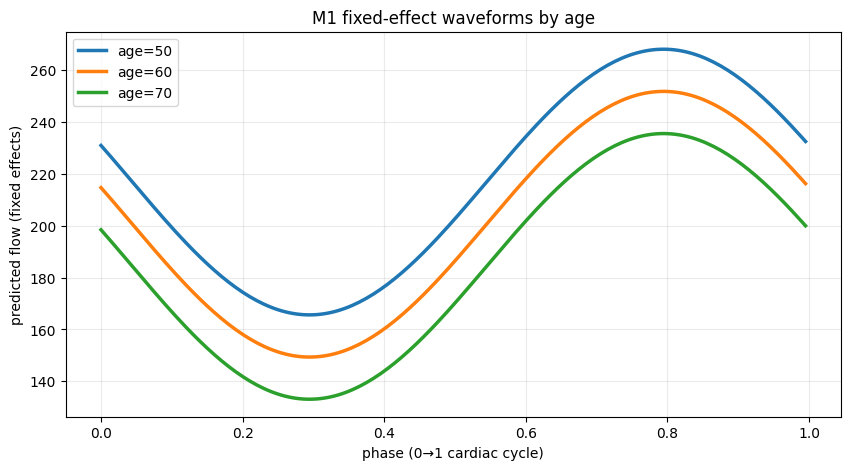

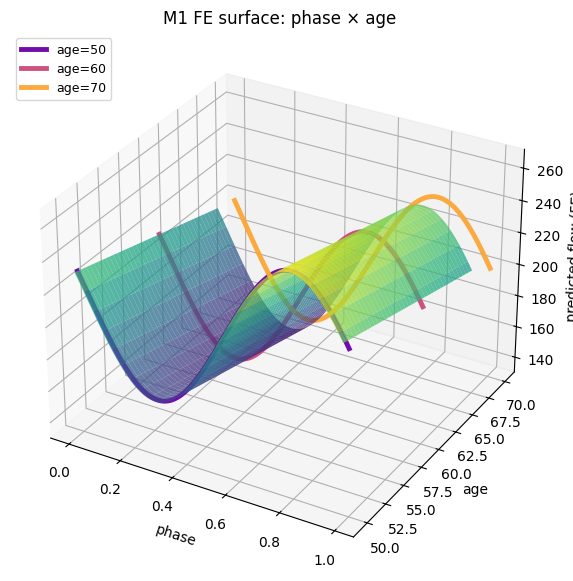

/tmp/ipykernel_309889/3179082038.py:289: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(age_grid, y_f, "k--", linewidth=2.8, alpha=0.8, label="FE mean (female)", color='purple')
/tmp/ipykernel_309889/3179082038.py:290: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-." (-> color='k'). The keyword argument will take precedence.
  ax.plot(age_grid, y_m, "k-.", linewidth=2.8, alpha=0.8, label="FE mean (male)", color='orange')


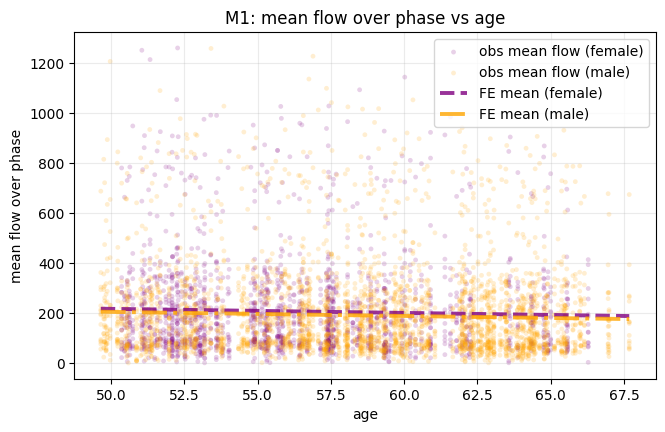

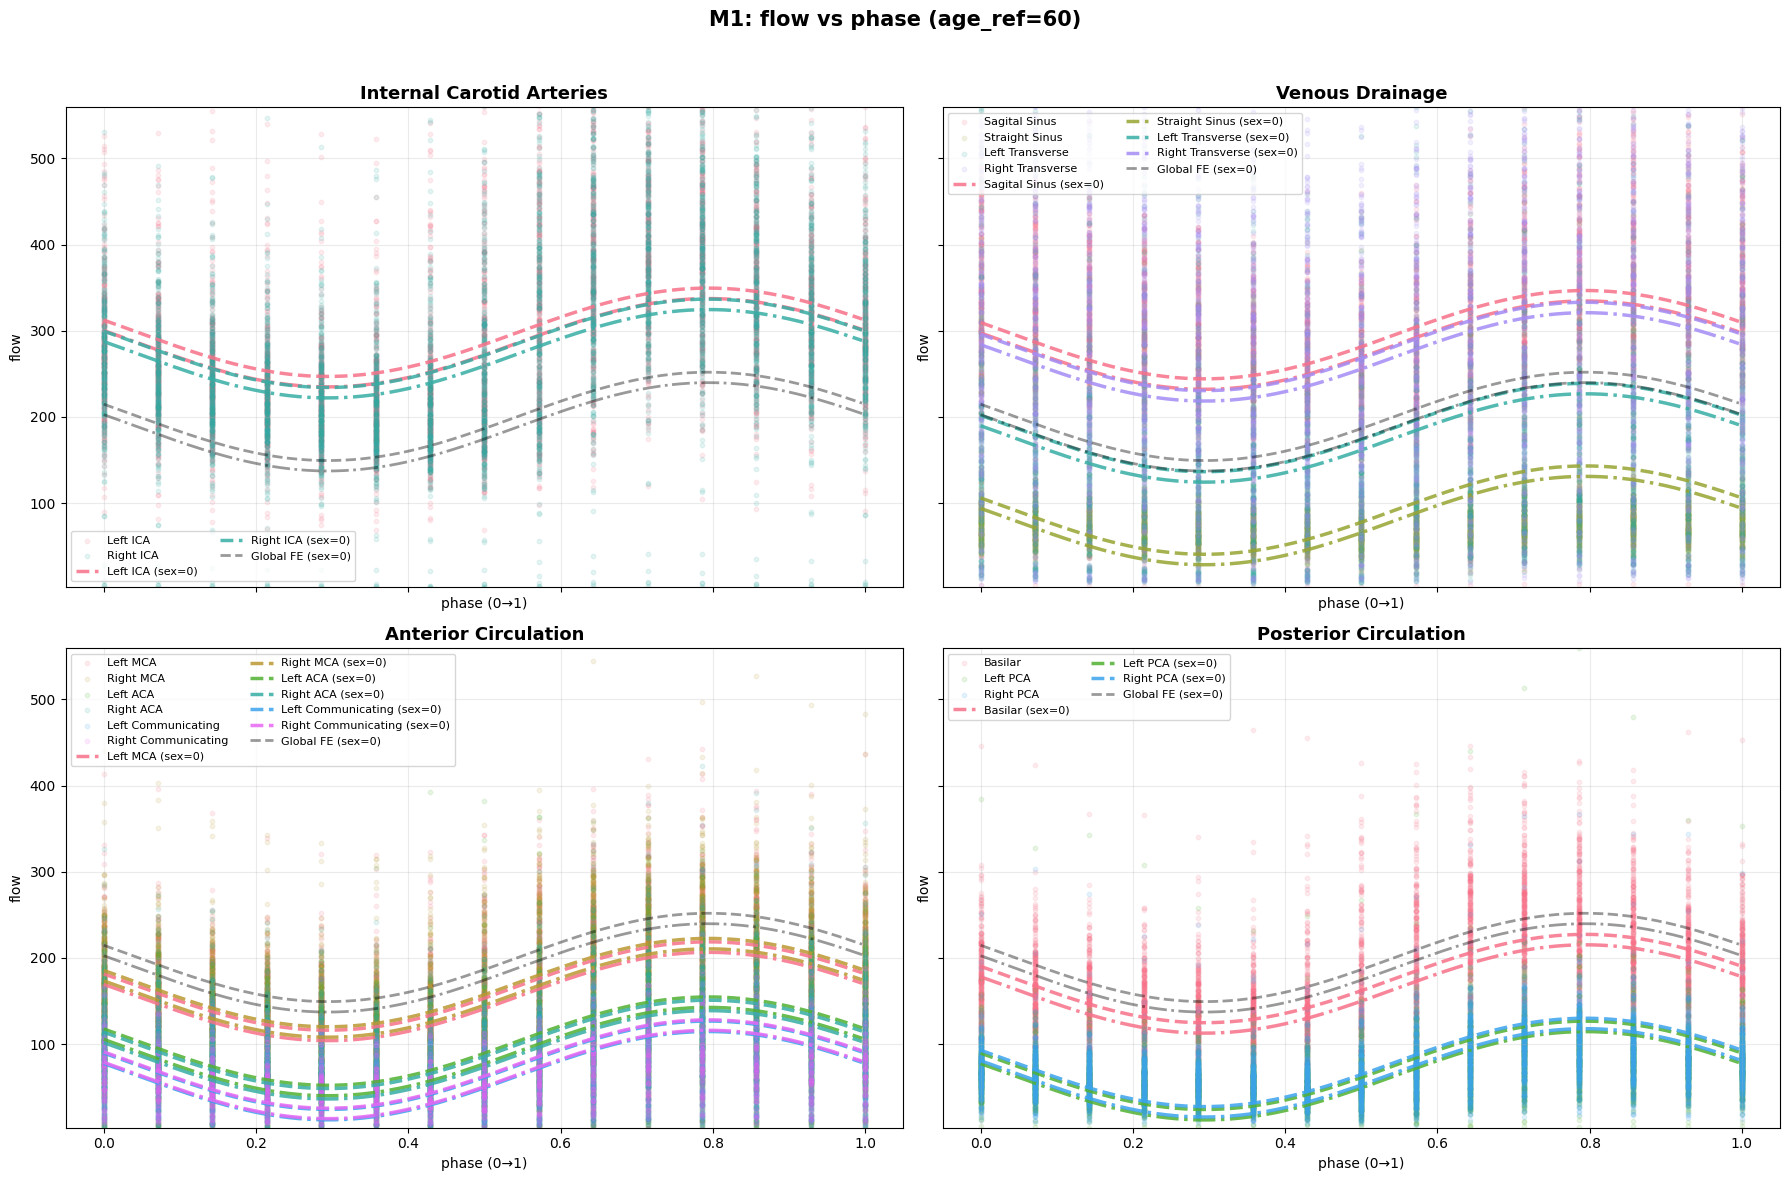

/tmp/ipykernel_309889/3179082038.py:664: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_309889/3179082038.py:668: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(out, dpi=300)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

# -------------------------
# Prep
# -------------------------
def map_sex_to_numeric(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")
    ss = s.astype(str).str.strip().str.lower()
    mapping = {"male": 1, "m": 1, "female": 0, "f": 0, "1": 1, "0": 0}
    return pd.to_numeric(ss.map(mapping), errors="coerce")

def prep_flow_ts(flow_ts_long: pd.DataFrame) -> pd.DataFrame:
    df = flow_ts_long.copy()

    # unify names if needed
    if "value" in df.columns and "flow" not in df.columns:
        df["flow"] = df["value"]

    if "age" not in df.columns and "age_at_mri" in df.columns:
        df["age"] = df["age_at_mri"]

    df["flow"] = pd.to_numeric(df["flow"], errors="coerce")
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["sex"] = map_sex_to_numeric(df["sex"])
    df["phase"] = pd.to_numeric(df["phase"], errors="coerce")
    df["frame"] = pd.to_numeric(df["frame"], errors="coerce").astype(np.int64)

    df = df.dropna(subset=["patient_id", "vessel", "flow", "age", "sex", "phase", "frame"]).copy()

    # center age for stability (matches your paper approach)
    df["age_c"] = df["age"] - float(df["age"].mean())

    # harmonic terms
    df["sin1"] = np.sin(2 * np.pi * df["phase"].astype(float))
    df["cos1"] = np.cos(2 * np.pi * df["phase"].astype(float))

    # participant:vessel id (for (1 | participant:vessel))
    df["pv"] = df["patient_id"].astype(str) + ":" + df["vessel"].astype(str)

    # categorical vessel for stable group handling
    df["vessel"] = pd.Categorical(df["vessel"], categories=sorted(df["vessel"].unique()))

    return df

def fit_mixedlm_ts(df: pd.DataFrame, fixed_formula: str, re_formula: str = "1 + age_c"):
    vc = {
        "participant": "0 + C(patient_id)",  # (1 | participant)
        "pv": "0 + C(pv)",                   # (1 | participant:vessel)
    }
    model = MixedLM.from_formula(
        fixed_formula,
        groups=df["vessel"],                 # vessel is the main grouping
        re_formula=re_formula,               # (1 + age | vessel)
        vc_formula=vc,
        data=df,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
        warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")
        warnings.filterwarnings("ignore", category=ConvergenceWarning, module="statsmodels")
        res = model.fit(reml=True, method="lbfgs", maxiter=1200, disp=False)
    return res

def print_compact(res, title: str, out: Path = None):
    print("\n" + "=" * 100)
    print(title)
    print("-" * 100)
    print(res.summary())
    print("=" * 100)
    if out:
        out = Path(out) / f'summary_{title}.txt'
        with open(out, "w") as f:
            f.write(res.summary().as_text())

from pathlib import Path
from statsmodels.iolib.smpickle import load_pickle

def fit_or_load_mixedlm(path: Path, fit_fn, overwrite=False):
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and not overwrite:
        from statsmodels.regression.mixed_linear_model import MixedLMResults
        return MixedLMResults.load(path)
    res = fit_fn()
    res.save(path)
    return res

# -------------------------
# Plotting (fixed effects only, for clarity)
# -------------------------
def vessel_to_group(vessel: str, vessel_groups_order: dict[str, list[str]]) -> str:
    for g, vs in vessel_groups_order.items():
        if vessel in set(vs):
            return g
    return "Other"

def plot_harmonic_waveform_with_scatter_by_group(
    res,
    df_ts: pd.DataFrame,
    *,
    vessel_groups_order: dict[str, list[str]],
    age_ref: float = 60,
    sex_vals=(0.0, 1.0),  # female=0, male=1
    title="Harmonic model: flow vs phase by vessel group",
    out: Path = None,
):
    """
    Creates a 2x2 subplot with one panel per vessel group.
    Each panel shows:
    - Low-alpha scatter of observed data (colored by vessel)
    - Vessel-specific conditional fit lines (FE + vessel RE) for each vessel in that group
    - Optional: global FE line as reference (dashed, low alpha)
    """
    d = df_ts.copy()
    d["group"] = d["vessel"].astype(str).map(lambda v: vessel_to_group(v, vessel_groups_order))

    # Helper: extract vessel random effects
    def _get_vessel_re(res, vessel: str) -> pd.Series:
        re = res.random_effects.get(vessel, None)
        if re is None and isinstance(vessel, str):
            re = res.random_effects.get(str(vessel), None)
        if re is None:
            return pd.Series(dtype=float)
        return re if isinstance(re, pd.Series) else pd.Series(np.asarray(re).ravel())

    def _re_val(re_s: pd.Series, key: str, default: float = 0.0) -> float:
        if key in re_s.index:
            try:
                return float(re_s[key])
            except Exception:
                return default
        return default

    # Prediction helper
    import patsy
    def fe_pred(tmp: pd.DataFrame) -> np.ndarray:
        X = patsy.build_design_matrices([res.model.data.design_info], tmp, return_type="dataframe")[0]
        fe = res.fe_params
        X = X.reindex(columns=fe.index, fill_value=0.0)
        return (X.to_numpy() @ fe.to_numpy()).astype(float)

    # Common prediction grid and reference values
    phase_grid = np.linspace(0, 1, 250, endpoint=False)
    vessel_ref = str(d["vessel"].cat.categories[0]) if hasattr(d["vessel"], "cat") else str(d["vessel"].iloc[0])
    age_mean = float(d["age"].mean())

    # Create 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, (gname, vessels) in zip(axes, vessel_groups_order.items()):
        vessels_present = [v for v in vessels if v in set(d["vessel"].astype(str).unique())]
        
        if not vessels_present:
            ax.axis("off")
            continue

        # Filter data to this group's vessels
        sub_group = d[d["vessel"].astype(str).isin([str(v) for v in vessels_present])].copy()

        # Low-alpha scatter: color by vessel within this group
        vessel_palette = sns.color_palette("husl", n_colors=len(vessels_present))
        for i, v in enumerate(vessels_present):
            v_str = str(v)
            sub_v = sub_group[sub_group["vessel"].astype(str) == v_str]
            ax.scatter(
                sub_v["phase"], 
                sub_v["flow"], 
                s=10, 
                alpha=0.12, 
                color=vessel_palette[i], 
                label=v_str if i < 8 else None  # limit legend entries
            )

        # Vessel-specific conditional fits (FE + vessel RE) for each vessel in this group
        for i, v in enumerate(vessels_present):
            v_str = str(v)
            re_s = _get_vessel_re(res, v_str)
            re_int = _re_val(re_s, "Group", default=_re_val(re_s, "Intercept", 0.0))
            re_age = _re_val(re_s, "age_c", default=0.0)

            # Predict for this vessel (FE + vessel RE intercept + vessel RE age slope)
            for sex in sex_vals:
                tmp = pd.DataFrame({
                    "age": age_ref,
                    "age_c": age_ref - age_mean,
                    "sex": sex,
                    "phase": phase_grid,
                    "sin1": np.sin(2*np.pi*phase_grid),
                    "cos1": np.cos(2*np.pi*phase_grid),
                    "frame": 0,
                    "patient_id": "PRED",
                    "pv": "PRED:" + v_str,
                    "vessel": v_str,
                })
                yhat_fe = fe_pred(tmp)
                # Add vessel RE: intercept + age slope
                yhat_vessel = yhat_fe + re_int + re_age * (age_ref - age_mean)
                
                ls = "--" if sex == 0 else "-."
                _color = vessel_palette[i]
                ax.plot(
                    phase_grid, 
                    yhat_vessel, 
                    color=_color, 
                    linewidth=2.5, 
                    linestyle=ls, 
                    alpha=0.85,
                    label=f"{v_str} (sex={int(sex)})" if sex == sex_vals[0] else None  # label once per vessel
                )

        # Optional: global FE line as reference (dashed, low alpha, black)
        for sex in sex_vals:
            tmp = pd.DataFrame({
                "age": age_ref,
                "age_c": age_ref - age_mean,
                "sex": sex,
                "phase": phase_grid,
                "sin1": np.sin(2*np.pi*phase_grid),
                "cos1": np.cos(2*np.pi*phase_grid),
                "frame": 0,
                "patient_id": "PRED",
                "pv": "PRED:" + vessel_ref,
                "vessel": vessel_ref,
            })
            yhat_fe = fe_pred(tmp)
            ls = "--" if sex == 0 else "-."
            ax.plot(
                phase_grid, 
                yhat_fe, 
                color="black", 
                linewidth=2.0, 
                linestyle=ls, 
                alpha=0.4,
                label=f"Global FE (sex={int(sex)})" if sex == sex_vals[0] else None
            )

        ax.set_xlabel("phase (0→1)")
        ax.set_ylabel("flow")
        ax.set_title(gname, fontsize=13, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=8, ncol=2)
        # Each eaxis with its own y-range
        ax.set_ylim(np.min(sub_group["flow"]), np.max(sub_group["flow"]))

    fig.suptitle(f"{title} (age_ref={age_ref})", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if out:
        out = Path(out) / f'wf_scatter_{title}.png'
        plt.savefig(out, dpi=300)

    plt.show()

def plot_phase_mean_vs_age(res, df_ts: pd.DataFrame, *, title="Mean (over phase) vs age", out: Path = None):
    fe = res.fe_params
    b0 = float(fe.get("Intercept", fe.get("const", 0.0)))
    b_age = float(fe.get("age_c", 0.0))
    b_sex = float(fe.get("sex", 0.0))

    age_mean = float(df_ts["age"].mean())
    age_grid = np.linspace(float(df_ts["age"].min()), float(df_ts["age"].max()), 200)
    age_c_grid = age_grid - age_mean

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    mean_df = (
        df_ts.groupby(["patient_id", "vessel"])
        .agg({
            "age": "first",
            "sex": "first",
            "flow": "mean"
        })
        .reset_index()
        .rename(columns={"flow": "flow_mean"})
    )
    
    ax.scatter(mean_df["age"][mean_df["sex"] == 0], mean_df["flow_mean"][mean_df["sex"] == 0], s=12, alpha=0.18, color="purple", edgecolors="none", label="obs mean flow (female)")
    ax.scatter(mean_df["age"][mean_df["sex"] == 1], mean_df["flow_mean"][mean_df["sex"] == 1], s=12, alpha=0.18, color="orange", edgecolors="none", label="obs mean flow (male)")

    # female/male lines
    y_f = b0 + b_age*age_c_grid + b_sex*0.0
    y_m = b0 + b_age*age_c_grid + b_sex*1.0
    ax.plot(age_grid, y_f, "k--", linewidth=2.8, alpha=0.8, label="FE mean (female)", color='purple')
    ax.plot(age_grid, y_m, "k-.", linewidth=2.8, alpha=0.8, label="FE mean (male)", color='orange')

    ax.set_xlabel("age")
    ax.set_ylabel("mean flow over phase")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()

    if out:
        out = Path(out) / f'ph_mean_vs_age_{title}.png'
        plt.savefig(out, dpi=300)

    plt.show()

def predict_fixed(res, df_pred: pd.DataFrame) -> np.ndarray:
    # res.predict(df) returns FE + RE if df has group labels; we want FE only.
    # easiest: set vessel to an existing category but ignore random effects by using FE design matrix.
    import patsy
    X = patsy.build_design_matrices([res.model.data.design_info], df_pred, return_type="dataframe")[0]
    fe = res.fe_params
    X = X.reindex(columns=fe.index, fill_value=0.0)
    return (X.to_numpy() @ fe.to_numpy()).astype(float)

def plot_waveforms_by_age(res, df: pd.DataFrame, ages=(50, 60, 70), sex_ref=0.0, vessel_ref=None, title="", out: Path = None):
    # choose a vessel label that exists (needed for categorical coding)
    if vessel_ref is None:
        vessel_ref = str(df["vessel"].cat.categories[0])

    phase_grid = np.linspace(0, 1, 200, endpoint=False)
    fig, ax = plt.subplots(figsize=(10, 5))

    for a in ages:
        tmp = pd.DataFrame({
            "age": a,
            "age_c": a - float(df["age"].mean()),
            "sex": sex_ref,
            "phase": phase_grid,
            "sin1": np.sin(2*np.pi*phase_grid),
            "cos1": np.cos(2*np.pi*phase_grid),
            "frame": 0,            # unused in harmonic models
            "patient_id": "PRED",
            "pv": "PRED:" + vessel_ref,
            "vessel": vessel_ref,
        })
        yhat = predict_fixed(res, tmp)
        ax.plot(phase_grid, yhat, linewidth=2.5, label=f"age={a}")

    ax.set_xlabel("phase (0→1 cardiac cycle)")
    ax.set_ylabel("predicted flow (fixed effects)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend()

    if out:
        out = Path(out) / f'wf_by_age_{title}.png'
        plt.savefig(out, dpi=300)

    plt.show()

def plot_3d_surface(
    res, 
    df: pd.DataFrame, 
    age_min=None, 
    age_max=None, 
    sex_ref=0.0, 
    vessel_ref=None, 
    ages=(50, 60, 70),  # NEW: ages to overlay waveform lines
    title="",
    out: Path = None,
):
    """
    3D surface plot with waveform lines overlaid at selected ages.
    
    Parameters
    ----------
    ages : tuple of float
        Ages at which to draw waveform lines over the surface (same as plot_waveforms_by_age)
    """
    if vessel_ref is None:
        vessel_ref = str(df["vessel"].cat.categories[0])

    if age_min is None: 
        age_min = float(df["age"].min())
    if age_max is None: 
        age_max = float(df["age"].max())

    age_mean = float(df["age"].mean())
    
    # Surface grid
    phase_grid = np.linspace(0, 1, 60, endpoint=False)
    age_grid = np.linspace(age_min, age_max, 40)
    PH, AG = np.meshgrid(phase_grid, age_grid)

    tmp = pd.DataFrame({
        "age": AG.ravel(),
        "age_c": AG.ravel() - age_mean,
        "sex": sex_ref,
        "phase": PH.ravel(),
        "sin1": np.sin(2*np.pi*PH.ravel()),
        "cos1": np.cos(2*np.pi*PH.ravel()),
        "frame": 0,
        "patient_id": "PRED",
        "pv": "PRED:" + vessel_ref,
        "vessel": vessel_ref,
    })
    Z = predict_fixed(res, tmp).reshape(AG.shape)

    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection="3d")
    
    # Plot the surface
    ax.plot_surface(PH, AG, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.75)
    
    # Overlay waveform lines at selected ages
    phase_line = np.linspace(0, 1, 200, endpoint=False)  # finer grid for smooth lines
    
    # Color palette for age lines
    age_colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(ages)))
    
    for i, age_val in enumerate(ages):
        # Predict waveform at this age
        tmp_line = pd.DataFrame({
            "age": age_val,
            "age_c": age_val - age_mean,
            "sex": sex_ref,
            "phase": phase_line,
            "sin1": np.sin(2*np.pi*phase_line),
            "cos1": np.cos(2*np.pi*phase_line),
            "frame": 0,
            "patient_id": "PRED",
            "pv": "PRED:" + vessel_ref,
            "vessel": vessel_ref,
        })
        flow_line = predict_fixed(res, tmp_line)
        
        # Create 3D line: x=phase, y=age (constant), z=flow
        age_const = np.full_like(phase_line, age_val)
        
        ax.plot(
            phase_line, 
            age_const, 
            flow_line,
            color=age_colors[i],
            linewidth=3.5,
            alpha=0.95,
            label=f"age={age_val:.0f}"
        )
    
    ax.set_xlabel("phase")
    ax.set_ylabel("age")
    ax.set_zlabel("predicted flow (FE)")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)

    if out:
        out = Path(out) / f'3d_surface_{title}.png'
        plt.savefig(out, dpi=300)

    plt.show()


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_3d_vessel_group_surfaces(
    res,
    df_ts: pd.DataFrame,
    *,
    vessel_groups_order: dict[str, list[str]],
    model_kind: str = "harmonic",     # "harmonic" (sin/cos) or "frame"
    sex_ref: str = "female",          # "female"=0, "male"=1, "mean"
    n_age: int = 35,
    n_time: int = 50,                # phase points for harmonic, frame points for frame-model
    alpha_surface: float = 0.25,
    alpha_scatter: float = 0.08,
    scatter_stride: int = 3,          # downsample points for speed
    cmap: str = "viridis",
    title: str = "Temporal model: 3D fits by vessel group",
    out: Path = None,
):
    """
    2x2 figure with 3D subplots (one per vessel group).
    Axes:
      X: age
      Y: flow
      Z: time (phase in [0,1) for harmonic; frame index for frame model)
    Shows:
      - low-alpha scatter of observed points (all vessels in that group)
      - a *separate fitted surface per vessel* (fixed + vessel random effects when available)

    Assumptions for df_ts:
      columns: ['vessel','age','age_c','sex','flow','phase','frame'] plus categorical vessel (recommended).
    Notes:
      - For harmonic models, the time axis is 'phase'.
      - For frame models, the time axis is 'frame' (0..14).
      - We use FE+vessel RE predictions if the vessel random effects include the needed terms; otherwise FE only.
    """

    # ---------- helpers ----------
    def _sex_value(d: pd.DataFrame, ref: str) -> float:
        if ref == "female":
            return 0.0
        if ref == "male":
            return 1.0
        if ref == "mean":
            return float(pd.to_numeric(d["sex"], errors="coerce").mean())
        raise ValueError("sex_ref must be one of: female, male, mean")

    def _get_vessel_re(res, vessel: str) -> pd.Series:
        re = res.random_effects.get(vessel, None)
        if re is None and isinstance(vessel, str):
            re = res.random_effects.get(str(vessel), None)
        if re is None:
            return pd.Series(dtype=float)
        return re if isinstance(re, pd.Series) else pd.Series(np.asarray(re).ravel())

    def _re_val(re_s: pd.Series, key: str, default: float = 0.0) -> float:
        if key in re_s.index:
            try:
                return float(re_s[key])
            except Exception:
                return default
        return default

    # Fixed-effect-only prediction using design_info
    def _predict_fe_only(res, df_pred: pd.DataFrame) -> np.ndarray:
        import patsy
        X = patsy.build_design_matrices([res.model.data.design_info], df_pred, return_type="dataframe")[0]
        fe = res.fe_params
        X = X.reindex(columns=fe.index, fill_value=0.0)
        return (X.to_numpy() @ fe.to_numpy()).astype(float)

    # ---------- data ----------
    d = df_ts.copy()
    d["age"] = pd.to_numeric(d["age"], errors="coerce")
    d["age_c"] = pd.to_numeric(d["age_c"], errors="coerce")
    d["flow"] = pd.to_numeric(d["flow"], errors="coerce")
    d["sex"] = pd.to_numeric(d["sex"], errors="coerce")

    if model_kind == "harmonic":
        d["phase"] = pd.to_numeric(d["phase"], errors="coerce")
        d = d.dropna(subset=["age", "age_c", "flow", "sex", "phase", "vessel"]).copy()
        time_name = "phase"
    elif model_kind == "frame":
        d["frame"] = pd.to_numeric(d["frame"], errors="coerce")
        d = d.dropna(subset=["age", "age_c", "flow", "sex", "frame", "vessel"]).copy()
        time_name = "frame"
        # ensure frame is numeric for plotting
        d["frame"] = d["frame"].astype(int)
    else:
        raise ValueError("model_kind must be 'harmonic' or 'frame'")

    sex_val = _sex_value(d, sex_ref)
    age_grid = np.linspace(float(d["age"].min()), float(d["age"].max()), n_age)
    age_mean = float(d["age"].mean())
    age_c_grid = age_grid - age_mean

    if model_kind == "harmonic":
        time_grid = np.linspace(0.0, 1.0, n_time, endpoint=False)
        sin1 = np.sin(2 * np.pi * time_grid)
        cos1 = np.cos(2 * np.pi * time_grid)
    else:
        # frames present in data, or 0..14
        frames = np.sort(d["frame"].unique())
        if len(frames) > 0:
            time_grid = frames
        else:
            time_grid = np.arange(15)
        time_grid = time_grid[:n_time] if len(time_grid) > n_time else time_grid

    # ---------- plot ----------
    fig = plt.figure(figsize=(18, 12))
    axes = [fig.add_subplot(2, 2, i + 1, projection="3d") for i in range(4)]

    for ax, (gname, vessels) in zip(axes, vessel_groups_order.items()):
        vessels_present = [v for v in vessels if v in set(d["vessel"].astype(str).unique())]
        if not vessels_present:
            ax.set_axis_off()
            continue

        sub_all = d[d["vessel"].astype(str).isin([str(v) for v in vessels_present])].copy()

        # low-alpha scatter (downsample for speed)
        if scatter_stride > 1:
            sub_all = sub_all.iloc[::scatter_stride, :]

        Xs = sub_all["age"].to_numpy()
        Ys = sub_all[time_name].to_numpy()
        Zs = sub_all["flow"].to_numpy()
        _color_per_vessel = {
            "Left ICA": "purple",
            "Right ICA": "orange",
            "Basilar": "red",
            "Left PCA": "blue",
            "Right PCA": "green",
            "Sagital Sinus": "yellow",
            "Straight Sinus": "pink",
            "Left Transverse": "purple",
            "Right Transverse": "orange",
            "Left MCA": "green",
            "Right MCA": "blue",
            "Left ACA": "red",
            "Right ACA": "orange",
            "Left Communicating": "purple",
            "Right Communicating": "orange",
        }
            

        # one surface per vessel (FE + vessel RE intercept/age slope if available)
        # (This is the most interpretable way to show each vessel's fit; can be heavy if many points.)
        for v in vessels_present:
            # ax.scatter(Xs, Ys, Zs, s=6, alpha=alpha_scatter)
            ax.scatter(Xs, Ys, Zs, s=6, alpha=alpha_scatter, color=_color_per_vessel[v])
            v = str(v)
            re_s = _get_vessel_re(res, v)
            re_int = _re_val(re_s, "Group", default=_re_val(re_s, "Intercept", 0.0))
            re_age = _re_val(re_s, "age_c", default=0.0)

            # create prediction grid (Age x Time)
            AG, TG = np.meshgrid(age_grid, time_grid)
            dfp = pd.DataFrame({
                "age": AG.ravel(),
                "age_c": (AG.ravel() - age_mean),
                "sex": sex_val,
                "vessel": v,
            })

            if model_kind == "harmonic":
                dfp["phase"] = TG.ravel()
                dfp["sin1"] = np.sin(2 * np.pi * dfp["phase"].astype(float))
                dfp["cos1"] = np.cos(2 * np.pi * dfp["phase"].astype(float))
                dfp["frame"] = 0
            else:
                dfp["frame"] = TG.ravel().astype(int)
                # include these columns only if your design_info expects them (they can be ignored)
                dfp["phase"] = 0.0
                dfp["sin1"] = 0.0
                dfp["cos1"] = 1.0

            # add dummy ids used in vc_formula (safe defaults)
            dfp["patient_id"] = "PRED"
            dfp["pv"] = "PRED:" + v

            # FE prediction
            yhat = _predict_fe_only(res, dfp)

            # add vessel RE (linear in age_c)
            yhat = yhat + re_int + re_age * dfp["age_c"].to_numpy(dtype=float)

            Y = TG
            Z = yhat.reshape(AG.shape)
            X = AG

            ax.plot_surface(
                X, Y, Z,
                rstride=1, cstride=1,
                alpha=alpha_surface,
                # cmap=cmap,
                linewidth=0,
                antialiased=True,
                color=_color_per_vessel[v],
                label=v,
            )
            ax.legend()

        ax.set_title(gname, fontsize=12, fontweight="bold")
        ax.set_xlabel("Age")
        ax.set_ylabel("Flow")
        ax.set_zlabel("Phase" if model_kind == "harmonic" else "Frame")
        ax.grid(False)

    fig.suptitle(f"{title} (sex_ref={sex_ref})", fontsize=14, fontweight="bold", y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if out:
        out = Path(out) / f'3d_vessel_group_surfaces_{title}.png'
        plt.savefig(out, dpi=300)

    plt.show()
    

# -------------------------
# Fit the 3 requested models
# -------------------------
df_ts = prep_flow_ts(flow_ts_long) 
def run_models(df_ts: pd.DataFrame):
    VESSEL_GROUPS_ORDER = {
    "Internal Carotid Arteries": ["Left ICA", "Right ICA"],
    "Venous Drainage": ["Sagital Sinus", "Straight Sinus", "Left Transverse", "Right Transverse"],
    "Anterior Circulation": [
        "Left MCA",
        "Right MCA",
        "Left ACA",
        "Right ACA",
        "Left Communicating",
        "Right Communicating",
    ],
    "Posterior Circulation": ["Basilar", "Left PCA", "Right PCA"],
}

    # Model 1:
    model1_path = Path("/data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/mixedlm_t/model1.pkl")
    plots_path = Path("/data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/mixedlm_t/plots")

    # flow ~ 1 + age + sex + sin + cos + (1 + age | vessel) + (1 | participant) + (1 | participant:vessel)
    m1_def = lambda: fit_mixedlm_ts(df_ts, fixed_formula="flow ~ 1 + age_c + sex + sin1 + cos1", re_formula="1 + age_c")
    m1 = fit_or_load_mixedlm(model1_path, m1_def)

    print_compact(m1, "M1: harmonic waveform + (1+age|vessel) + (1|participant) + (1|participant:vessel)", out=plots_path)
    plot_waveforms_by_age(m1, df_ts, ages=(50, 60, 70), sex_ref=0.0, title="M1 fixed-effect waveforms by age", out=plots_path)
    plot_3d_surface(m1, df_ts, sex_ref=0.0, title="M1 FE surface: phase × age", out=plots_path)
    plot_phase_mean_vs_age(m1, df_ts, title="M1: mean flow over phase vs age", out=plots_path)
    plot_harmonic_waveform_with_scatter_by_group(m1, df_ts, vessel_groups_order=VESSEL_GROUPS_ORDER, title="M1: flow vs phase", out=plots_path)
    plot_3d_vessel_group_surfaces(
        m1, df_ts,
        vessel_groups_order=VESSEL_GROUPS_ORDER,
        model_kind="harmonic",
        sex_ref="female",
        title="M1: 3D fits (Age × Flow × Phase)", out=plots_path
    )

    # # Model 2 (age modifies waveform):
    # model2_path = Path("/data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/mixedlm_t/model2.pkl")

    # # + age:sin + age:cos
    # m2_def = lambda: fit_mixedlm_ts(df_ts, fixed_formula="flow ~ 1 + age_c + sex + sin1 + cos1 + age_c:sin1 + age_c:cos1", re_formula="1 + age_c")
    # m2 = fit_or_load_mixedlm(model2_path, m2_def)

    # print_compact(m2, "M2: harmonic waveform + age×(sin,cos) interactions")
    # plot_waveforms_by_age(m2, df_ts, ages=(50, 60, 70), sex_ref=0.0, title="M2 FE waveforms by age (shape changes)")
    # plot_3d_surface(m2, df_ts, sex_ref=0.0, title="M2 FE surface: phase × age (shape changes)")
    # plot_phase_mean_vs_age(m2, df_ts, title="M2: mean flow over phase vs age")
    # plot_harmonic_waveform_with_scatter_by_group(m2, df_ts, vessel_groups_order=VESSEL_GROUPS_ORDER, title="M2: flow vs phase")
    # plot_3d_vessel_group_surfaces(
    #     m2, df_ts,
    #     vessel_groups_order=VESSEL_GROUPS_ORDER,
    #     model_kind="harmonic",
    #     sex_ref="female",
    #     title="M2: 3D fits (Age × Flow × Phase)"
    # )

#     # Model 3 (frame categorical):
#     model3_path = Path("/data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/mixedlm_t/model3.pkl")

#     # flow ~ 1 + age + sex + C(frame) + age:C(frame) + ...
#     # Note: use age_c for stability and interpretability
#     m3_def = lambda: fit_mixedlm_ts(df_ts, fixed_formula="flow ~ 1 + sex + C(frame) + age_c:C(frame)", re_formula="1 + age_c")
#     m3 = fit_or_load_mixedlm(model3_path, m3_def)
    
#     print_compact(m3, "M3: categorical frame + age×frame")
#     plot_3d_vessel_group_surfaces(
#         m3, df_ts,
#         vessel_groups_order=VESSEL_GROUPS_ORDER,
#         model_kind="frame",
#         sex_ref="female",
#         title="M3: 3D fits (Age × Flow × Frame)"
#     )
    
#     # For M3, waveform plot is discrete; plot FE per frame for chosen ages:
#     ages = [50, 60, 70]
#     frames = np.sort(df_ts["frame"].dropna().unique())
#     vessel_ref = str(df_ts["vessel"].cat.categories[0])
#     fig, ax = plt.subplots(figsize=(10, 5))
#     for a in ages:
#         tmp = pd.DataFrame({
#             "age": a,
#             "age_c": a - float(df_ts["age"].mean()),
#             "sex": 0.0,
#             "frame": frames,
#             "phase": 0.0,
#             "sin1": 0.0,
#             "cos1": 1.0,
#             "patient_id": "PRED",
#             "pv": "PRED:" + vessel_ref,
#             "vessel": vessel_ref,
#         })
#         yhat = predict_fixed(m3, tmp)
#         ax.plot(frames, yhat, marker="o", linewidth=2.0, label=f"age={a}")
#     ax.set_xlabel("frame")
#     ax.set_ylabel("predicted flow (FE)")
#     ax.set_title("M3 FE: predicted flow by frame for selected ages")
#     ax.grid(True, alpha=0.25)
#     ax.legend()
#     plt.show()

#     return m1, m2, m3
    return m1

# m1, m2, m3 = run_models(df_ts)
m1 = run_models(df_ts)

## Step 14: Build/load temporal (15-frame) flow waveform database

Goal:
- Extract **flowPulsatile_val** (15 timepoints over cardiac cycle) per patient×vessel from QVTPlus `.mat`
- Save as a **long-format CSV** so all Step 15 plots are fast/reproducible

Output:
- `..._flow_timeseries_long.csv` with columns: `patient_id, vessel, frame, flow`

Notes:
- This is intentionally implemented in the notebook first; once we converge on the best temporal EDA, we can port into `correlater.py`.


In [24]:
from neuroimaging.pesa_brain.analysis.plotter import (
    load_patient_metadata,
    extract_flow_timeseries_from_mat,
    _VESSEL_CODE_TO_NAME,
)

# Long-format CSV: patient_id × vessel × frame
TEMPORAL_FLOW_LONG_PATH = DATABASE_PATH.with_name(DATABASE_PATH.stem + "_flow_timeseries.csv")
remake_temporal = False

# Only process patients present in the main (time-averaged) DB
MAIN_DB_PATIENT_IDS = set(clinical_df["patient_id"].astype(str).tolist())

if (not TEMPORAL_FLOW_LONG_PATH.exists()) or remake_temporal:
    print("Building temporal flow DB (15-frame waveforms) — this may take a while...")

    patient_dirs = [
        p
        for p in RESULTS_DIR.iterdir()
        if p.is_dir() and p.name.upper().startswith("PESA") and (p.name in MAIN_DB_PATIENT_IDS)
    ]
    patient_dirs = sorted(patient_dirs, key=lambda p: p.name)

    rows = []
    n_ok = 0
    n_fail = 0

    for i, pdir in enumerate(patient_dirs, start=1):
        pid = pdir.name
        try:
            md = load_patient_metadata(pdir)
            locs = md.get("LOCs", {})
            if not locs:
                n_fail += 1
                continue

            flow_ts = extract_flow_timeseries_from_mat(pdir, locs)
            if not flow_ts:
                n_fail += 1
                continue

            for code, arr in flow_ts.items():
                vessel_name = _VESSEL_CODE_TO_NAME.get(code, code)
                arr = np.asarray(arr, dtype=float)

                # Enforce 15 frames (0..14). If an input has 16 samples, keep the first 15.
                if arr.size >= 15:
                    arr = arr[:15]

                for t, v in enumerate(arr.tolist()):
                    rows.append(
                        {
                            "patient_id": pid,
                            "vessel": vessel_name,
                            "vessel_code": code,
                            "frame": int(t),
                            "flow": float(v),
                        }
                    )

            n_ok += 1
        except Exception:
            n_fail += 1

        if i % 25 == 0:
            print(f"  processed {i}/{len(patient_dirs)} patients...")

    flow_ts_long = pd.DataFrame(rows)
    TEMPORAL_FLOW_LONG_PATH.parent.mkdir(parents=True, exist_ok=True)
    flow_ts_long.to_csv(TEMPORAL_FLOW_LONG_PATH, index=False)

    print("✓ Saved temporal flow DB:", TEMPORAL_FLOW_LONG_PATH)
    print("Patients OK:", n_ok, "Failed/skipped:", n_fail)
    print("Rows:", len(flow_ts_long))
else:
    print("✓ Temporal flow DB already exists:", TEMPORAL_FLOW_LONG_PATH)

# Load (always)
flow_ts_long = pd.read_csv(TEMPORAL_FLOW_LONG_PATH)
flow_ts_long["patient_id"] = flow_ts_long["patient_id"].astype(str)
flow_ts_long["frame"] = pd.to_numeric(flow_ts_long["frame"], errors="coerce").astype(int)
flow_ts_long["flow"] = pd.to_numeric(flow_ts_long["flow"], errors="coerce")

# Keep only frames 0..14 
flow_ts_long = flow_ts_long[flow_ts_long["frame"].between(0, 14)].copy()

# Keep only patients from main DB 
flow_ts_long = flow_ts_long[flow_ts_long["patient_id"].isin(MAIN_DB_PATIENT_IDS)].copy()

# Attach clinical vars for Step 15
flow_ts_long = flow_ts_long.merge(clinical_df, on="patient_id", how="left")

print("Loaded flow_ts_long:", flow_ts_long.shape)
print(
    "Patients:",
    flow_ts_long["patient_id"].nunique(),
    "Vessels:",
    flow_ts_long["vessel"].nunique(),
    "Frames:",
    flow_ts_long["frame"].nunique(),
)

# Validate the "always 15 frames" assumption (and enforce if needed)
STRICT_15_FRAMES = True
EXPECTED_NFRAMES = 15

nframes = flow_ts_long.groupby(["patient_id", "vessel"])["frame"].nunique().reset_index(name="nframes")
print("nframes distribution (patient×vessel):")
print(nframes["nframes"].value_counts().sort_index())

if STRICT_15_FRAMES:
    bad = nframes[nframes["nframes"] != EXPECTED_NFRAMES]
    if len(bad) > 0:
        print(f"Warning: found {len(bad)} patient×vessel waveforms with nframes != {EXPECTED_NFRAMES}. They will be dropped.")
        keep_keys = nframes.loc[nframes["nframes"] == EXPECTED_NFRAMES, ["patient_id", "vessel"]].copy()
        flow_ts_long = flow_ts_long.merge(keep_keys, on=["patient_id", "vessel"], how="inner")

# Add normalized phase coordinate [0,1]
# Frame is assumed 0..14
flow_ts_long["phase"] = flow_ts_long["frame"] / float(EXPECTED_NFRAMES - 1)

# Add TCBF if missing: per patient×frame sum of (LICA + RICA + Basilar)
if "TCBF" not in set(flow_ts_long["vessel"].dropna().unique()):
    wide_pf = flow_ts_long.pivot_table(index=["patient_id", "frame"], columns="vessel", values="flow", aggfunc="mean")
    needed = ["Left ICA", "Right ICA", "Basilar"]
    if all(v in wide_pf.columns for v in needed):
        tcbf = wide_pf[needed].sum(axis=1, min_count=len(needed))  # NaN unless all three present
        tcbf = tcbf.reset_index().rename(columns={0: "flow"})
        tcbf["vessel"] = "TCBF"
        tcbf["vessel_code"] = "TCBF"

        # Attach the rest of the patient-level columns (clinical vars)
        tcbf = tcbf.merge(clinical_df, on="patient_id", how="left")

        # Align columns with flow_ts_long (keep any common + core columns)
        base_cols = ["patient_id", "vessel", "vessel_code", "frame", "flow"]
        other_cols = [c for c in flow_ts_long.columns if c not in base_cols]
        tcbf = tcbf[base_cols + [c for c in other_cols if c in tcbf.columns]]

        flow_ts_long = pd.concat([flow_ts_long, tcbf], ignore_index=True)
        print("✓ Added TCBF temporal waveform as LICA+RICA+Basilar (per frame)")
    else:
        print("Warning: cannot build TCBF (missing one of Left ICA / Right ICA / Basilar in temporal data)")

# Sanity + unit alignment: dynamic waveform mean vs time-averaged DB value
flow_ts_mean = (
    flow_ts_long.groupby(["patient_id", "vessel"], as_index=False)["flow"].mean().rename(columns={"flow": "flow_wave_mean_raw"})
)
flow_avg_long = flow_table.melt(id_vars=["patient_id"], var_name="vessel", value_name="flow_avg")
flow_avg_long["patient_id"] = flow_avg_long["patient_id"].astype(str)
flow_avg_long["flow_avg"] = pd.to_numeric(flow_avg_long["flow_avg"], errors="coerce")

chk = flow_ts_mean.merge(flow_avg_long, on=["patient_id", "vessel"], how="inner").dropna(subset=["flow_wave_mean_raw", "flow_avg"])

# Estimate scaling factor to bring waveform units to mL/min
scale = 1.0
if len(chk) >= 50:
    tmp = chk.copy()
    tmp = tmp[(tmp["flow_wave_mean_raw"].abs() > 1e-6) & np.isfinite(tmp["flow_avg"]) & np.isfinite(tmp["flow_wave_mean_raw"])]
    if len(tmp) >= 50:
        ratio = (tmp["flow_avg"] / tmp["flow_wave_mean_raw"]).replace([np.inf, -np.inf], np.nan).dropna()
        if len(ratio) >= 50:
            scale_med = float(np.nanmedian(ratio))
            # Heuristic: if scale ~60, waveform was likely in mL/s
            if 50.0 <= scale_med <= 70.0:
                scale = scale_med
            else:
                scale = 1.0

if scale != 1.0:
    print(f"Detected waveform scaling ~{scale:.3g}. Converting dynamic flow to mL/min (flow *= {scale:.3g}).")
    flow_ts_long["flow"] = flow_ts_long["flow"] * scale
else:
    print("No waveform scaling applied (assuming dynamic flow already in mL/min).")

# Resave
flow_ts_long.to_csv(TEMPORAL_FLOW_LONG_PATH, index=False)
# Recompute sanity after scaling
flow_ts_mean2 = (
    flow_ts_long.groupby(["patient_id", "vessel"], as_index=False)["flow"].mean().rename(columns={"flow": "flow_wave_mean"})
)
chk2 = flow_ts_mean2.merge(flow_avg_long, on=["patient_id", "vessel"], how="inner").dropna(subset=["flow_wave_mean", "flow_avg"])
if len(chk2) >= 10:
    r = float(np.corrcoef(chk2["flow_wave_mean"], chk2["flow_avg"])[0, 1])
    print("Sanity Pearson r (wave mean vs DB avg):", r)
else:
    print("Sanity check skipped (insufficient overlap).")


✓ Temporal flow DB already exists: /home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/PESABrain_AnalysisDB_Batch1_flow_timeseries.csv


Loaded flow_ts_long: (73905, 40)
Patients: 356 Vessels: 16 Frames: 15
nframes distribution (patient×vessel):
nframes
15    4885
Name: count, dtype: int64
No waveform scaling applied (assuming dynamic flow already in mL/min).
Sanity Pearson r (wave mean vs DB avg): 0.9999836331327251


# Load TS csv

In [8]:
from neuroimaging.pesa_brain.analysis.plotter import (
    load_patient_metadata,
    extract_flow_timeseries_from_mat,
    _VESSEL_CODE_TO_NAME,
)
TEMPORAL_FLOW_LONG_PATH = DATABASE_PATH.with_name(DATABASE_PATH.stem + "_flow_timeseries.csv")
flow_ts_long = pd.read_csv(TEMPORAL_FLOW_LONG_PATH)
flow_ts_long

,patient_id,vessel,vessel_code,frame,flow,phase,ctx_right_hemisphere,sys_dias_delta,bpxdim,weight,...,bpxpls,height,ctx_left_hemisphere,sex,plaque_right_carotid,tad,plaque_left_carotid,ctx_whole_brain,age_at_mri,bmi
0,PESA1006009,Left ICA,LICA,0,252.617741,0.000000,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
1,PESA1006009,Left ICA,LICA,1,227.585850,0.071429,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
2,PESA1006009,Left ICA,LICA,2,217.659688,0.142857,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
3,PESA1006009,Left ICA,LICA,3,215.417776,0.214286,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
4,PESA1006009,Left ICA,LICA,4,201.988692,0.285714,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73900,PESA9972964,TCBF,TCBF,10,987.142467,0.714286,62.464305,35.0,74.0,56.5,...,55.0,171.0,61.776127,0.0,0.0,65.0,0.0,62.120475,53.65,19.322185
73901,PESA9972964,TCBF,TCBF,11,1014.175444,0.785714,62.464305,35.0,74.0,56.5,...,55.0,171.0,61.776127,0.0,0.0,65.0,0.0,62.120475,53.65,19.322185
73902,PESA9972964,TCBF,TCBF,12,1002.189646,0.857143,62.464305,35.0,74.0,56.5,...,55.0,171.0,61.776127,0.0,0.0,65.0,0.0,62.120475,53.65,19.322185
73903,PESA9972964,TCBF,TCBF,13,869.828267,0.928571,62.464305,35.0,74.0,56.5,...,55.0,171.0,61.776127,0.0,0.0,65.0,0.0,62.120475,53.65,19.322185


In [ ]:
# # Check for duplicated columns with _x and _y suffixes and fix them
# cols = flow_ts_long.columns
# x_cols = [c for c in cols if c.endswith("_x")]
# y_cols = [c for c in cols if c.endswith("_y")]
# common_vars = set([c[:-2] for c in x_cols]).intersection([c[:-2] for c in y_cols])

# if common_vars:
#     print(f"Found duplicated columns with _x/_y suffixes: {common_vars}")
#     for var in common_vars:
#         # Assign one of the values (arbitrary, they should be equal)
#         flow_ts_long[var] = flow_ts_long[f"{var}_x"]
#         flow_ts_long = flow_ts_long.drop(columns=[f"{var}_x", f"{var}_y"])
#     print("Fixed duplicated columns - set to non-suffixed names.")

# flow_ts_long

Found duplicated columns with _x/_y suffixes: {'ctx_right_hemisphere', 'sys_dias_delta', 'bpxdim', 'weight', 'bpxsym', 'hematocrit', 'tas', 'bpxpls', 'height', 'ctx_left_hemisphere', 'sex', 'plaque_right_carotid', 'tad', 'plaque_left_carotid', 'ctx_whole_brain', 'age_at_mri', 'bmi'}
Fixed duplicated columns - set to non-suffixed names.


,patient_id,vessel,vessel_code,frame,flow,phase,ctx_right_hemisphere,sys_dias_delta,bpxdim,weight,...,bpxpls,height,ctx_left_hemisphere,sex,plaque_right_carotid,tad,plaque_left_carotid,ctx_whole_brain,age_at_mri,bmi
0,PESA1006009,Left ICA,LICA,0,252.617741,0.000000,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
1,PESA1006009,Left ICA,LICA,1,227.585850,0.071429,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
2,PESA1006009,Left ICA,LICA,2,217.659688,0.142857,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
3,PESA1006009,Left ICA,LICA,3,215.417776,0.214286,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
4,PESA1006009,Left ICA,LICA,4,201.988692,0.285714,66.288385,49.0,75.0,78.0,...,62.0,167.0,63.393821,1.0,0.0,73.0,0.0,64.850706,62.87,27.968016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73900,PESA9972964,TCBF,TCBF,10,987.142467,0.714286,62.464305,35.0,74.0,56.5,...,55.0,171.0,61.776127,0.0,0.0,65.0,0.0,62.120475,53.65,19.322185
73901,PESA9972964,TCBF,TCBF,11,1014.175444,0.785714,62.464305,35.0,74.0,56.5,...,55.0,171.0,61.776127,0.0,0.0,65.0,0.0,62.120475,53.65,19.322185
73902,PESA9972964,TCBF,TCBF,12,1002.189646,0.857143,62.464305,35.0,74.0,56.5,...,55.0,171.0,61.776127,0.0,0.0,65.0,0.0,62.120475,53.65,19.322185
73903,PESA9972964,TCBF,TCBF,13,869.828267,0.928571,62.464305,35.0,74.0,56.5,...,55.0,171.0,61.776127,0.0,0.0,65.0,0.0,62.120475,53.65,19.322185


In [ ]:
# flow_ts_long.to_csv(TEMPORAL_FLOW_LONG_PATH, index=False)

## Step 15: Temporal waveform EDA + temporal clinical associations (exploration)

Goal:
- Visualize the 15-frame flow waveforms in a few complementary ways
- Start correlating clinical vars with **dynamic flow** sensibly via:
  - Phase-wise associations (per frame)
  - Waveform feature extraction (mean/peak/trough/amplitude/PI-like)
  - Group comparisons (e.g., sex) across the cardiac cycle

Outputs (saved under `OUTPUT_DIR/temporal_flow/`):
- Example vessel plots (violin/spaghetti + mean curves)
- Phase-wise correlation curves (r vs frame)
- Waveform feature tables (CSV)


In [29]:
from pathlib import Path

from scipy.stats import linregress

# Output dir for temporal analysis
TEMP_DIR = OUTPUT_DIR / "temporal_flow"
TEMP_DIR.mkdir(parents=True, exist_ok=True)

# Helper columns
# flow_ts_long["sex_num"] = _map_sex_to_numeric(flow_ts_long["sex"])
flow_ts_long["sex_num"] = flow_ts_long["sex"]
flow_ts_long["age_at_mri"] = pd.to_numeric(flow_ts_long["age_at_mri"], errors="coerce")

# Vessel groups (same semantics as earlier parts of notebook)
VESSEL_GROUPS = {
    "Internal Carotid Arteries": ["Left ICA", "Right ICA"],
    "Anterior Circulation": ["Left MCA", "Right MCA", "Left ACA", "Right ACA", "Left Communicating", "Right Communicating"],
    "Posterior Circulation": ["Basilar", "Left PCA", "Right PCA"],
    "Venous Drainage": ["Sagital Sinus", "Straight Sinus", "Left Transverse", "Right Transverse"],
}

# Add vessel_group column
_v2g = {}
for g, vs in VESSEL_GROUPS.items():
    for v in vs:
        _v2g[v] = g
flow_ts_long["vessel_group"] = flow_ts_long["vessel"].map(_v2g).fillna("Other")

# Plaque group (if plaque vars present)
try:
    from neuroimaging.pesa_brain.analysis.correlater import _detect_carotid_plaque_variables, _add_carotid_plaque_stratification

    plaque_vars = _detect_carotid_plaque_variables(flow_ts_long)
    if plaque_vars:
        flow_ts_long = _add_carotid_plaque_stratification(flow_ts_long, plaque_vars)
except Exception:
    pass

# Age bins (quartiles by default)
flow_ts_long["age_at_mri"] = pd.to_numeric(flow_ts_long["age_at_mri"], errors="coerce")
try:
    flow_ts_long["age_bin"] = pd.qcut(flow_ts_long["age_at_mri"], q=4, duplicates="drop")
except Exception:
    flow_ts_long["age_bin"] = pd.cut(flow_ts_long["age_at_mri"], bins=4)


def plot_waveform_violin(vessel: str, *, out_png: Path, sample_n_patients: int = 40):
    df = flow_ts_long[flow_ts_long["vessel"] == vessel].dropna(subset=["flow", "frame"]).copy()
    if df.empty:
        print("No data for vessel:", vessel)
        return

    # Sample a few patients for connected lines (spaghetti) so it stays readable
    rng = np.random.default_rng(0)
    pids = df["patient_id"].dropna().unique().tolist()
    sample_pids = set(rng.choice(pids, size=min(sample_n_patients, len(pids)), replace=False).tolist())
    df_sp = df[df["patient_id"].isin(sample_pids)].copy()

    fig, ax = plt.subplots(figsize=(12, 5))

    sns.violinplot(data=df, x="frame", y="flow", inner=None, color="lightgray", ax=ax)
    sns.stripplot(data=df, x="frame", y="flow", color="black", alpha=0.12, size=2, jitter=0.25, ax=ax)

    # Connected patient trajectories
    for pid, sub in df_sp.groupby("patient_id"):
        sub = sub.sort_values("frame")
        ax.plot(sub["frame"], sub["flow"], color="dodgerblue", alpha=0.12, linewidth=1.0)

    # Mean ± SEM
    g = df.groupby("frame")["flow"]
    mean = g.mean()
    sem = g.sem()
    ax.plot(mean.index, mean.values, color="crimson", linewidth=2.5, label="mean")
    ax.fill_between(mean.index, (mean - sem).values, (mean + sem).values, color="crimson", alpha=0.15, label="±SEM")

    ax.set_title(f"Temporal flow waveform — {vessel}")
    ax.set_xlabel("Cardiac phase frame")
    ax.set_ylabel("Flow (mL/min)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close(fig)


def build_waveform_features(df_long: pd.DataFrame) -> pd.DataFrame:
    """Per patient×vessel waveform features."""
    rows = []
    for (pid, vessel), sub in df_long.groupby(["patient_id", "vessel"]):
        y = pd.to_numeric(sub["flow"], errors="coerce").to_numpy(dtype=float)
        t = pd.to_numeric(sub["frame"], errors="coerce").to_numpy(dtype=int)
        msk = np.isfinite(y)
        if msk.sum() < 5:
            continue
        y = y[msk]
        t = t[msk]
        mean = float(np.nanmean(y))
        peak = float(np.nanmax(y))
        trough = float(np.nanmin(y))
        amp = float(peak - trough)
        t_peak = int(t[int(np.nanargmax(y))])
        # PI-like from waveform (avoid div0)
        pi_like = float(amp / mean) if np.isfinite(mean) and mean != 0 else np.nan
        rows.append(
            {
                "patient_id": pid,
                "vessel": vessel,
                "flow_wave_mean": mean,
                "flow_peak": peak,
                "flow_trough": trough,
                "flow_amp": amp,
                "t_peak": t_peak,
                "pi_like": pi_like,
            }
        )
    return pd.DataFrame(rows)


def phasewise_assoc(df_long: pd.DataFrame, *, vessel: str, clinical_var: str) -> pd.DataFrame:
    """For each frame: regress flow ~ clinical_var across patients (simple OLS)."""
    out = []
    dfv = df_long[df_long["vessel"] == vessel].copy()
    dfv[clinical_var] = pd.to_numeric(dfv[clinical_var], errors="coerce")

    for fr, sub in dfv.groupby("frame"):
        sub = sub.dropna(subset=["flow", clinical_var])
        if len(sub) < 10:
            continue
        x = sub[clinical_var].to_numpy(dtype=float)
        y = sub["flow"].to_numpy(dtype=float)
        if np.nanstd(x) == 0 or np.nanstd(y) == 0:
            continue
        lr = linregress(x, y)
        out.append({"frame": int(fr), "slope": float(lr.slope), "r": float(lr.rvalue), "p": float(lr.pvalue), "n": int(len(sub))})

    return pd.DataFrame(out).sort_values("frame")


# --- Run a few example outputs ---
RUN_TEMPORAL_SWEEPS = False  # set True to loop across many vessels/variables (can be slow)

example_vessel = "Left ICA"
out_png = TEMP_DIR / "waveforms" / f"waveform_violin_{_safe_col(example_vessel)}.png"
plot_waveform_violin(example_vessel, out_png=out_png, sample_n_patients=50)
print("✓ Saved:", out_png)

# Waveform features table (per patient×vessel)
wf_features = build_waveform_features(flow_ts_long)
wf_features = wf_features.merge(clinical_df, on="patient_id", how="left")
wf_path = TEMP_DIR / "waveform_features_flow.csv"
wf_features.to_csv(wf_path, index=False)
print("✓ Saved waveform features:", wf_path, "rows:", len(wf_features))

# -----------------------------------------------------------------------------
# A) Non-linear over phase (waveform shape): mean curves by sex (+ difference)
# -----------------------------------------------------------------------------

def plot_mean_waveform_by_sex(vessel: str, *, out_png: Path):
    df = flow_ts_long[flow_ts_long["vessel"] == vessel].copy()
    df["sex_num"] = _map_sex_to_numeric(df["sex"])  # 0=female, 1=male
    df = df.dropna(subset=["flow", "frame", "sex_num"])
    if df.empty:
        print("No data for vessel:", vessel)
        return

    # Mean per frame by sex
    g = df.groupby(["sex_num", "frame"])["flow"]
    mean = g.mean().reset_index(name="mean")
    sem = g.sem().reset_index(name="sem")
    m = mean.merge(sem, on=["sex_num", "frame"], how="left")

    fig, ax = plt.subplots(figsize=(10, 4))
    for sex_num, label, color in [(0.0, "female", "purple"), (1.0, "male", "darkorange")]:
        sub = m[m["sex_num"] == sex_num].sort_values("frame")
        if sub.empty:
            continue
        ax.plot(sub["frame"], sub["mean"], color=color, linewidth=2.5, label=label)
        ax.fill_between(
            sub["frame"],
            (sub["mean"] - sub["sem"]).to_numpy(),
            (sub["mean"] + sub["sem"]).to_numpy(),
            color=color,
            alpha=0.15,
        )

    ax.set_title(f"Mean waveform by sex — {vessel}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Flow (mL/min)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close(fig)


def plot_sex_difference_curve(vessel: str, *, out_png: Path):
    df = flow_ts_long[flow_ts_long["vessel"] == vessel].copy()
    df["sex_num"] = _map_sex_to_numeric(df["sex"])
    df = df.dropna(subset=["flow", "frame", "sex_num"])
    if df.empty:
        print("No data for vessel:", vessel)
        return

    # Mean per frame by sex
    mean = df.groupby(["sex_num", "frame"], as_index=False)["flow"].mean()
    fem = mean[mean["sex_num"] == 0.0].rename(columns={"flow": "female"})
    male = mean[mean["sex_num"] == 1.0].rename(columns={"flow": "male"})
    diff = fem.merge(male[["frame", "male"]], on="frame", how="inner")
    diff["male_minus_female"] = diff["male"] - diff["female"]

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(diff["frame"], diff["male_minus_female"], color="black", linewidth=2.5)
    ax.axhline(0, color="gray", linewidth=1)
    ax.set_title(f"Sex difference curve (male - female) — {vessel}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Δ Flow (mL/min)")
    ax.grid(True, alpha=0.25)
    ax.set_xticks(list(range(15)))
    fig.tight_layout()

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close(fig)


def plot_mean_waveform_by_hue(
    *,
    df: pd.DataFrame,
    title: str,
    hue_col: str,
    out_png: Path,
    y_col: str = "flow",
):
    """Mean ± SEM per frame by a categorical hue column."""
    d = df.dropna(subset=["frame", y_col, hue_col]).copy()
    if d.empty:
        return

    # Ensure frame order 0..14
    d = d[d["frame"].between(0, 14)]

    g = d.groupby([hue_col, "frame"])[y_col]
    mean = g.mean().reset_index(name="mean")
    sem = g.sem().reset_index(name="sem")
    m = mean.merge(sem, on=[hue_col, "frame"], how="left")

    hues = [h for h in m[hue_col].dropna().unique().tolist()]
    palette = sns.color_palette("tab10", n_colors=max(len(hues), 3))

    fig, ax = plt.subplots(figsize=(10, 4))
    for i, h in enumerate(hues):
        sub = m[m[hue_col] == h].sort_values("frame")
        ax.plot(sub["frame"], sub["mean"], linewidth=2.5, color=palette[i % len(palette)], label=str(h))
        ax.fill_between(
            sub["frame"],
            (sub["mean"] - sub["sem"]).to_numpy(),
            (sub["mean"] + sub["sem"]).to_numpy(),
            color=palette[i % len(palette)],
            alpha=0.15,
        )

    ax.set_title(title)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Flow (mL/min)")
    ax.grid(True, alpha=0.25)
    ax.set_xticks(list(range(15)))
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close(fig)


plot_mean_waveform_by_sex(example_vessel, out_png=TEMP_DIR / "waveforms" / f"mean_by_sex_{_safe_col(example_vessel)}.png")
plot_sex_difference_curve(example_vessel, out_png=TEMP_DIR / "waveforms" / f"sex_diff_{_safe_col(example_vessel)}.png")

# --- Sweep: generate temporal plots for ALL vessels ---
ALL_VESSELS = sorted(flow_ts_long["vessel"].dropna().unique().tolist())

RUN_ALL_VIOLINS = True
RUN_ALL_DIFF_CURVES = True
RUN_ALL_PHASEWISE = True
RUN_ALL_PCA = False  # can be heavy (needs complete 15-frame waveforms)

CLIN_VARS_PHASEWISE = ["age_at_mri"]
for cand in ["bmi", "sys_dias_delta"]:
    if cand in flow_ts_long.columns:
        CLIN_VARS_PHASEWISE.append(cand)

# 1) Per-vessel outputs
for vessel in ALL_VESSELS:
    dfv = flow_ts_long[flow_ts_long["vessel"] == vessel].copy()

    # Violin + spaghetti
    if RUN_ALL_VIOLINS:
        plot_waveform_violin(
            vessel,
            out_png=TEMP_DIR / "waveforms" / "violin" / f"waveform_violin_{_safe_col(vessel)}.png",
            sample_n_patients=40,
        )

    # Mean waveform by hues
    plot_mean_waveform_by_hue(
        df=dfv.assign(sex_label=dfv["sex"].map(lambda s: "female" if s == 0 else "male").astype(str)),
        title=f"Mean waveform by sex — {vessel}",
        hue_col="sex_label",
        out_png=TEMP_DIR / "waveforms" / "by_sex" / f"mean_by_sex_{_safe_col(vessel)}.png",
    )

    if "carotid_plaque_group" in dfv.columns:
        plot_mean_waveform_by_hue(
            df=dfv,
            title=f"Mean waveform by carotid plaque group — {vessel}",
            hue_col="carotid_plaque_group",
            out_png=TEMP_DIR / "waveforms" / "by_plaque" / f"mean_by_plaque_{_safe_col(vessel)}.png",
        )

    if "age_bin" in dfv.columns:
        plot_mean_waveform_by_hue(
            df=dfv,
            title=f"Mean waveform by age bin — {vessel}",
            hue_col="age_bin",
            out_png=TEMP_DIR / "waveforms" / "by_age_bin" / f"mean_by_agebin_{_safe_col(vessel)}.png",
        )

    # Difference curves
    if RUN_ALL_DIFF_CURVES:
        plot_sex_difference_curve(
            vessel,
            out_png=TEMP_DIR / "waveforms" / "diff_curves" / f"sex_diff_{_safe_col(vessel)}.png",
        )

        # Plaque: (Any plaques) - (No Plaques)
        if "carotid_plaque_group" in dfv.columns and ("No Plaques" in set(dfv["carotid_plaque_group"].dropna().unique())):
            dfv2 = dfv.copy()
            dfv2["plaque_any"] = np.where(dfv2["carotid_plaque_group"] == "No Plaques", "No Plaques", "Any Plaques")
            m = dfv2.dropna(subset=["frame", "flow", "plaque_any"]).groupby(["plaque_any", "frame"], as_index=False)["flow"].mean()
            a = m[m["plaque_any"] == "Any Plaques"].rename(columns={"flow": "any"})
            b = m[m["plaque_any"] == "No Plaques"].rename(columns={"flow": "none"})
            d = a.merge(b[["frame", "none"]], on="frame", how="inner")
            d["diff_any_minus_none"] = d["any"] - d["none"]
            if not d.empty:
                fig, ax = plt.subplots(figsize=(10, 3.5))
                ax.plot(d["frame"], d["diff_any_minus_none"], color="black", linewidth=2.5)
                ax.axhline(0, color="gray", linewidth=1)
                ax.set_title(f"Plaque difference curve (Any - None) — {vessel}")
                ax.set_xlabel("Frame")
                ax.set_ylabel("Δ Flow (mL/min)")
                ax.grid(True, alpha=0.25)
                ax.set_xticks(list(range(15)))
                fig.tight_layout()
                out = TEMP_DIR / "waveforms" / "diff_curves" / f"plaque_any_minus_none_{_safe_col(vessel)}.png"
                out.parent.mkdir(parents=True, exist_ok=True)
                fig.savefig(out, dpi=200, bbox_inches="tight")
                plt.close(fig)

    # Phasewise associations (per frame): flow ~ clinical_var
    if RUN_ALL_PHASEWISE:
        for clin_var in CLIN_VARS_PHASEWISE:
            assoc = phasewise_assoc(flow_ts_long, vessel=vessel, clinical_var=clin_var)
            if assoc.empty:
                continue
            out_csv = TEMP_DIR / "phasewise" / f"assoc_{_safe_col(clin_var)}_{_safe_col(vessel)}.csv"
            out_png = TEMP_DIR / "phasewise" / f"assoc_{_safe_col(clin_var)}_{_safe_col(vessel)}.png"
            out_csv.parent.mkdir(parents=True, exist_ok=True)
            assoc.to_csv(out_csv, index=False)

            fig, ax1 = plt.subplots(figsize=(10, 4))
            ax1.plot(assoc["frame"], assoc["r"], color="steelblue", linewidth=2.5)
            ax1.axhline(0, color="black", linewidth=1)
            ax1.set_xlabel("Frame")
            ax1.set_ylabel(f"r(flow, {clin_var})")
            ax1.grid(True, alpha=0.25)
            ax1.set_xticks(list(range(15)))

            ax2 = ax1.twinx()
            ax2.plot(assoc["frame"], assoc["p"], color="crimson", linewidth=2.0)
            ax2.set_yscale("log")
            ax2.set_ylabel("p-value (log)")

            fig.suptitle(f"Phase-wise association: {clin_var} vs flow — {vessel}")
            fig.tight_layout()
            fig.savefig(out_png, dpi=200, bbox_inches="tight")
            plt.close(fig)

    # PCA per vessel (optional)
    if RUN_ALL_PCA:
        scores_df, load_df = waveform_pca_features(vessel)
        if scores_df.empty:
            continue
        scores_df = scores_df.merge(clinical_df, on="patient_id", how="left")

        pca_scores_path = TEMP_DIR / "pca" / "all_vessels" / f"pca_scores_{_safe_col(vessel)}.csv"
        pca_load_path = TEMP_DIR / "pca" / "all_vessels" / f"pca_loadings_{_safe_col(vessel)}.csv"
        pca_scores_path.parent.mkdir(parents=True, exist_ok=True)
        scores_df.to_csv(pca_scores_path, index=False)
        load_df.to_csv(pca_load_path, index=False)

        fig, ax = plt.subplots(figsize=(10, 3.5))
        for c in [c for c in load_df.columns if c.endswith("_loading")]:
            ax.plot(load_df["frame"], load_df[c], linewidth=2.0, label=c.replace("_loading", ""))
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(f"Waveform PCA loadings — {vessel}")
        ax.set_xlabel("Frame")
        ax.set_ylabel("Loading")
        ax.grid(True, alpha=0.25)
        ax.set_xticks(list(range(15)))
        ax.legend(loc="best", fontsize=8)
        fig.tight_layout()
        out = TEMP_DIR / "pca" / "all_vessels" / f"pca_loadings_{_safe_col(vessel)}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        plt.close(fig)

# 2) Group-aggregated waveforms (mean across vessels in group per patient×frame)
rows = []
for gname, vessels in VESSEL_GROUPS.items():
    sub = flow_ts_long[flow_ts_long["vessel"].isin(vessels)].copy()
    if sub.empty:
        continue

    agg = sub.groupby(["patient_id", "frame"], as_index=False)["flow"].mean().rename(columns={"flow": "flow_group"})
    agg["vessel_group"] = gname

    hues = flow_ts_long.drop_duplicates("patient_id")[["patient_id", "sex", "age_bin"]].copy()
    if "carotid_plaque_group" in flow_ts_long.columns:
        hues = flow_ts_long.drop_duplicates("patient_id")[["patient_id", "sex", "age_bin", "carotid_plaque_group"]].copy()
    agg = agg.merge(hues, on="patient_id", how="left")
    rows.append(agg)

group_long = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

if not group_long.empty:
    plot_mean_waveform_by_hue(
        df=group_long,
        title="Group-aggregated mean waveform (mean over vessels) — by vessel_group",
        hue_col="vessel_group",
        out_png=TEMP_DIR / "groups" / "group_mean_by_vessel_group.png",
        y_col="flow_group",
    )

    for gname in sorted(group_long["vessel_group"].dropna().unique().tolist()):
        dg = group_long[group_long["vessel_group"] == gname].copy()
        plot_mean_waveform_by_hue(
            df=dg.assign(sex_label=dg["sex"].map(lambda s: "female" if s == 0 else "male").astype(str)),
            title=f"Group {gname}: mean waveform by sex",
            hue_col="sex_label",
            out_png=TEMP_DIR / "groups" / "by_sex" / f"group_{_safe_col(gname)}_by_sex.png",
            y_col="flow_group",
        )
        if "carotid_plaque_group" in dg.columns:
            plot_mean_waveform_by_hue(
                df=dg,
                title=f"Group {gname}: mean waveform by plaque group",
                hue_col="carotid_plaque_group",
                out_png=TEMP_DIR / "groups" / "by_plaque" / f"group_{_safe_col(gname)}_by_plaque.png",
                y_col="flow_group",
            )
        plot_mean_waveform_by_hue(
            df=dg,
            title=f"Group {gname}: mean waveform by age bin",
            hue_col="age_bin",
            out_png=TEMP_DIR / "groups" / "by_age_bin" / f"group_{_safe_col(gname)}_by_agebin.png",
            y_col="flow_group",
        )

print("✓ Step 15 sweeps saved under:", TEMP_DIR)

# -----------------------------------------------------------------------------
# B) Non-linear clinical associations: spline(age) → flow at specific phase(s)
# -----------------------------------------------------------------------------

import statsmodels.formula.api as smf


def fit_spline_age_by_frame(vessel: str, *, frame: int, df_spline: int = 5):
    """OLS: flow ~ bs(age, df=k) + sex, at a given vessel+frame."""
    d = flow_ts_long[(flow_ts_long["vessel"] == vessel) & (flow_ts_long["frame"] == frame)].copy()
    d["age_at_mri"] = pd.to_numeric(d["age_at_mri"], errors="coerce")
    d["sex_num"] = _map_sex_to_numeric(d["sex"])
    d["flow"] = pd.to_numeric(d["flow"], errors="coerce")
    d = d.dropna(subset=["flow", "age_at_mri", "sex_num"])
    if len(d) < 30:
        return None, d

    # Use patsy spline basis via formula
    # (keeps dependencies minimal: patsy is already used elsewhere in the notebook)
    formula = f"flow ~ bs(age_at_mri, df={df_spline}, degree=3) + sex_num"
    res = smf.ols(formula, data=d).fit()
    return res, d


def plot_spline_fit(res, d: pd.DataFrame, *, vessel: str, frame: int, out_png: Path):
    if res is None:
        print("Spline fit skipped (insufficient data)")
        return

    age_min = float(np.nanmin(d["age_at_mri"]))
    age_max = float(np.nanmax(d["age_at_mri"]))
    x = np.linspace(age_min, age_max, 200)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(d["age_at_mri"], d["flow"], s=18, alpha=0.18, color="gray")

    for sex_num, label, color in [(0.0, "female", "purple"), (1.0, "male", "darkorange")]:
        dfp = pd.DataFrame({"age_at_mri": x, "sex_num": sex_num})
        y = res.predict(dfp)
        ax.plot(x, y, color=color, linewidth=2.5, label=label)

    # p-values: overall spline term is multiple columns; report sex and an F-test for spline block
    try:
        p_sex = float(res.pvalues.get("sex_num", np.nan))
    except Exception:
        p_sex = np.nan

    try:
        spline_cols = [c for c in res.params.index if c.startswith("bs(")]
        if spline_cols:
            ft = res.f_test(" + ".join([f"{c} = 0" for c in spline_cols]))
            p_spline = float(ft.pvalue)
        else:
            p_spline = np.nan
    except Exception:
        p_spline = np.nan

    ax.set_title(f"Spline(age) clinical assoc — {vessel} frame={frame} (p_spline={p_spline:.3g}, p_sex={p_sex:.3g})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Flow (mL/min)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()

    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close(fig)


# Example: pick peak frame (global peak of mean waveform)
mean_curve = flow_ts_long[flow_ts_long["vessel"] == example_vessel].groupby("frame")["flow"].mean()
peak_frame = int(mean_curve.idxmax()) if not mean_curve.empty else 7

res, d = fit_spline_age_by_frame(example_vessel, frame=peak_frame, df_spline=5)
plot_spline_fit(
    res,
    d,
    vessel=example_vessel,
    frame=peak_frame,
    out_png=TEMP_DIR / "nonlinear" / f"spline_age_{_safe_col(example_vessel)}_frame{peak_frame}.png",
)

# Keep the original linear phase-wise association output too
assoc = phasewise_assoc(flow_ts_long, vessel=example_vessel, clinical_var="age_at_mri")
assoc_path = TEMP_DIR / "phasewise" / f"assoc_age_{_safe_col(example_vessel)}.csv"
assoc_path.parent.mkdir(parents=True, exist_ok=True)
assoc.to_csv(assoc_path, index=False)
print("✓ Saved phase-wise assoc table:", assoc_path)

if not assoc.empty:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(assoc["frame"], assoc["r"], color="steelblue", linewidth=2.5)
    ax1.axhline(0, color="black", linewidth=1)
    ax1.set_xlabel("Frame")
    ax1.set_ylabel("r(flow, age)")
    ax1.grid(True, alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(assoc["frame"], assoc["p"], color="crimson", linewidth=2.0)
    ax2.set_yscale("log")
    ax2.set_ylabel("p-value (log)")

    fig.suptitle(f"Phase-wise association: age vs flow — {example_vessel}")
    fig.tight_layout()

    out = TEMP_DIR / "phasewise" / f"assoc_age_{_safe_col(example_vessel)}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print("✓ Saved:", out)
else:
    print("Association table empty (likely too few valid points).")

# -----------------------------------------------------------------------------
# C) Waveform PCA (shape scores) per vessel (non-linear over phase summarized)
# -----------------------------------------------------------------------------

def waveform_pca_features(vessel: str, *, center: bool = True):
    """Return (scores_df, pc_loadings_df).

    scores_df: patient_id, pc1, pc2, ...
    pc_loadings_df: frame, pc1_loading, pc2_loading, ...

    Uses SVD (no sklearn dependency).
    """
    df = flow_ts_long[flow_ts_long["vessel"] == vessel].copy()
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    wide = df.pivot_table(index="patient_id", columns="frame", values="flow", aggfunc="mean")

    # Require full waveform
    wide = wide.dropna(axis=0, how="any")
    if wide.shape[0] < 25:
        return pd.DataFrame(), pd.DataFrame()

    X = wide.to_numpy(dtype=float)
    if center:
        X = X - X.mean(axis=0, keepdims=True)

    # SVD: X = U S Vt
    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    # Scores are U*S
    scores = U * S

    n_keep = min(3, scores.shape[1])
    score_cols = [f"pc{i+1}" for i in range(n_keep)]

    scores_df = pd.DataFrame(scores[:, :n_keep], columns=score_cols)
    scores_df.insert(0, "patient_id", wide.index.astype(str).to_numpy())

    # Loadings over frame are rows of Vt
    frames = wide.columns.to_numpy(dtype=int)
    load_df = pd.DataFrame({"frame": frames})
    for i in range(n_keep):
        load_df[f"pc{i+1}_loading"] = Vt[i, :]

    return scores_df, load_df


# Example PCA on Left ICA
scores_df, load_df = waveform_pca_features(example_vessel)

if not scores_df.empty:
    scores_df = scores_df.merge(clinical_df, on="patient_id", how="left")

    pca_scores_path = TEMP_DIR / "pca" / f"pca_scores_{_safe_col(example_vessel)}.csv"
    pca_load_path = TEMP_DIR / "pca" / f"pca_loadings_{_safe_col(example_vessel)}.csv"
    pca_scores_path.parent.mkdir(parents=True, exist_ok=True)
    scores_df.to_csv(pca_scores_path, index=False)
    load_df.to_csv(pca_load_path, index=False)
    print("✓ Saved PCA scores:", pca_scores_path)
    print("✓ Saved PCA loadings:", pca_load_path)

    # Plot PC loadings over phase
    fig, ax = plt.subplots(figsize=(10, 3.5))
    for c in [c for c in load_df.columns if c.endswith("_loading")]:
        ax.plot(load_df["frame"], load_df[c], linewidth=2.0, label=c.replace("_loading", ""))
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Waveform PCA loadings — {example_vessel}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Loading")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    out = TEMP_DIR / "pca" / f"pca_loadings_{_safe_col(example_vessel)}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print("✓ Saved:", out)

    # Plot PC1 vs age (also spline-fit it)
    d = scores_df.copy()
    d["age_at_mri"] = pd.to_numeric(d["age_at_mri"], errors="coerce")
    d["sex_num"] = _map_sex_to_numeric(d["sex"])
    d = d.dropna(subset=["pc1", "age_at_mri", "sex_num"])

    if len(d) >= 30:
        res_pc = smf.ols("pc1 ~ bs(age_at_mri, df=5, degree=3) + sex_num", data=d).fit()
        age_min = float(np.nanmin(d["age_at_mri"]))
        age_max = float(np.nanmax(d["age_at_mri"]))
        x = np.linspace(age_min, age_max, 200)

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.scatter(d["age_at_mri"], d["pc1"], s=18, alpha=0.2, color="gray")
        for sex_num, label, color in [(0.0, "female", "purple"), (1.0, "male", "darkorange")]:
            y = res_pc.predict(pd.DataFrame({"age_at_mri": x, "sex_num": sex_num}))
            ax.plot(x, y, color=color, linewidth=2.5, label=label)
        ax.set_title(f"Nonlinear clinical assoc: age → PC1 (shape score) — {example_vessel}")
        ax.set_xlabel("Age")
        ax.set_ylabel("PC1 score")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")
        fig.tight_layout()
        out = TEMP_DIR / "pca" / f"pca_pc1_vs_age_{_safe_col(example_vessel)}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print("✓ Saved:", out)

else:
    print("PCA skipped (insufficient complete waveforms for this vessel).")


✓ Saved: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/temporal_flow/waveforms/waveform_violin_Left_ICA.png
✓ Saved waveform features: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/temporal_flow/waveform_features_flow.csv rows: 4891
✓ Step 15 sweeps saved under: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/temporal_flow
✓ Saved phase-wise assoc table: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/temporal_flow/phasewise/assoc_age_Left_ICA.csv
✓ Saved: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/temporal_flow/phasewise/assoc_age_Left_ICA.png
✓ Saved PCA scores: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/temporal_flow/pca/pca_scores_Left_ICA.csv
✓ Saved PCA loadings: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/temporal_flow/pca/pca_loadings_Left_ICA.csv
✓ Saved: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/temporal_flow/pca/pca_loadings_Left_ICA.png
✓ Saved: /d

### How to read the waveform PCA (scores & loadings)

We take one vessel at a time and build a matrix:
- Rows = **patients**
- Columns = **frames 0..14**
- Values = **flow (mL/min)** at each frame

Then we (optionally) **center each column** (subtract the across-patient mean at each frame), and apply SVD/PCA.

- **Loadings (PCk_loading vs frame)**: this is a *temporal pattern* (shape) across the cardiac cycle.
  - If a loading curve is mostly **positive** across all frames, that PC often represents a **global amplitude/mean-flow** component.
  - If the loading curve is **positive in systole** and **negative in diastole** (or vice-versa), that PC represents a **shape contrast** (e.g., “more pulsatile vs more flat”).
  - The **sign is arbitrary** (multiplying a loading by −1 and the scores by −1 is the same PCA).

- **Scores (PCk per patient)**: how much each patient expresses that loading pattern.
  - A patient with a **high PC1 score** has a waveform that projects strongly onto the PC1 loading pattern.
  - Correlating **PC scores** with clinical variables is a compact way to relate *waveform shape* (not just mean flow) to clinical state.

In this notebook we plot:
- PC loadings over frame (to interpret what the PC captures)
- PC1 score vs age with a spline fit (as an example of a nonlinear clinical association)

### What are the phase-wise association plots?

For each vessel and each cardiac frame (0..14), we take the **cross-sectional cohort** at that frame and compute a simple linear association across patients:
- Outcome: **flow(frame)**
- Predictor: one clinical variable (e.g., age, BMI, sys_dias_delta)

The saved plot shows, **as a function of frame**:
- **Pearson r**: the strength/direction of association between the clinical variable and the flow at that specific phase.
- **p-value (log scale)**: how statistically significant that association is at that phase.

How to interpret:
- If **r is consistently positive/negative across frames**, the clinical variable shifts the whole waveform up/down.
- If **r changes sign** (e.g., positive in systole and negative in diastole), the clinical variable is associated with a **shape change** (more vs less pulsatile), not just a mean shift.
- The p-value curve helps identify which parts of the cycle drive the association (but remember it is **multiple testing across frames**; treat it as exploratory unless you correct for that).


## Step 16: QA — near-zero / outlier vessel-wise flows (patient ID inspection)

Goal:
- Find vessel-wise flow values that are suspicious (close to 0 or extreme outliers)
- Label patient IDs so you can inspect the raw QVTPlus outputs
- Save a CSV list of flagged patient×vessel points and example plots

Notes:
- This step is **diagnostic only** (does not remove anything from the analysis).
- Step 14/15 below add temporal waveform extraction + temporal EDA first; this QA step stays useful afterwards.

In [30]:
FLOW_LOW_THR = 25.0  # mL/min, suspicious near-zero
FLOW_OUTLIER_SIGMA = 6.0  # diagnostic only
MAX_VESSELS_TO_PLOT = 15

qa_dir = OUTPUT_DIR / "flow" / "qa_flow_low_or_outlier"
plots_dir = qa_dir / "plots"
qa_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

# Core vessels for MISSING-MEASUREMENT QA highlight
# (as requested: focus on ICAs + Basilar)
CORE_MISSING_VESSELS = {
    "Left ICA",
    "Right ICA",
    "Basilar",
}

# Build long table including TCBF
flow_wide = flow_table.copy()
if "patient_id" not in flow_wide.columns:
    raise ValueError("flow_table must include patient_id")

clinical_small = clinical_df[["patient_id", "age_at_mri", "sex"]].copy()
clinical_small["sex_num"] = _map_sex_to_numeric(clinical_small["sex"])  # reuse Step 12 helper

flow_long_all = flow_wide.melt(id_vars=["patient_id"], var_name="vessel", value_name="flow")
flow_long_all = flow_long_all.merge(clinical_small[["patient_id", "age_at_mri", "sex", "sex_num"]], on="patient_id", how="left")
flow_long_all["flow"] = pd.to_numeric(flow_long_all["flow"], errors="coerce")
flow_long_all["age_at_mri"] = pd.to_numeric(flow_long_all["age_at_mri"], errors="coerce")

flow_long_all = flow_long_all.dropna(subset=["patient_id", "vessel", "flow"]).copy()

# Per-vessel z-score
flags = []
for vessel, sub in flow_long_all.groupby("vessel"):
    vals = sub["flow"].to_numpy(dtype=float)
    mu = np.nanmean(vals)
    sd = np.nanstd(vals, ddof=1)
    if not np.isfinite(sd) or sd == 0:
        z = np.full_like(vals, np.nan)
    else:
        z = (vals - mu) / sd

    sub = sub.copy()
    sub["z"] = z
    sub["flag_low"] = sub["flow"] <= FLOW_LOW_THR
    sub["flag_outlier"] = np.abs(sub["z"]) >= FLOW_OUTLIER_SIGMA
    sub["flag_any"] = sub["flag_low"] | sub["flag_outlier"]

    flagged = sub[sub["flag_any"]]
    if not flagged.empty:
        flags.append(flagged)

if flags:
    flagged_df = pd.concat(flags, ignore_index=True)
else:
    flagged_df = pd.DataFrame(columns=list(flow_long_all.columns) + ["z", "flag_low", "flag_outlier", "flag_any"])

flagged_path = qa_dir / "flagged_flow_points.csv"
flagged_df.sort_values(["vessel", "flow"]).to_csv(flagged_path, index=False)
print("✓ Flagged points saved to:", flagged_path)
print("Flagged count:", len(flagged_df))

# Core-vessel MISSING measurement patients (highlight these across plots)
core_cols_present = [v for v in CORE_MISSING_VESSELS if v in flow_wide.columns]
if not core_cols_present:
    print("Warning: None of CORE_MISSING_VESSELS columns found in flow_table:", CORE_MISSING_VESSELS)
    missing_core_patient_ids = set()
    missing_core_detail = pd.DataFrame(columns=["patient_id", "missing_vessels"])
else:
    core_missing_mask = flow_wide[core_cols_present].isna().any(axis=1)
    missing_core_patient_ids = set(flow_wide.loc[core_missing_mask, "patient_id"].astype(str).tolist())

    def _missing_list(row):
        missing = [c for c in core_cols_present if pd.isna(row[c])]
        return ";".join(missing)

    missing_core_detail = flow_wide.loc[core_missing_mask, ["patient_id"] + core_cols_present].copy()
    missing_core_detail["missing_vessels"] = missing_core_detail.apply(_missing_list, axis=1)
    missing_core_detail = missing_core_detail[["patient_id", "missing_vessels"]]

missing_ids_path = qa_dir / "missing_core_vessels_patient_ids.csv"
missing_detail_path = qa_dir / "missing_core_vessels_detail.csv"

pd.DataFrame({"patient_id": sorted(missing_core_patient_ids)}).to_csv(missing_ids_path, index=False)
missing_core_detail.to_csv(missing_detail_path, index=False)

print("✓ Missing-core vessel patient IDs:", missing_ids_path)
print("✓ Missing-core vessel details:", missing_detail_path)
print("Missing-core patient count:", len(missing_core_patient_ids))

# Pick vessels with most flagged points
vessel_counts = flagged_df["vessel"].value_counts().head(MAX_VESSELS_TO_PLOT)
print("Top vessels by flagged count:\n", vessel_counts)

for vessel in vessel_counts.index:
    sub = flow_long_all[flow_long_all["vessel"] == vessel]
    sub_f = flagged_df[flagged_df["vessel"] == vessel]

    # Patients missing measurements in core vessels (ICAs/Basilar) — highlight everywhere
    sub_missing_core = sub[sub["patient_id"].astype(str).isin(missing_core_patient_ids)]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sub["age_at_mri"], sub["flow"], s=18, alpha=0.22, color="gray", label="all")

    if not sub_missing_core.empty:
        ax.scatter(
            sub_missing_core["age_at_mri"],
            sub_missing_core["flow"],
            s=65,
            alpha=0.85,
            facecolors="none",
            edgecolors="seagreen",
            linewidths=1.4,
            label="missing core-vessel measurement (ICA/Basilar)",
        )

    if not sub_f.empty:
        ax.scatter(sub_f["age_at_mri"], sub_f["flow"], s=65, alpha=0.9, color="crimson", label="flagged (this vessel)")

        # Always annotate flagged points for this vessel
        for _, row in sub_f.iterrows():
            ax.annotate(str(row["patient_id"]), (row["age_at_mri"], row["flow"]), fontsize=7, alpha=0.9)

    ax.axhline(FLOW_LOW_THR, color="crimson", linestyle="--", linewidth=1.5, label=f"low_thr={FLOW_LOW_THR}")
    ax.set_title(f"QA Flow - {vessel}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Flow (mL/min)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()

    out = plots_dir / f"qa_flow_{_safe_col(vessel)}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig)

print("✓ QA plots saved to:", plots_dir)

# Display first few flagged rows
flagged_df.head(20)

✓ Flagged points saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/qa_flow_low_or_outlier/flagged_flow_points.csv
Flagged count: 115
✓ Missing-core vessel patient IDs: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/qa_flow_low_or_outlier/missing_core_vessels_patient_ids.csv
✓ Missing-core vessel details: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary B1/clinical/flow/qa_flow_low_or_outlier/missing_core_vessels_detail.csv
Missing-core patient count: 8
Top vessels by flagged count:
 vessel
Left Communicating     17
Left ACA               16
Right Communicating    14
Right ACA              12
Left Transverse        10
Left PCA                9
Right Transverse        9
Right MCA               8
Right PCA               7
Right ICA               5
Left MCA                3
Left ICA                2
Sagital Sinus           2
Straight Sinus          1
Name: count, dtype: int64
✓ QA plots saved to: /data_local/LabVF/PESA-Brain/RESULTS/Preliminary 

,patient_id,vessel,flow,age_at_mri,sex,sex_num,z,flag_low,flag_outlier,flag_any
0,PESA11923209,Left ACA,23.380233,53.78,1.0,1.0,-1.679801,True,False,True
1,PESA1359556,Left ACA,21.389391,59.31,1.0,1.0,-1.723819,True,False,True
2,PESA1819801,Left ACA,1.090595,63.57,0.0,0.0,-2.172632,True,False,True
3,PESA3286969,Left ACA,13.518227,53.59,0.0,0.0,-1.897853,True,False,True
4,PESA5290000,Left ACA,21.085102,59.30,1.0,1.0,-1.730547,True,False,True
5,PESA5760000,Left ACA,4.884688,59.48,0.0,0.0,-2.088743,True,False,True
6,PESA5934096,Left ACA,8.707447,57.30,1.0,1.0,-2.004221,True,False,True
7,PESA6553600,Left ACA,10.603154,50.87,1.0,1.0,-1.962306,True,False,True
8,PESA7001316,Left ACA,8.257074,60.19,1.0,1.0,-2.014179,True,False,True
9,PESA7001316,Left ACA,8.257074,60.19,1.0,1.0,-2.014179,True,False,True


## Adquisition dates intersection with existing 4DFlows - Check remaining

In [106]:
METADATA_PATH = Path('/data_local/LabVF/PESA-Brain/Auxiliary/PESABrain_SubjectCatalog_0.csv')
CODEBOOK_PATH = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/PESABrain_AllCodebooks_PESA-H_20260204.xlsx')

# clinical_df, flow_table, pi_table
# flow_ts_long
metadata = pd.read_csv(METADATA_PATH)
codebook = pd.read_excel(CODEBOOK_PATH, sheet_name='Casos')

/home/imarcoss/miniforge3/envs/gpu-neuroimaging/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [7]:
metadata

,MR ID,Date,Subject,Age,Scanner,Scans
0,BMRI100102,2024-10-15,PESA14100025,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), COR(1), DT..."
1,BMRI101198,2022-09-30,PESA5184729,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), CO 3D T1(1..."
2,BMRI101846,2022-02-15,PESA87616,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), DTI NODDI(..."
3,BMRI103891,2024-11-12,PESA7001316,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), AP 4DQflow..."
4,BMRI104117,2023-02-24,PESA10233601,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), 4DQflowNeu..."
...,...,...,...,...,...,...
973,BMRI996396,2021-06-23,PESA760384,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), DTI NODDI(..."
974,BMRI997033,2024-09-17,PESA1901641,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), COR(1), DT..."
975,BMRI997363,2022-03-18,PESA1420864,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), DTI NODDI(..."
976,BMRI999786,2023-06-23,PESA6482116,NaN,DIONISIO,"3D T1(1), 3D_FLAIR(1), 3D_T2 HR(1), 4DQflowNeu..."


In [107]:
codebook

,Codi Sub.,MRI_valid_imaging,MRI_valid_imaging_T1_3D,MRI_valid_imaging_FLAIR_3D,MRI_valid_imaging_SWIp,MRI_valid_imaging_others,Unexpected_findings,WB_lesions_MS,Cortical_Infarct,Arachnoidal_cyst,...,Cervical_vein_drainage_r,Cervical_vein_drainage_l,Other_comments,Conclusion,Dolicobasilar,Columna1,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PESA161604,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,J: yugular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PESA193600,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,N: none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PESA1267876,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,O: occipital,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PESA2343961,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,J: yugular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,PESA11222500,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,JO: yugular occipital,JO: yugular occipital,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
440,PESA11209104,0: No,1: Si,1: Si,0: No,0: No,0: No,0: No,0: No,0: No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
441,PESA9972964,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,JO: yugular occipital,J: yugular,LEFT ICA ANEURYSM 3 MM,NaN,0.0,No informado,NaN,NaN,NaN,NaN
442,PESA7997584,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,JO: yugular occipital,JO: yugular occipital,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [54]:
metadata['Date'] = pd.to_datetime(metadata['Date'], errors='coerce')

In [57]:
seqnames_4dflow = [
    '4DQflowNeuro(1)', 'AP 4DQflowNeuro(1)', 'FH 4DQflowNeuro(1)', 'RL 4DQflowNeuro(1)',
    '4DQflowNeuro AP(1)', '4DQflowNeuro FH(1)', '4DQflowNeuro RL(1)',
]
# seqnames_tof =['cs3DI_MC(1)']

contains_4dflow = metadata['Scans'].apply(
    lambda seq: any(s in seq for s in seqnames_4dflow)
)

ids_with_4dflow = metadata.loc[contains_4dflow, 'Subject']
dates_4dflow = metadata.loc[contains_4dflow, 'Date']

print(np.sum(contains_4dflow))
print(np.sum(contains_tof))

404
967


In [56]:
metadata['Date'].dtype

dtype('<M8[ns]')

In [58]:
ids_with_4dflow = metadata['Subject'].values[contains_4dflow]
dates_4dflow = metadata['Date'].values[contains_4dflow]

print(f"4DFlows: {len(ids_with_4dflow)}/{len(metadata['Subject'].values)}")
print(f'Dates from {np.min(dates_4dflow)} to {np.max(dates_4dflow)}')

4DFlows: 404/978
Dates from 2022-11-18T00:00:00.000000000 to 2025-03-25T00:00:00.000000000


dtype('O')

In [59]:
# Subjects without 4DFlows from 2022-11-18 til end

v4_subjects = metadata.loc[metadata['Date'] >= pd.Timestamp('2022-11-18'), 'Subject']
remaining_4dflows = v4_subjects[~v4_subjects.isin(ids_with_4dflow)]
dates_remaining = metadata.loc[
    metadata['Subject'].isin(remaining_4dflows), 'Date'
]
print(len(remaining_4dflows))
print(remaining_4dflows)
print(len(dates_remaining))
print(dates_remaining)

198
0      PESA14100025
8      PESA11655396
9       PESA7257636
10     PESA12902464
22     PESA15350724
           ...     
945    PESA15610401
946     PESA8048569
952     PESA1267876
969    PESA12780625
974     PESA1901641
Name: Subject, Length: 198, dtype: object
198
0     2024-10-15
8     2023-11-07
9     2023-10-11
10    2024-01-15
22    2024-04-19
         ...    
945   2024-05-21
946   2024-07-08
952   2024-08-30
969   2024-02-06
974   2024-09-17
Name: Date, Length: 198, dtype: datetime64[ns]


In [64]:
contains_resting = metadata['Scans'].apply(
    lambda seq: any(s in seq for s in ['RESTING STATE MB(1)'])
)

ids_with_resting = metadata.loc[contains_resting, 'Subject']
dates_resting = metadata.loc[contains_resting, 'Date']

print(len(ids_with_resting))


920


In [67]:
remaining_4dflows_with_resting = remaining_4dflows[remaining_4dflows.isin(ids_with_resting)]
dates_remaining_with_resting = metadata.loc[
    metadata['Subject'].isin(remaining_4dflows_with_resting), 'Date'
]

print(len(remaining_4dflows_with_resting))
print(remaining_4dflows_with_resting)
print(len(dates_remaining_with_resting))
print(dates_remaining_with_resting)


172
0      PESA14100025
10     PESA12902464
22     PESA15350724
28     PESA10778089
29     PESA10497600
           ...     
941    PESA17388900
943     PESA4541161
946     PESA8048569
952     PESA1267876
974     PESA1901641
Name: Subject, Length: 172, dtype: object
172
0     2024-10-15
10    2024-01-15
22    2024-04-19
28    2024-04-23
29    2024-01-30
         ...    
941   2024-07-09
943   2022-11-18
946   2024-07-08
952   2024-08-30
974   2024-09-17
Name: Date, Length: 172, dtype: datetime64[ns]


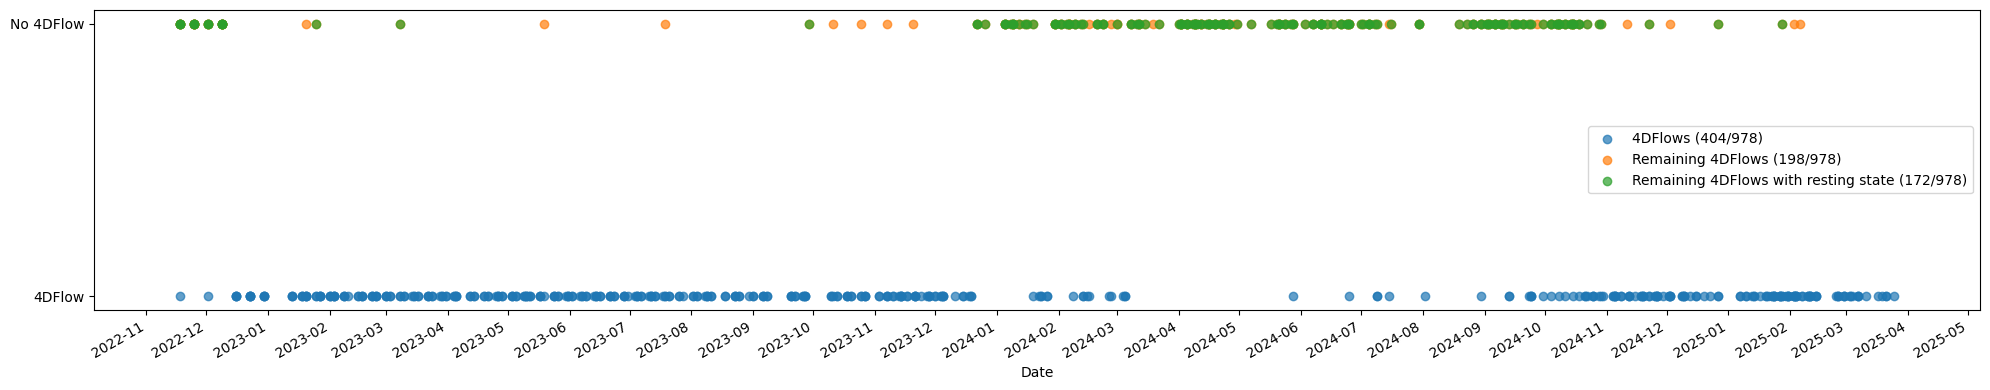

In [68]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(20, 4))

ax.scatter(dates_4dflow, np.zeros(len(dates_4dflow)),
           label=f'4DFlows ({len(dates_4dflow)}/{len(metadata["Subject"].values)})', alpha=0.7)

ax.scatter(dates_remaining, np.ones(len(dates_remaining)),
           label=f'Remaining 4DFlows ({len(dates_remaining)}/{len(metadata["Subject"].values)})', alpha=0.7)

# Highlight the remaining 4DFlows with resting state
ax.scatter(dates_remaining_with_resting, np.ones(len(dates_remaining_with_resting)),
           label=f'Remaining 4DFlows with resting state ({len(dates_remaining_with_resting)}/{len(metadata["Subject"].values)})', alpha=0.7)

ax.set_yticks([0, 1])
ax.set_yticklabels(['4DFlow', 'No 4DFlow'])

ax.set_xlabel('Date')
ax.set_ylabel('')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()
ax.legend()
fig.tight_layout()


In [91]:
print(len(dates_remaining_with_resting))

172


In [92]:
print(len(dates_remaining_with_resting[dates_remaining_with_resting >= pd.Timestamp('2024-01-01')]))

150


In [99]:
remaining_4dflows_with_resting = remaining_4dflows_with_resting[dates_remaining_with_resting >= pd.Timestamp('2024-01-01')]
complete_subset = metadata['Subject'].apply(lambda pid: pid in np.concatenate([ids_with_4dflow, remaining_4dflows_with_resting]))


complete_subset_ids = metadata['Subject'].values[complete_subset]
dates_complete_subset = metadata.loc[complete_subset, 'Date']


print(len(complete_subset_ids))
print(complete_subset_ids)
print(np.min(dates_complete_subset))
print(np.max(dates_complete_subset))


554
['PESA14100025' 'PESA7001316' 'PESA10233601' 'PESA1359556' 'PESA6416089'
 'PESA9972964' 'PESA12902464' 'PESA1411344' 'PESA2356225' 'PESA12945604'
 'PESA853776' 'PESA15350724' 'PESA3489424' 'PESA15689521' 'PESA10778089'
 'PESA10497600' 'PESA672400' 'PESA980100' 'PESA6538249' 'PESA3334276'
 'PESA1562500' 'PESA6345361' 'PESA3640464' 'PESA4247721' 'PESA5697769'
 'PESA617796' 'PESA6265009' 'PESA5712100' 'PESA7767369' 'PESA10374841'
 'PESA17867529' 'PESA1387684' 'PESA12159169' 'PESA13535041' 'PESA9878449'
 'PESA8620096' 'PESA7513081' 'PESA2343961' 'PESA17859076' 'PESA3003289'
 'PESA5340721' 'PESA13293316' 'PESA15421329' 'PESA16112196' 'PESA17048641'
 'PESA6848689' 'PESA11410884' 'PESA1985281' 'PESA1907161' 'PESA8892324'
 'PESA4717584' 'PESA4995225' 'PESA614656' 'PESA14822500' 'PESA2464900'
 'PESA3330625' 'PESA14814801' 'PESA5221225' 'PESA3740356' 'PESA3790809'
 'PESA5424241' 'PESA17581249' 'PESA7823209' 'PESA10413529' 'PESA2196324'
 'PESA2076481' 'PESA8042896' 'PESA16410601' 'PESA6646084

In [109]:
intersection_ids_codebook = codebook['Codi Sub.'].values[codebook['Codi Sub.'].isin(complete_subset_ids)]

print(f'{len(intersection_ids_codebook)}/{len(complete_subset_ids)}')
print(f'No. subjects NOT in codebook: {len(complete_subset_ids) - len(intersection_ids_codebook)}')

406/554
No. subjects NOT in codebook: 148


In [112]:
complete_subset_ids = pd.Series(complete_subset_ids)
remaining_ids_in_codebook = complete_subset_ids[~complete_subset_ids.isin(intersection_ids_codebook)]
print(remaining_ids_in_codebook)
print(len(remaining_ids_in_codebook))

2      PESA10233601
3       PESA1359556
10       PESA853776
12      PESA3489424
17       PESA980100
           ...     
542    PESA14190289
543     PESA2099601
545       PESA56169
550     PESA7661824
552     PESA6482116
Length: 151, dtype: object
151


In [113]:
codebook[codebook['Codi Sub.'].isin(complete_subset_ids)]

,Codi Sub.,MRI_valid_imaging,MRI_valid_imaging_T1_3D,MRI_valid_imaging_FLAIR_3D,MRI_valid_imaging_SWIp,MRI_valid_imaging_others,Unexpected_findings,WB_lesions_MS,Cortical_Infarct,Arachnoidal_cyst,...,Cervical_vein_drainage_r,Cervical_vein_drainage_l,Other_comments,Conclusion,Dolicobasilar,Columna1,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52
1,PESA161604,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,J: yugular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PESA193600,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,N: none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PESA1267876,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,O: occipital,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PESA2343961,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,J: yugular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,PESA322624,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,J: yugular,J: yugular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,PESA11222500,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,JO: yugular occipital,JO: yugular occipital,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
440,PESA11209104,0: No,1: Si,1: Si,0: No,0: No,0: No,0: No,0: No,0: No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
441,PESA9972964,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,JO: yugular occipital,J: yugular,LEFT ICA ANEURYSM 3 MM,NaN,0.0,No informado,NaN,NaN,NaN,NaN
442,PESA7997584,1: Si,1: Si,1: Si,1: Si,1: Si,0: No,0: No,0: No,0: No,...,JO: yugular occipital,JO: yugular occipital,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [114]:
len(complete_subset_ids)

554

In [162]:
final_codebook = codebook[codebook['Codi Sub.'].isin(complete_subset_ids)]
final_codebook['On XNAT'] = np.nan

_rows = []
_colum_names = [name for name in final_codebook.columns.values if name not in ['Codi Sub.', 'On XNAT']]
_intersection = np.intersect1d(final_codebook['Codi Sub.'].values, remaining_4dflows_with_resting)

# Move 'On XNAT' to the second column
final_codebook = final_codebook[['Codi Sub.', 'On XNAT'] + [col for col in _colum_names]]

for idx in complete_subset_ids.values:
    _on_xnat = 'No' if idx in _intersection else 'Yes'
    if idx not in final_codebook['Codi Sub.'].values:
        _rows.append({
            'Codi Sub.': idx,
            'On XNAT': _on_xnat,
            **{col: np.nan for col in _colum_names}
        })
    else: final_codebook.loc[final_codebook['Codi Sub.'] == idx, 'On XNAT'] = _on_xnat

if _rows: final_codebook = pd.concat([final_codebook, pd.DataFrame(_rows)], ignore_index=True)

/tmp/ipykernel_16464/3275973202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_codebook['On XNAT'] = np.nan


In [164]:
print(len(np.intersect1d(final_codebook['Codi Sub.'].values, remaining_4dflows_with_resting)))
print(len(remaining_4dflows_with_resting))
print(len(np.intersect1d(final_codebook['Codi Sub.'].values, ids_with_4dflow)))
print(len(ids_with_4dflow))
print(len(final_codebook))
print(len(np.intersect1d(final_codebook['Codi Sub.'].values, complete_subset_ids)))
print(len(complete_subset_ids))
print(len(codebook))

150
150
404
404
557
554
554
444


In [165]:
np.unique(final_codebook['On XNAT'].values)

array(['No', 'Yes'], dtype=object)

In [ ]:
final_codebook.to_excel('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/PESABrain_AllCodebooks_PESA-H_20260204_4DFlows.xlsx', index=False, engine='openpyxl')


: 